# File reading and transition probabilities derivation

In [48]:
import pandas as pd
import numpy as np

# ============================================================
# 1. Load data
# ============================================================

file_path = r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\Saxony.xlsx"

df = pd.read_excel(file_path)

# ============================================================
# 2. Variables used to define the 4-dimensional space
# ============================================================

variables = [
    "average_temp_c",
    "relative_humidity_%",
    "soil_temp_5cm_c",
    "soil_moisture_0-10cm_%"
]

# ============================================================
# 3. Reference centroid C*
# ============================================================

C_star = np.array([
    11.10,  # max_temp_c
    75.00,  # relative_humidity_%
    9.00,   # soil_temp_5cm_c
    85.00   # soil_moisture_0-10cm_%
])

# ============================================================
# 4. Calculate centroid and distances for each DOY
# ============================================================

results = []

for doy in range(1, 366):

    # --------------------------------------------------------
    # Select the 30 observations corresponding to this DOY
    # --------------------------------------------------------
    doy_data = df.loc[df["DOY"] == doy, variables]

    # Check that exactly 30 observations are available
    if len(doy_data) != 30:
        print(
            f"Warning: DOY {doy} contains "
            f"{len(doy_data)} observations instead of 30."
        )

    # --------------------------------------------------------
    # Convert to NumPy array
    # --------------------------------------------------------
    X = doy_data.to_numpy(dtype=float)

    # --------------------------------------------------------
    # Calculate the 4-dimensional centroid
    # --------------------------------------------------------
    centroid = np.mean(X, axis=0)

    # --------------------------------------------------------
    # Euclidean distance
    # --------------------------------------------------------
    euclidean_distance = np.linalg.norm(
        centroid - C_star
    )

    # --------------------------------------------------------
    # Manhattan distance
    # --------------------------------------------------------
    manhattan_distance = np.sum(
        np.abs(centroid - C_star)
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    results.append({
        "DOY": doy,

        "centroid__temp_c": centroid[0],
        "centroid_relative_humidity_%": centroid[1],
        "centroid_soil_temp_5cm_c": centroid[2],
        "centroid_soil_moisture_0-10cm_%": centroid[3],

        "euclidean_distance": euclidean_distance,
        "manhattan_distance": manhattan_distance
    })

# ============================================================
# 5. Convert results to DataFrame
# ============================================================

distance_df = pd.DataFrame(results)

# ============================================================
# 6. Extract the distance vectors
# ============================================================

euclidean_vector = distance_df["euclidean_distance"].to_numpy()

manhattan_vector = distance_df["manhattan_distance"].to_numpy()

# ============================================================
# 7. Display results
# ============================================================

#print(distance_df)

#print("\nEuclidean distance vector:")
#print(euclidean_vector)

#print("\nManhattan distance vector:")
#print(manhattan_vector)


# ============================================================
# 8. Normalize
# ============================================================

euclidean_vector_normalized = (
    euclidean_vector / np.max(euclidean_vector)
)

manhattan_vector_normalized = (
    manhattan_vector / np.max(manhattan_vector)
)

# ============================================================
# 9. Transition probabilities
# ============================================================

euclidean_vector_complement = 1 - euclidean_vector_normalized

manhattan_vector_complement = 1 - manhattan_vector_normalized


# Random walking

In [49]:
import numpy as np


def random_walking(
    probabilities,
    starting_position,
    emergence_threshold,
    max_path_length=365,
    rng=None
):
    """
    Simulate a circular random walk with an emergence threshold.

    The walker moves sequentially through a circular set of positions.
    The trajectory continues after returning to the starting position and
    terminates only when a transition fails or when the maximum allowed
    path length is reached.

    Parameters
    ----------
    probabilities : array-like
        Vector of transition success probabilities (values between 0 and 1).

    starting_position : int
        Initial position of the walker (1, ..., n).

    emergence_threshold : int
        Path length at which emergence is recorded.

    max_path_length : int, optional
        Maximum number of successful transitions allowed before the
        trajectory is terminated artificially. Default is 365.

    rng : numpy.random.Generator, optional
        Random number generator used to generate independent Uniform(0,1)
        random variables. If omitted, a NumPy default random generator
        is created automatically.

    Returns
    -------
    emerged : bool
        True if the emergence threshold was reached.

    path_length : int
        Total number of successful transitions.

    outcome : str
        Termination condition:
        'failure',
        'emerged_failure',
        'max_length',
        or 'emerged_max_length'.

    emergence_position : int or None
        Position where emergence occurred.

    emergence_time : int or None
        Path length when emergence occurred.

    path : list
        Sequence of visited positions.
    """

    probabilities = np.asarray(probabilities)

    n = len(probabilities)

    # -------------------------
    # Input validation
    # -------------------------

    if n == 0:
        raise ValueError("'probabilities' cannot be empty.")

    if np.any((probabilities < 0) | (probabilities > 1)):
        raise ValueError(
            "'probabilities' must contain values between 0 and 1."
        )

    if not (1 <= starting_position <= n):
        raise ValueError(
            f"'starting_position' must be between 1 and {n}."
        )

    if not (1 <= emergence_threshold <= max_path_length):
        raise ValueError(
            "'emergence_threshold' must be between 1 and "
            "'max_path_length'."
        )

    if max_path_length < 1:
        raise ValueError(
            "'max_path_length' must be greater than or equal to 1."
        )

    if rng is None:
        rng = np.random.default_rng()

    # -------------------------
    # Initial state
    # -------------------------
    
    # Convert to Python's 0-based indexing 
    start = starting_position - 1
    position = start

    path_length = 0
    path = [starting_position]

    emerged = False
    emergence_position = None
    emergence_time = None

    # -------------------------
    # Random walk
    # -------------------------

    while path_length < max_path_length:

        u = rng.random()

        # -------------------------
        # Successful transition
        # -------------------------

        if u <= probabilities[position]:

            path_length += 1

            # Move to next position in the circular domain
            position = (position + 1) % n

            path.append(position + 1)

            # Record emergence only once
            if not emerged and path_length >= emergence_threshold:

                emerged = True
                emergence_position = position + 1
                emergence_time = path_length

        # -------------------------
        # Failed transition
        # -------------------------

        else:

            if emerged:
                return (
                    emerged,
                    path_length,
                    "emerged_failure",
                    emergence_position,
                    emergence_time,
                    path
                )

            else:
                return (
                    emerged,
                    path_length,
                    "failure",
                    None,
                    None,
                    path
                )

    # -------------------------
    # Artificial termination
    # -------------------------

    if emerged:

        return (
            emerged,
            path_length,
            "emerged_max_length",
            emergence_position,
            emergence_time,
            path
        )

    else:

        return (
            emerged,
            path_length,
            "max_length",
            None,
            None,
            path
        )

# Graph

In [50]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import colorsys

from matplotlib.colors import Normalize, LinearSegmentedColormap


def plot_transition_graph(probabilities):

    n = len(probabilities)

    G = nx.DiGraph()

    # =========================================================
    # Nodos
    # =========================================================

    states = [f"D{i+1}" for i in range(n)]

    G.add_nodes_from(states)
    G.add_node("F")

    # =========================================================
    # Aristas
    # =========================================================

    for i, p in enumerate(probabilities):

        current = f"D{i+1}"
        next_state = f"D{(i+1) % n + 1}"

        G.add_edge(
            current,
            next_state,
            weight=p,
            transition="success"
        )

        G.add_edge(
            current,
            "F",
            weight=1 - p,
            transition="failure"
        )

    # =========================================================
    # Layout circular
    # =========================================================

    pos = {
        "F": np.array([0, 0])
    }

    radius = 5

    for i, state in enumerate(states):

        day = i + 1

        angle = np.deg2rad(
            180 + (day - 1) * 360 / 365
        )

        pos[state] = np.array([
            radius * np.cos(angle),
            radius * np.sin(angle)
        ])

    # =========================================================
    # PALETA COLORBLIND
    # MISMA ESCALA QUE LA BARRA DE SUITABILITY
    # =========================================================

    colorblind = sns.color_palette("colorblind")

    # Colores seleccionados de la paleta colorblind
    blue = colorblind[0]
    orange = colorblind[1]
    green = colorblind[2]

    # =========================================================
    # Colormap continuo
    #
    # 0.00 → azul
    # 0.40 → naranja
    # 0.70 → naranja
    # 1.00 → verde
    # =========================================================

    cmap = LinearSegmentedColormap.from_list(
        "colorblind_continuous",
        [
            (0.00, blue),
            (0.10, blue),
            (0.45, orange),
            (0.50, orange),
            (0.55, orange),
            (0.90, green),
            (1.00, green)
        ],
        N=256
    )

    norm = Normalize(
        vmin=0,
        vmax=1
    )

    # =========================================================
    # Color de los nodos según p
    # =========================================================

    node_colors = [
        cmap(norm(p))
        for p in probabilities
    ]

    # =========================================================
    # Figura
    # =========================================================

    fig, ax = plt.subplots(
        figsize=(9, 9)
    )

    # =========================================================
    # Nodos D_i
    # =========================================================

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=states,
        node_size=30,
        node_color=node_colors,
        linewidths=0
    )

    # =========================================================
    # Nodo de fallo F
    # =========================================================

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=["F"],
        node_size=500,
        node_color="white",
        edgecolors="black",
        linewidths=1.5
    )

    # =========================================================
    # Separar aristas
    # =========================================================

    success_edges = [
        (u, v)
        for u, v, d in G.edges(data=True)
        if d["transition"] == "success"
    ]

    failure_edges = [
        (u, v)
        for u, v, d in G.edges(data=True)
        if d["transition"] == "failure"
    ]

    # =========================================================
    # Colores de las aristas de fallo
    #
    # weight = 1 - p
    # =========================================================

    failure_colors = [
        cmap(
            norm(G[u][v]["weight"])
        )
        for u, v in failure_edges
    ]

    # =========================================================
    # Transiciones cíclicas
    # =========================================================

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=success_edges,
        width=0.8,
        edge_color="gray",
        arrows=False,
        alpha=0.5
    )

    # =========================================================
    # Transiciones hacia F
    # =========================================================

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=failure_edges,
        width=1,
        edge_color=failure_colors,
        arrows=False,
        alpha=0.9
    )

    # =========================================================
    # Etiqueta F
    # =========================================================

    nx.draw_networkx_labels(
        G,
        pos,
        labels={
            "F": r"$F$"
        },
        font_size=16
    )

    # =========================================================
    # Función día → ángulo
    # =========================================================

    def day_to_angle(day):

        return 180 + (day - 1) * 360 / 365

    # =========================================================
    # Etiquetas de los días
    # =========================================================

    tick_days = [
        1, 50, 100, 150,
        200, 250, 300, 350
    ]

    label_radius = radius + 0.45
    tick_inner = radius + 0.05
    tick_outer = radius + 0.20

    for day in tick_days:

        angle = np.deg2rad(
            day_to_angle(day)
        )

        ax.plot(
            [
                np.cos(angle) * tick_inner,
                np.cos(angle) * tick_outer
            ],
            [
                np.sin(angle) * tick_inner,
                np.sin(angle) * tick_outer
            ],
            color="black",
            linewidth=1.2
        )

        ax.text(
            np.cos(angle) * (label_radius + 0.12),
            np.sin(angle) * (label_radius + 0.12),
            f"$D_{{{day}}}$",
            ha="center",
            va="center",
            fontsize=16
        )

    # =========================================================
    # Apariencia
    # =========================================================

    ax.set_aspect("equal")
    ax.axis("off")

    plt.tight_layout()

    return plt.gcf()

C:\Users\amigo\AppData\Local\Temp\ipykernel_12416\1560541380.py:202: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(
C:\Users\amigo\AppData\Local\Temp\ipykernel_12416\1832679432.py:9: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


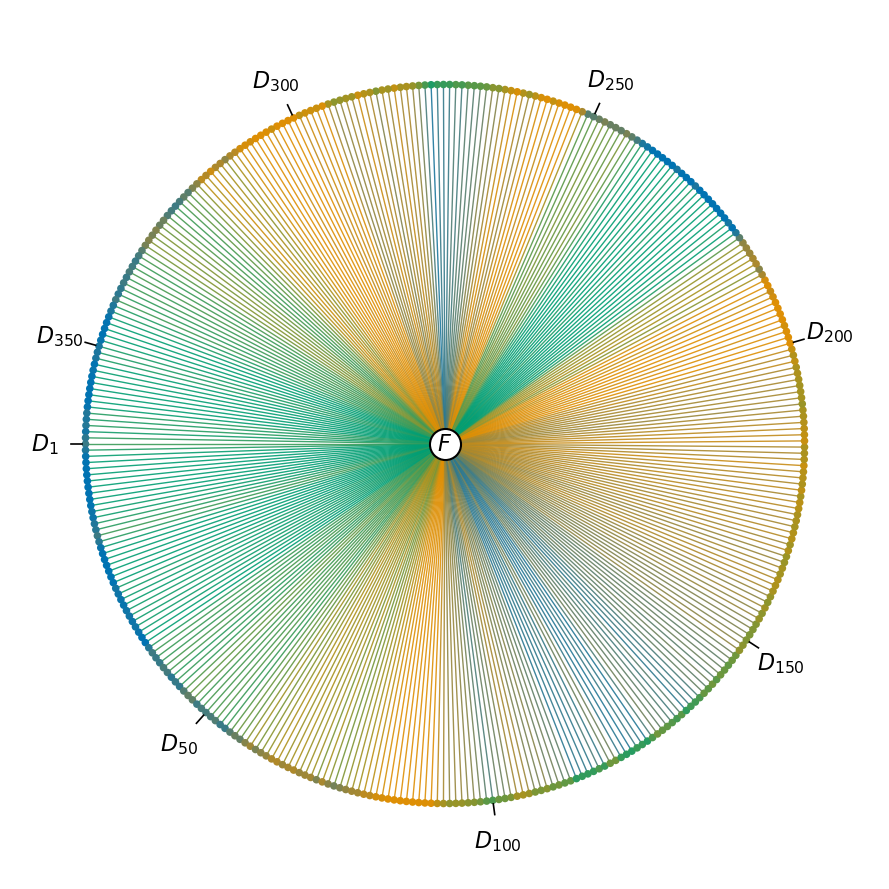

In [51]:
fig = plot_transition_graph(euclidean_vector_complement)

fig.savefig(
    "[Saxony][Euclidean]Transition_graph.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)
fig.show()

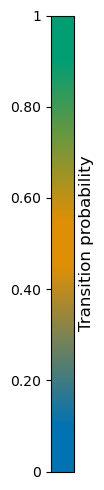

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, Normalize

import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, Normalize

# ============================================================
# Paleta colorblind
# ============================================================

colorblind = sns.color_palette("colorblind")

# Colores seleccionados de la paleta colorblind
blue = colorblind[0]
orange = colorblind[1]
green = colorblind[2]

# ============================================================
# Colormap continuo, pero más oscuro
# ============================================================

cmap = LinearSegmentedColormap.from_list(
    "colorblind_continuous",
    [
        (0.00, blue),
        (0.10, blue),
        (0.45, orange),
        (0.50, orange),
        (0.55, orange),
        (0.90, green),
        (1.00, green)
    ],
    N=256
)

norm = Normalize(
    vmin=0,
    vmax=1
)

# ============================================================
# Figura exclusiva para la barra
# ============================================================

fig, ax = plt.subplots(
    figsize=(1.5, 5)
)

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="vertical",
    fraction=0.5,
    pad=0.05
)

# ============================================================
# Etiqueta
# ============================================================

cbar.set_label(
    "Transition probability",
    fontsize=12
)

# ============================================================
# Ticks
# ============================================================

cbar.set_ticks([
    0,
    0.20,
    0.40,
    0.60,
    0.80,
    1.00
])

cbar.ax.set_yticklabels([
    "0",
    "0.20",
    "0.40",
    "0.60",
    "0.80",
    "1"
])

cbar.ax.yaxis.set_ticks_position("left")

# ============================================================
# Ocultar los ejes auxiliares
# ============================================================

ax.remove()

plt.tight_layout()

# ============================================================
# Guardar
# ============================================================

plt.savefig(
    "Transition_probability.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0,
    transparent=True
)

plt.show()

# Euclidean

In [53]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

consecutive_euclidean = []

for day in range(1, 366):

    # ==========================================
    # Random generator
    # ==========================================
    rng = np.random.default_rng()

    probabilities = euclidean_vector_complement
    starting_position = day
    emergence_threshold = 13

    results = []

    # ==========================================
    # 5000 realizaciones de la caminata
    # ==========================================
    for _ in range(5000):

        emerged, path_length, outcome, emerged_position, emerged_time, path = random_walking(
            probabilities=probabilities,
            starting_position=starting_position,
            emergence_threshold=emergence_threshold,
            rng=rng
        )

        results.append(
            {
                "path_length": path_length,
                "outcome": outcome,
                "emerged": emerged,
                "emerged_position": emerged_position,
                "emerged_time": emerged_time,
                "path": path
            }
        )

    # ==========================================
    # Probabilidad de emergencia
    # ==========================================
    
    #print(Counter(r["emerged"] for r in results))
    
    emergence_probability = (
        sum(r["emerged"] for r in results)
        / len(results)
    )
    
    final = np.array([r["emerged"] for r in results], dtype=bool)

    n = len(final)
    n_bootstrap = 5000

    bootstrap_prob = np.array([
        np.mean(
            rng.choice(
                final,
                size=n,
                replace=True
            )
        )
        for _ in range(n_bootstrap)
    ])

    # ==========================================
    # IC 95% bootstrap percentile
    # ==========================================
    ci_prob_bootstrap = np.quantile(
        bootstrap_prob,
        [0.025, 0.975]
    )

    # ==========================================
    # Probabilidad estimada
    # ==========================================
    p_bootstrap = np.mean(final)

    #print(f"n = {n}")
    #print(f"Emergencias = {np.sum(final)}")
    #print(f"p_hat = {p_hat:.6f}")
    #print(f"IC 95% = ({ci_prob_bootstrap[0]:.6f}, "
    #      f"{ci_prob_bootstrap[1]:.6f})")

    #print(f"Probabilidad de emergencia: {p_hat:.6f}")
    #print(f"IC 95% bootstrap: {ci_prob_bootstrap}")
    

    # ==========================================
    # Longitudes de emergencia
    # ==========================================
    emergence_lengths = np.array([
        r["path_length"]
        for r in results
    ])
    
    #plt.figure(figsize=(8, 5))

    #plt.hist(
    #    emergence_lengths,
    #    bins=np.arange(
    #        emergence_lengths.min(),
    #        emergence_lengths.max() + 2
    #    ) - 0.5,
    #    edgecolor="black"
    #)

    #plt.xlabel("Emergence length")
    #plt.ylabel("Frequency")
    #plt.title("Distribution of emergence lengths")

    #plt.tight_layout()
    #plt.show()

    # Intervalo por cuantiles de las realizaciones
    ci_lengths = np.quantile(
        emergence_lengths,
        [0.025, 0.975],
        method="nearest"
    )

    # ==========================================
    # JACKKNIFE
    # ==========================================

    n = len(final)

    # Estimaciones jackknife:
    # eliminar una observación en cada iteración
    jackknife_prob = np.array([
        np.mean(
            np.delete(final, i)
        )
        for i in range(n)
    ])

    # Media de las estimaciones jackknife
    jackknife_mean = np.mean(jackknife_prob)

    # Varianza muestral de las estimaciones jackknife
    jackknife_var = np.var(
        jackknife_prob,
        ddof=1
    )

    # Error estándar jackknife
    jackknife_se = np.sqrt(
        jackknife_var / n
    )

    # t crítico
    t_score = stats.t.ppf(
        q=0.975,
        df=n - 1
    )

    # IC 95% jackknife
    ci_lengths_jack = (
        jackknife_mean - t_score * jackknife_se,
        jackknife_mean + t_score * jackknife_se
    )

    
    # ==========================================
    # Guardar resultados
    # ==========================================
    consecutive_euclidean.append(
        {
            "day": day,
            "emergence_probability": emergence_probability,
            "ci_prob_bootstrap": ci_prob_bootstrap,
            "p_bootstrap":  p_bootstrap,
            "ci_lengths_jack": ci_lengths_jack,
            "p_jackknife_mean": jackknife_mean,
            "ci_lengths" : ci_lengths

        }
    )

In [54]:
threshold = 0.7**13

filtered = [
    r for r in consecutive_euclidean
    if (
        r["ci_prob_bootstrap"][0] <= threshold <= r["ci_prob_bootstrap"][1]
        or
        threshold <= r["ci_prob_bootstrap"][0]
        or
        r["ci_lengths_jack"][0] <= threshold <= r["ci_lengths_jack"][1]
        or
        threshold <= r["ci_lengths_jack"][0]
    )
]

filtered

[{'day': 90,
  'emergence_probability': 0.0074,
  'ci_prob_bootstrap': array([0.0052, 0.0098]),
  'p_bootstrap': 0.0074,
  'ci_lengths_jack': (0.007399524630246307, 0.007400475369753696),
  'p_jackknife_mean': 0.007400000000000001,
  'ci_lengths': array([0, 8])},
 {'day': 91,
  'emergence_probability': 0.0098,
  'ci_prob_bootstrap': array([0.0072, 0.0126]),
  'p_bootstrap': 0.0098,
  'ci_lengths_jack': (0.009799453609614144, 0.009800546390385852),
  'p_jackknife_mean': 0.009799999999999998,
  'ci_lengths': array([0, 9])},
 {'day': 92,
  'emergence_probability': 0.0074,
  'ci_prob_bootstrap': array([0.0052, 0.0098]),
  'p_bootstrap': 0.0074,
  'ci_lengths_jack': (0.007399524630246306, 0.007400475369753695),
  'p_jackknife_mean': 0.0074,
  'ci_lengths': array([ 0, 10])},
 {'day': 93,
  'emergence_probability': 0.0104,
  'ci_prob_bootstrap': array([0.0076, 0.0134]),
  'p_bootstrap': 0.0104,
  'ci_lengths_jack': (0.010399437302399608, 0.010400562697600391),
  'p_jackknife_mean': 0.0104,
  

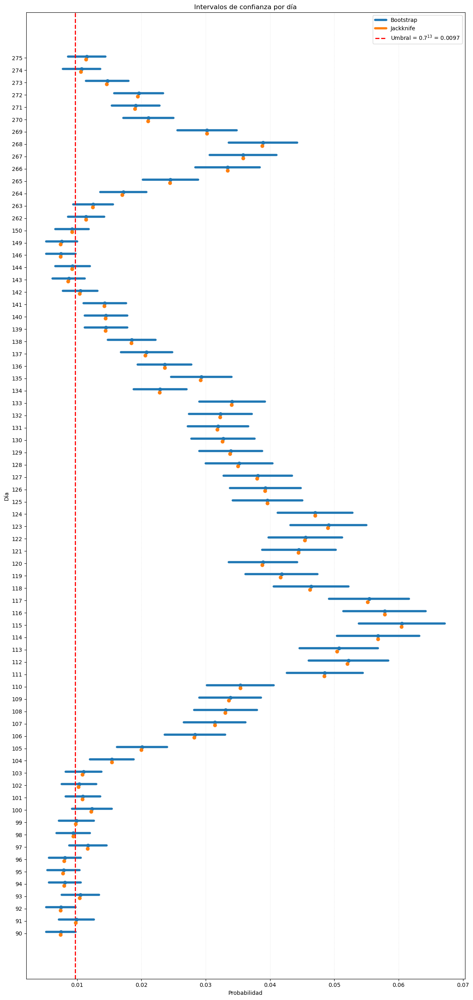

In [55]:
import numpy as np
import matplotlib.pyplot as plt

threshold = 0.7**13

days = [x["day"] for x in filtered]

fig, ax = plt.subplots(figsize=(12, max(6, len(days) * 0.35)))

# Posición vertical de cada día
y = np.arange(len(days))

for i, item in enumerate(filtered):

    # -------------------------
    # ci_prob_bootstrap
    # -------------------------
    bootstrap_low, bootstrap_high = item["ci_prob_bootstrap"]

    ax.plot(
        [bootstrap_low, bootstrap_high],
        [y[i] + 0.12, y[i] + 0.12],
        color="tab:blue",
        linewidth=4,
        solid_capstyle="round",
        label="Bootstrap" if i == 0 else None
    )

    # Punto central bootstrap
    ax.scatter(
        np.mean([bootstrap_low, bootstrap_high]),
        y[i] + 0.12,
        color="tab:blue",
        s=35,
        zorder=3
    )

    # -------------------------
    # ci_lengths_jack
    # -------------------------
    jack_low, jack_high = item["ci_lengths_jack"]

    ax.plot(
        [jack_low, jack_high],
        [y[i] - 0.12, y[i] - 0.12],
        color="tab:orange",
        linewidth=4,
        solid_capstyle="round",
        label="Jackknife" if i == 0 else None
    )

    # Punto central jackknife
    ax.scatter(
        np.mean([jack_low, jack_high]),
        y[i] - 0.12,
        color="tab:orange",
        s=35,
        zorder=3
    )


# --------------------------------
# Umbral
# --------------------------------
ax.axvline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Umbral = 0.7$^{{13}}$ = {threshold:.4f}"
)


# --------------------------------
# Formato
# --------------------------------
ax.set_yticks(y)
ax.set_yticklabels(days)

ax.set_ylabel("Día")
ax.set_xlabel("Probabilidad")

ax.set_title(
    "Intervalos de confianza por día"
)

ax.grid(
    axis="x",
    linestyle=":",
    alpha=0.4
)

ax.legend()

plt.tight_layout()
plt.show()





In [56]:
import numpy as np
import matplotlib.pyplot as plt

threshold = 0.7**13

days = [x["day"] for x in consecutive_euclidean]

fig, ax = plt.subplots(figsize=(12, max(6, len(days) * 0.35)))

# Posición vertical de cada día
y = np.arange(len(days))

for i, item in enumerate(consecutive_euclidean):

    # -------------------------
    # ci_prob_bootstrap
    # -------------------------
    bootstrap_low, bootstrap_high = item["ci_prob_bootstrap"]

    ax.plot(
        [bootstrap_low, bootstrap_high],
        [y[i] + 0.12, y[i] + 0.12],
        color="tab:blue",
        linewidth=4,
        solid_capstyle="round",
        label="Bootstrap" if i == 0 else None
    )

    # Punto central bootstrap
    ax.scatter(
        np.mean([bootstrap_low, bootstrap_high]),
        y[i] + 0.12,
        color="tab:blue",
        s=35,
        zorder=3
    )

    # -------------------------
    # ci_lengths_jack
    # -------------------------
    jack_low, jack_high = item["ci_lengths_jack"]

    ax.plot(
        [jack_low, jack_high],
        [y[i] - 0.12, y[i] - 0.12],
        color="tab:orange",
        linewidth=4,
        solid_capstyle="round",
        label="Jackknife" if i == 0 else None
    )

    # Punto central jackknife
    ax.scatter(
        np.mean([jack_low, jack_high]),
        y[i] - 0.12,
        color="tab:orange",
        s=35,
        zorder=3
    )


# --------------------------------
# Umbral
# --------------------------------
ax.axvline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Umbral = 0.7$^{{13}}$ = {threshold:.4f}"
)


# --------------------------------
# Formato
# --------------------------------
ax.set_yticks(y)
ax.set_yticklabels(days)

ax.set_ylabel("Día")
ax.set_xlabel("Probabilidad")

ax.set_title(
    "Intervalos de confianza por día"
)

ax.grid(
    axis="x",
    linestyle=":",
    alpha=0.4
)

ax.legend()

plt.tight_layout()
plt.show()



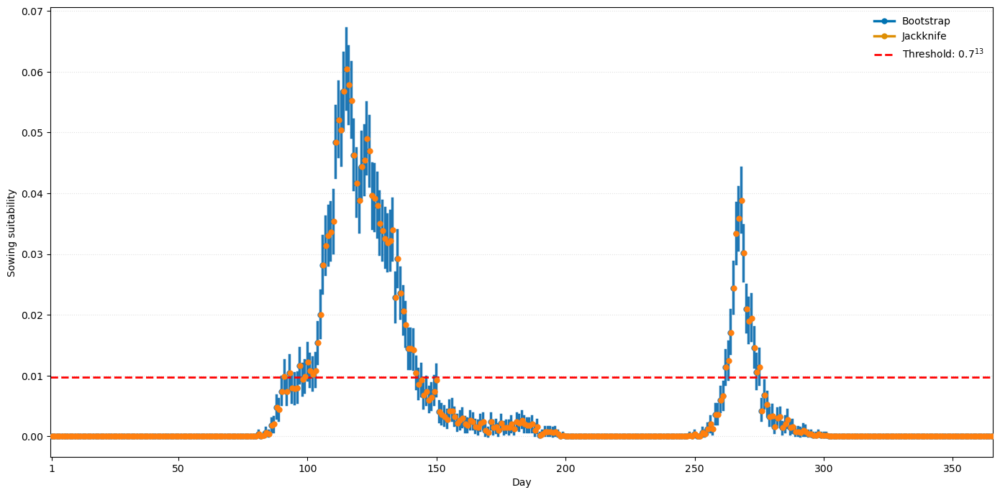

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Colores
# ============================================================

colorblind = sns.color_palette("colorblind")

blue = colorblind[0]
orange = colorblind[1]

# ============================================================
# Datos
# ============================================================

days = np.array([
    r["day"]
    for r in consecutive_euclidean
])

probabilities = np.array([
    r["emergence_probability"]
    for r in consecutive_euclidean
])

# Intervalos Bootstrap
ci_bootstrap = np.array([
    r["ci_prob_bootstrap"]
    for r in consecutive_euclidean
])

# Intervalos Jackknife
ci_jackknife = np.array([
    r["ci_lengths_jack"]
    for r in consecutive_euclidean
])

# ============================================================
# Límites de los intervalos
# ============================================================

bootstrap_low = ci_bootstrap[:, 0]
bootstrap_high = ci_bootstrap[:, 1]

jackknife_low = ci_jackknife[:, 0]
jackknife_high = ci_jackknife[:, 1]

# ============================================================
# Posiciones en X
# ============================================================

x = np.arange(len(days))

# Separación entre Bootstrap y Jackknife
offset = 0.12

# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

# ============================================================
# Bootstrap — AZUL
# ============================================================

for i in range(len(days)):

    ax.plot(
        [x[i] - offset, x[i] - offset],
        [bootstrap_low[i], bootstrap_high[i]],
        color="tab:blue",
        linewidth=2.5
    )

    ax.scatter(
        x[i] - offset,
        probabilities[i],
        color="tab:blue",
        s=25,
        zorder=3
    )

# ============================================================
# Jackknife — NARANJA
# ============================================================

for i in range(len(days)):

    ax.plot(
        [x[i] + offset, x[i] + offset],
        [jackknife_low[i], jackknife_high[i]],
        color="tab:orange",
        linewidth=2.5
    )

    ax.scatter(
        x[i] + offset,
        probabilities[i],
        color="tab:orange",
        s=25,
        zorder=3
    )

# ============================================================
# Umbral teórico
# ============================================================

threshold = 0.7**13

ax.axhline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"Threshold: $0.7^{13}$"
)

# ============================================================
# Eje X
# ============================================================

tick_days = [
    1, 50, 100, 150,
    200, 250, 300, 350
]

tick_positions = [
    day - 1
    for day in tick_days
]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_days)

ax.set_xlim(
    -0.5,
    len(days) - 0.5
)

# ============================================================
# Ejes
# ============================================================

ax.set_xlabel("Day")
ax.set_ylabel("Sowing suitability")

# ============================================================
# Leyenda
# ============================================================

from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0], [0],
        color=blue,
        marker="o",
        linewidth=2.5,
        markersize=5,
        label="Bootstrap"
    ),
    Line2D(
        [0], [0],
        color=orange,
        marker="o",
        linewidth=2.5,
        markersize=5,
        label="Jackknife"
    ),
    Line2D(
        [0], [0],
        color="red",
        linestyle="--",
        linewidth=2,
        label=r"Threshold: $0.7^{13}$"
    )
]

ax.legend(
    handles=legend_elements,
    frameon=False
)

# ============================================================
# Estética
# ============================================================

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.4
)

plt.tight_layout()

plt.show()

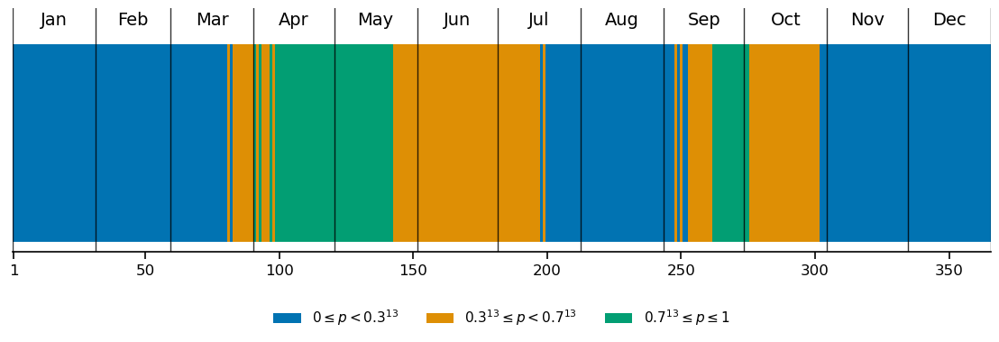

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Patch

# ============================================================
# Probabilidades
# ============================================================

n = 365

p = np.full(n, np.nan)

for r in consecutive_euclidean:
    day = r["day"]
    p[day - 1] = r["emergence_probability"]


# ============================================================
# Paleta colorblind
# ============================================================

palette = sns.color_palette("colorblind", n_colors=3)


# ============================================================
# Categorías de probabilidad
# ============================================================

bounds = [
    0,
    0.3**13,
    0.7**13,
    1.00
]

norm = BoundaryNorm(
    bounds,
    len(palette)
)


# ============================================================
# Colores de cada día
# ============================================================

colors = [
    palette[norm(x)]
    if not np.isnan(x)
    else (0.85, 0.85, 0.85)
    for x in p
]


# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 3.5)
)


# ============================================================
# Segmento horizontal
# ============================================================

for day in range(1, n + 1):

    ax.bar(
        day,
        1,
        width=1,
        bottom=0,
        color=colors[day - 1],
        edgecolor="none",
        align="center"
    )


# ============================================================
# Límites de los meses
# ============================================================

month_starts = [
    1, 32, 60, 91, 121, 152,
    182, 213, 244, 274, 305, 335
]

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# Inicio del siguiente año
month_ends = month_starts[1:] + [366]

for start, end in zip(month_starts, month_ends):

    ax.axvline(
        start - 0.5,
        color="black",
        linewidth=1.0,
        alpha=0.8
    )

# Línea final del año
ax.axvline(
    365.5,
    color="black",
    linewidth=1.0,
    alpha=0.8
)


# ============================================================
# Etiquetas de los meses
# ============================================================

month_midpoints = [
    (start + end - 1) / 2
    for start, end in zip(month_starts, month_ends)
]

for midpoint, month in zip(month_midpoints, month_names):

    ax.text(
        midpoint,
        1.08,
        month,
        ha="center",
        va="bottom",
        fontsize=14
    )


# ============================================================
# Ticks cada 50 días
# ============================================================

tick_days = np.arange(
    0,
    351,
    50
)

# Mantener la convención del gráfico anterior
label_days = [
    day + 1 if day == 0 else day
    for day in tick_days
]

ax.set_xticks(label_days)
ax.set_xticklabels(
    [str(day) for day in label_days],
    fontsize=12
)


# ============================================================
# Límites del gráfico
# ============================================================

ax.set_xlim(
    0.5,
    365.5
)

ax.set_ylim(
    -0.05,
    1.18
)


# ============================================================
# Apariencia
# ============================================================

ax.set_yticks([])

ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.spines["bottom"].set_linewidth(1.2)

ax.tick_params(
    axis="x",
    length=6,
    width=1.2
)


# ============================================================
# Leyenda
# ============================================================

legend_labels = [
    r"$0 \leq p < 0.3^{13}$",
    r"$0.3^{13} \leq p < 0.7^{13}$",
    r"$0.7^{13} \leq p \leq 1$"
]

legend_elements = [
    Patch(
        facecolor=palette[i],
        label=legend_labels[i]
    )
    for i in range(3)
]

ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=False,
    fontsize=11
)


# ============================================================
# Guardar
# ============================================================

# plt.savefig(
#     "Emergence_probability_horizontal.png",
#     dpi=300,
#     bbox_inches="tight",
#     pad_inches=0.05,
#     transparent=True
# )


plt.show()

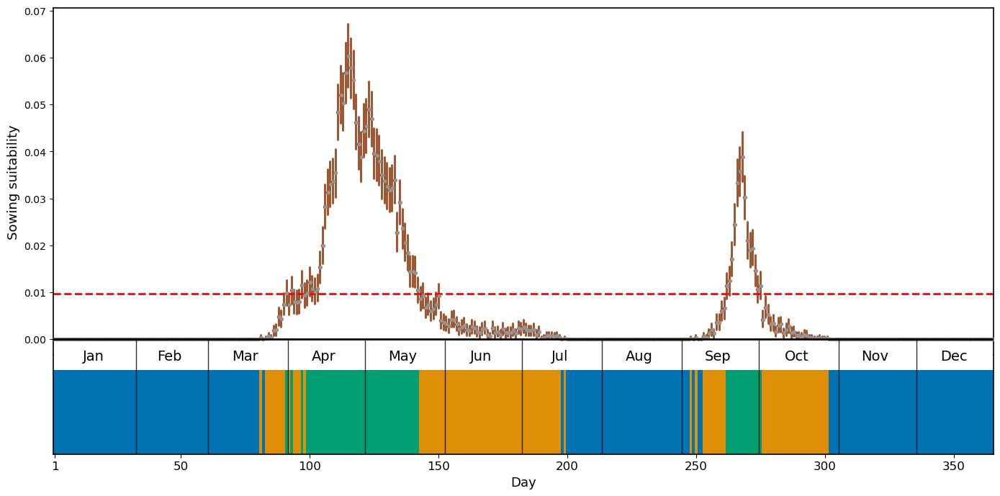

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm


# ============================================================
# Colores
# ============================================================

colorblind = sns.color_palette("colorblind")

blue = colorblind[0]
orange = colorblind[1]


# ============================================================
# Datos de probabilidad
# ============================================================

days = np.array([
    r["day"]
    for r in consecutive_euclidean
])

probabilities_bootstrap = np.array([
    r["p_bootstrap"]
    for r in consecutive_euclidean
])

ci_bootstrap = np.array([
    r["ci_prob_bootstrap"]
    for r in consecutive_euclidean
])


ci_jackknife = np.array([
    r["ci_lengths_jack"]
    for r in consecutive_euclidean
])

probabilities_jackknife = np.array([
    r["p_jackknife_mean"]
    for r in consecutive_euclidean
])


# ============================================================
# Límites de los intervalos
# ============================================================

bootstrap_low = ci_bootstrap[:, 0]
bootstrap_high = ci_bootstrap[:, 1]

jackknife_low = ci_jackknife[:, 0]
jackknife_high = ci_jackknife[:, 1]


# ============================================================
# Posiciones X
# ============================================================

x = days

offset = 0.12


# ============================================================
# Umbral teórico
# ============================================================

threshold = 0.7**13


# ============================================================
# Datos para la banda inferior
# ============================================================

n = 365

p = np.full(n, np.nan)

for r in consecutive_euclidean:

    day = r["day"]

    p[day - 1] = r["emergence_probability"]


# ============================================================
# Paleta
# ============================================================

palette = sns.color_palette(
    "colorblind",
    n_colors=3
)


# ============================================================
# Categorías de probabilidad
# ============================================================

bounds = [
    0,
    0.3**13,
    0.7**13,
    1.00
]

norm = BoundaryNorm(
    bounds,
    len(palette)
)


colors = [
    palette[norm(value)]
    if not np.isnan(value)
    else (0.85, 0.85, 0.85)
    for value in p
]


# ============================================================
# Figura
# ============================================================

fig, (ax_top, ax_bottom) = plt.subplots(
    2,
    1,
    figsize=(14, 7),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3.5, 1],
        "hspace": 0
    }
)


# ============================================================
# GRÁFICA SUPERIOR
# ============================================================

# ------------------------------------------------------------
# Bootstrap
# ------------------------------------------------------------

palette_2 = sns.color_palette(
    "colorblind",
    n_colors=8
)

for i in range(len(days)):

    ax_top.plot(
        [x[i] - offset, x[i] - offset],
        [
            bootstrap_low[i],
            bootstrap_high[i]
        ],
        color="sienna",
        linewidth=2.1,
        solid_capstyle="round"
    )

    ax_top.scatter(
        x[i] - offset,
        probabilities_bootstrap[i],
        color="sienna",
        s=8.2,
        zorder=3
    )


# ------------------------------------------------------------
# Jackknife
# ------------------------------------------------------------

for i in range(len(days)):

    ax_top.plot(
        [x[i] + offset, x[i] + offset],
        [
            jackknife_low[i],
            jackknife_high[i]
        ],
        color=palette_2[7],
        solid_capstyle="round",
        linewidth=2
    )

    ax_top.scatter(
        x[i] + offset,
        probabilities_jackknife[i],
        color=palette_2[7],
        s=8,
        zorder=3
    )


# ------------------------------------------------------------
# Umbral
# ------------------------------------------------------------

ax_top.axhline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2
)


zero = 0

ax_top.axhline(
    zero,
    color="black",
    linestyle="-",
    linewidth=2,
    zorder=5
)


# ------------------------------------------------------------
# Ejes superiores
# ------------------------------------------------------------

ax_top.set_ylabel(
    "Sowing suitability",
    fontsize=13
)

ax_top.grid(False)

ax_top.set_xlim(
    0.5,
    365.5
)


# ============================================================
# Bordes de la gráfica superior
# ============================================================

for spine in ax_top.spines.values():

    spine.set_linewidth(1.2)


# ============================================================
# Leyenda superior
# ============================================================

#legend_elements = [
#
#    Line2D(
#        [0],
#        [0],
#        color=blue,
#        marker="o",
#        linewidth=2.5,
#        markersize=5,
#        label="Bootstrap"
#    ),

#    Line2D(
#        [0],
#        [0],
#        color=orange,
#        marker="o",
#        linewidth=2.5,
#        markersize=5,
#        label="Jackknife"
#    ),

#    Line2D(
#        [0],
#        [0],
#        color="red",
#        linestyle="--",
#        linewidth=2,
#        label=r"Threshold: $0.7^{13}$"
#    )
#]

#ax_top.legend(
#    handles=legend_elements,
#    frameon=False,
#    loc="upper right"
#)


# ============================================================
# BANDA INFERIOR
# ============================================================

for day in range(1, n + 1):

    ax_bottom.bar(
        day,
        1,
        width=1,
        bottom=0,
        color=colors[day - 1],
        edgecolor="none",
        align="center"
    )


# ============================================================
# Límites de los meses
# ============================================================

month_starts = [
    1, 32, 60, 91, 121, 152,
    182, 213, 244, 274, 305, 335
]

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

month_ends = month_starts[1:] + [366]


# ============================================================
# Divisiones internas de los meses
# ============================================================

for start in month_starts[1:]:

    x_month = start + 0.5

    # --------------------------------------------------------
    # División en la banda inferior
    # --------------------------------------------------------

    ax_bottom.axvline(
        x_month,
        ymin=-0.5,
        ymax=2,
        color="black",
        linewidth=1.0,
        alpha=0.8,
        zorder=5
    )

    # --------------------------------------------------------
    # Extensión de la división hacia la gráfica superior
    #
    # En ax_top.get_xaxis_transform():
    #   y = 0  -> línea de y = 0
    #   y = 1  -> borde superior de ax_top
    #
    # Por tanto, la línea llega exactamente hasta y = 0.
    # --------------------------------------------------------

    ax_top.add_line(
        Line2D(
            [x_month, x_month],
            [-0.1, 0],
            color="black",
            linewidth=1.0,
            alpha=0.8,
            zorder=5,
            clip_on=True
        )
    )

# ============================================================
# Marco exterior de la banda
# ============================================================

# Borde inferior
ax_bottom.spines["bottom"].set_visible(True)
ax_bottom.spines["bottom"].set_linewidth(1.2)

# Borde izquierdo
ax_bottom.spines["left"].set_visible(True)
ax_bottom.spines["left"].set_linewidth(1.2)

# Borde derecho
ax_bottom.spines["right"].set_visible(True)
ax_bottom.spines["right"].set_linewidth(1.2)

# Borde superior
ax_bottom.spines["top"].set_visible(False)
ax_bottom.spines["top"].set_linewidth(0.2)


# ============================================================
# Etiquetas de los meses
# ============================================================

month_midpoints = [
    (start + end - 1) / 2
    for start, end in zip(
        month_starts,
        month_ends
    )
]


for midpoint, month in zip(
    month_midpoints,
    month_names
):

    ax_bottom.text(
        midpoint,
        1.08,
        month,
        ha="center",
        va="bottom",
        fontsize=14
    )


# ============================================================
# Ticks del DOY
# ============================================================

tick_days = [
    1, 50, 100, 150,
    200, 250, 300, 350
]

ax_bottom.set_xticks(
    tick_days
)

ax_bottom.set_xticklabels(
    tick_days,
    fontsize=12
)


# ============================================================
# Límites de la banda
# ============================================================

ax_bottom.set_xlim(
    0.5,
    365.5
)

ax_bottom.set_ylim(
    0,
    1.18
)


# ============================================================
# Eje Y
# ============================================================

ax_bottom.set_yticks([])


# ============================================================
# Eje X
# ============================================================

ax_bottom.set_xlabel(
    "Day",
    fontsize=13
)


# ============================================================
# Leyenda inferior
# ============================================================

#legend_labels = [
#    r"$0 \leq p < 0.3^{13}$",
#    r"$0.3^{13} \leq p < 0.7^{13}$",
#    r"$0.7^{13} \leq p \leq 1$"
#]


#legend_elements_band = [
#    Patch(
#        facecolor=palette[i],
#        label=legend_labels[i]
#    )
#    for i in range(3)
#]


#ax_bottom.legend(
#    handles=legend_elements_band,
#    loc="upper center",
#    bbox_to_anchor=(0.5, -0.30),
#    ncol=3,
#    frameon=False,
#    fontsize=11
#)


# ============================================================
# Separación entre ambas gráficas
# ============================================================

ax_top.spines["bottom"].set_visible(False)

ax_top.tick_params(
    axis="x",
    bottom=False,
    labelbottom=False
)


# ============================================================
# Ajuste final
# ============================================================

plt.tight_layout()


# ============================================================
# Guardar
# ============================================================

plt.savefig(
     "[Saxony][Rectangular][Euclidean]Sowing_windows.png",
     dpi=300,
     bbox_inches="tight",
     pad_inches=0.05,
     transparent=True
)


plt.show()


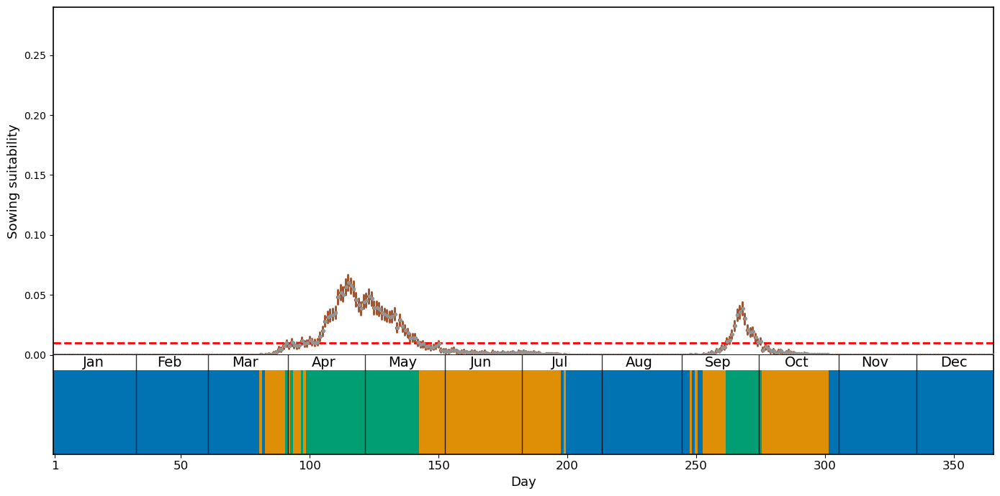

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm


# ============================================================
# Colores
# ============================================================

colorblind = sns.color_palette("colorblind")

blue = colorblind[0]
orange = colorblind[1]


# ============================================================
# Datos de probabilidad
# ============================================================

days = np.array([
    r["day"]
    for r in consecutive_euclidean
])

probabilities_bootstrap = np.array([
    r["p_bootstrap"]
    for r in consecutive_euclidean
])

ci_bootstrap = np.array([
    r["ci_prob_bootstrap"]
    for r in consecutive_euclidean
])


ci_jackknife = np.array([
    r["ci_lengths_jack"]
    for r in consecutive_euclidean
])

probabilities_jackknife = np.array([
    r["p_jackknife_mean"]
    for r in consecutive_euclidean
])


# ============================================================
# Límites de los intervalos
# ============================================================

bootstrap_low = ci_bootstrap[:, 0]
bootstrap_high = ci_bootstrap[:, 1]

jackknife_low = ci_jackknife[:, 0]
jackknife_high = ci_jackknife[:, 1]


# ============================================================
# Posiciones X
# ============================================================

x = days

offset = 0.12


# ============================================================
# Umbral teórico
# ============================================================

threshold = 0.7**13


# ============================================================
# Datos para la banda inferior
# ============================================================

n = 365

p = np.full(n, np.nan)

for r in consecutive_euclidean:

    day = r["day"]

    p[day - 1] = r["emergence_probability"]


# ============================================================
# Paleta
# ============================================================

palette = sns.color_palette(
    "colorblind",
    n_colors=3
)


# ============================================================
# Categorías de probabilidad
# ============================================================

bounds = [
    0,
    0.3**13,
    0.7**13,
    1.00
]

norm = BoundaryNorm(
    bounds,
    len(palette)
)


colors = [
    palette[norm(value)]
    if not np.isnan(value)
    else (0.85, 0.85, 0.85)
    for value in p
]


# ============================================================
# Figura
# ============================================================

fig, (ax_top, ax_bottom) = plt.subplots(
    2,
    1,
    figsize=(14, 7),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3.5, 1],
        "hspace": 0
    }
)


# ============================================================
# GRÁFICA SUPERIOR
# ============================================================

# ------------------------------------------------------------
# Bootstrap
# ------------------------------------------------------------

palette_2 = sns.color_palette(
    "colorblind",
    n_colors=8
)

for i in range(len(days)):

    ax_top.plot(
        [x[i] - offset, x[i] - offset],
        [
            bootstrap_low[i],
            bootstrap_high[i]
        ],
        color="sienna",
        linewidth=2.1,
        solid_capstyle="round"
    )

    ax_top.scatter(
        x[i] - offset,
        probabilities_bootstrap[i],
        color="sienna",
        s=8.2,
        zorder=3
    )


# ------------------------------------------------------------
# Jackknife
# ------------------------------------------------------------

for i in range(len(days)):

    ax_top.plot(
        [x[i] + offset, x[i] + offset],
        [
            jackknife_low[i],
            jackknife_high[i]
        ],
        color=palette_2[7],
        solid_capstyle="round",
        linewidth=2
    )

    ax_top.scatter(
        x[i] + offset,
        probabilities_jackknife[i],
        color=palette_2[7],
        s=8,
        zorder=3
    )


# ------------------------------------------------------------
# Umbral
# ------------------------------------------------------------

ax_top.axhline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2
)


zero = 0

ax_top.axhline(
    zero,
    color="black",
    linestyle="-",
    linewidth=2,
    zorder=5
)


# ------------------------------------------------------------
# Ejes superiores
# ------------------------------------------------------------

ax_top.set_ylabel(
    "Sowing suitability",
    fontsize=13
)

ax_top.grid(False)

ax_top.set_xlim(
    0.5,
    365.5
)


# ============================================================
# Bordes de la gráfica superior
# ============================================================

for spine in ax_top.spines.values():

    spine.set_linewidth(1.2)


# ============================================================
# Leyenda superior
# ============================================================

#legend_elements = [
#
#    Line2D(
#        [0],
#        [0],
#        color=blue,
#        marker="o",
#        linewidth=2.5,
#        markersize=5,
#        label="Bootstrap"
#    ),

#    Line2D(
#        [0],
#        [0],
#        color=orange,
#        marker="o",
#        linewidth=2.5,
#        markersize=5,
#        label="Jackknife"
#    ),

#    Line2D(
#        [0],
#        [0],
#        color="red",
#        linestyle="--",
#        linewidth=2,
#        label=r"Threshold: $0.7^{13}$"
#    )
#]

#ax_top.legend(
#    handles=legend_elements,
#    frameon=False,
#    loc="upper right"
#)


# ============================================================
# BANDA INFERIOR
# ============================================================

for day in range(1, n + 1):

    ax_bottom.bar(
        day,
        1,
        width=1,
        bottom=0,
        color=colors[day - 1],
        edgecolor="none",
        align="center"
    )


# ============================================================
# Límites de los meses
# ============================================================

month_starts = [
    1, 32, 60, 91, 121, 152,
    182, 213, 244, 274, 305, 335
]

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

month_ends = month_starts[1:] + [366]


# ============================================================
# Divisiones internas de los meses
# ============================================================

for start in month_starts[1:]:

    x_month = start + 0.5

    # --------------------------------------------------------
    # División en la banda inferior
    # --------------------------------------------------------

    ax_bottom.axvline(
        x_month,
        ymin=-0.5,
        ymax=2,
        color="black",
        linewidth=1.0,
        alpha=0.8,
        zorder=5
    )

    # --------------------------------------------------------
    # Extensión de la división hacia la gráfica superior
    #
    # En ax_top.get_xaxis_transform():
    #   y = 0  -> línea de y = 0
    #   y = 1  -> borde superior de ax_top
    #
    # Por tanto, la línea llega exactamente hasta y = 0.
    # --------------------------------------------------------

    ax_top.add_line(
        Line2D(
            [x_month, x_month],
            [-0.1, 0],
            color="black",
            linewidth=1.0,
            alpha=0.8,
            zorder=5,
            clip_on=True
        )
    )
    
    ax_top.set_ylim(0, 0.29)

    ax_top.set_yticks(
        np.arange(0, 0.30, 0.05)
    )

# ============================================================
# Marco exterior de la banda
# ============================================================

# Borde inferior
ax_bottom.spines["bottom"].set_visible(True)
ax_bottom.spines["bottom"].set_linewidth(1.2)

# Borde izquierdo
ax_bottom.spines["left"].set_visible(True)
ax_bottom.spines["left"].set_linewidth(1.2)

# Borde derecho
ax_bottom.spines["right"].set_visible(True)
ax_bottom.spines["right"].set_linewidth(1.2)

# Borde superior
ax_bottom.spines["top"].set_visible(False)
ax_bottom.spines["top"].set_linewidth(0.2)


# ============================================================
# Etiquetas de los meses
# ============================================================

month_midpoints = [
    (start + end - 1) / 2
    for start, end in zip(
        month_starts,
        month_ends
    )
]


for midpoint, month in zip(
    month_midpoints,
    month_names
):

    ax_bottom.text(
        midpoint,
        1.005,
        month,
        ha="center",
        va="bottom",
        fontsize=14
    )


# ============================================================
# Ticks del DOY
# ============================================================

tick_days = [
    1, 50, 100, 150,
    200, 250, 300, 350
]

ax_bottom.set_xticks(
    tick_days
)

ax_bottom.set_xticklabels(
    tick_days,
    fontsize=12
)


# ============================================================
# Límites de la banda
# ============================================================

ax_bottom.set_xlim(
    0.5,
    365.5
)

ax_bottom.set_ylim(
    0,
    1.18
)


# ============================================================
# Eje Y
# ============================================================

ax_bottom.set_yticks([])


# ============================================================
# Eje X
# ============================================================

ax_bottom.set_xlabel(
    "Day",
    fontsize=13
)


# ============================================================
# Leyenda inferior
# ============================================================

#legend_labels = [
#    r"$0 \leq p < 0.3^{13}$",
#    r"$0.3^{13} \leq p < 0.7^{13}$",
#    r"$0.7^{13} \leq p \leq 1$"
#]


#legend_elements_band = [
#    Patch(
#        facecolor=palette[i],
#        label=legend_labels[i]
#    )
#    for i in range(3)
#]


#ax_bottom.legend(
#    handles=legend_elements_band,
#    loc="upper center",
#    bbox_to_anchor=(0.5, -0.30),
#    ncol=3,
#    frameon=False,
#    fontsize=11
#)


# ============================================================
# Separación entre ambas gráficas
# ============================================================

ax_top.spines["bottom"].set_visible(False)

ax_top.tick_params(
    axis="x",
    bottom=False,
    labelbottom=False
)



# ============================================================
# Ajuste final
# ============================================================

plt.tight_layout()


# ============================================================
# Guardar
# ============================================================

plt.savefig(
    "[Saxony][Rectangular][Euclidean]Sowing_windows.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05,
    transparent=True
)


plt.show()

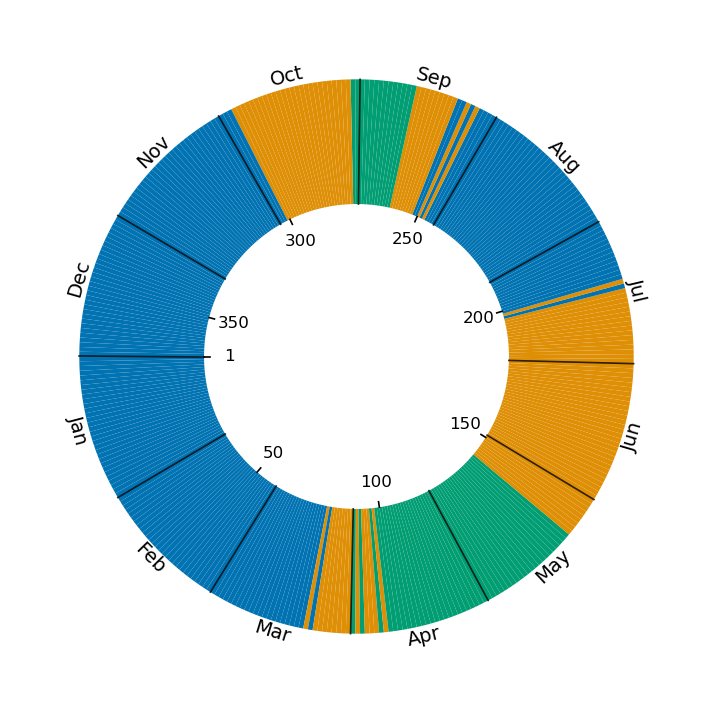

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Patch

# ============================================================
# Probabilidades
# ============================================================

n = 365

p = np.full(n, np.nan)

for r in consecutive_euclidean:
    day = r["day"]
    p[day - 1] = r["emergence_probability"]

# ============================================================
# Paleta colorblind
# ============================================================

palette = sns.color_palette("colorblind", n_colors=3)

# ============================================================
# Categorías de probabilidad
# ============================================================

bounds = [0, 0.3**13, 0.7**13, 1.00]

norm = BoundaryNorm(
    bounds,
    len(palette)
)

colors = [
    palette[norm(x)]
    if not np.isnan(x)
    else (0.85, 0.85, 0.85)
    for x in p
]

# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(figsize=(9, 9))

ax.pie(
    np.ones(n),
    colors=colors,
    startangle=180,
    counterclock=True,
    wedgeprops={
        "width": 0.45,
        "edgecolor": "none"
    }
)

# ============================================================
# Ticks cada 50 días
# ============================================================

tick_days = list(np.arange(0, 351, 50))

for day in tick_days:

    angle = np.deg2rad(
        180 + day * 360 / 365
    )

    ax.plot(
        [np.cos(angle) * 0.55, np.cos(angle) * 0.53],
        [np.sin(angle) * 0.55, np.sin(angle) * 0.53],
        color="black",
        linewidth=1.2
    )

    label_day = day + 1 if day == 0 else day

    ax.text(
        np.cos(angle) * 0.46,
        np.sin(angle) * 0.46,
        str(label_day),
        ha="center",
        va="center",
        fontsize=12
    )

# ============================================================
# Límites de los meses
# ============================================================

month_starts = [
    1, 32, 60, 91, 121, 152,
    182, 213, 244, 274, 305, 335
]

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

def day_to_angle(day):
    return 180 + (day - 1) * 360 / 365

for day in month_starts:

    angle = np.deg2rad(day_to_angle(day))

    ax.plot(
        [np.cos(angle) * 0.55, np.cos(angle)],
        [np.sin(angle) * 0.55, np.sin(angle)],
        color="black",
        linewidth=1.2,
        alpha=0.8
    )


# ============================================================
# Etiquetas de los meses — siguiendo la curvatura del círculo
# ============================================================

month_label_radius = 1.04

# Día central aproximado de cada mes
month_midpoints = [
    16, 46, 75, 106, 136, 167,
    197, 228, 259, 289, 320, 350
]

for day, month in zip(month_midpoints, month_names):

    angle_deg = day_to_angle(day)

    angle = np.deg2rad(angle_deg)

    # Posición sobre la circunferencia
    x = np.cos(angle) * month_label_radius
    y = np.sin(angle) * month_label_radius

    # Rotación tangencial:
    # el texto sigue la dirección de la circunferencia
    rotation = angle_deg + 90

    # Evitar que el texto quede invertido
    if 90 < rotation % 360 < 270:
        rotation += 180

    ax.text(
        x,
        y,
        month,
        ha="center",
        va="center",
        fontsize=14,
        rotation=rotation,
        rotation_mode="anchor"
    )


# ============================================================
# Leyenda
# ============================================================

#legend_labels = [
#    "0.00 – 0.25",
#    "0.25 – 0.50",
#    "0.50 – 0.75",
#    "0.75 – 1.00"
#]

#legend_elements = [
#    Patch(facecolor=palette[i], label=legend_labels[i])
#    for i in range(3)
#]

#ax.legend(
#    handles=legend_elements,
#    loc="center",
#    bbox_to_anchor=(0.5, 0.5),
#    frameon=False
#)

# ============================================================
# Apariencia
# ============================================================

ax.set_aspect("equal")
ax.axis("off")

plt.savefig(
    "[Saxony][Circular][Euclidean]NO_CI.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0,
    transparent=True
)

plt.show()

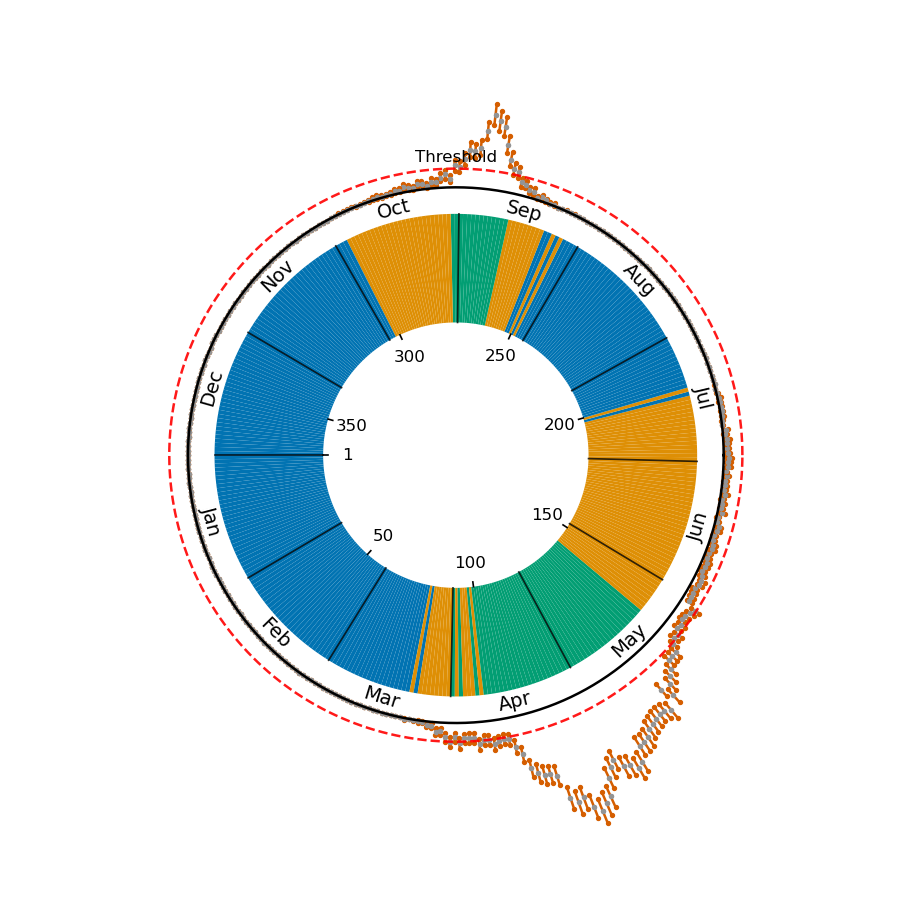

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import BoundaryNorm


# ============================================================
# Parámetros
# ============================================================

n = 365

# Círculo basal
r0 = 1.11

# Radio de las etiquetas de los meses
month_label_radius = 1.05

# Escala visual de los intervalos
scale = 8

# Probabilidad teórica de referencia
threshold = 0.7**13


# ============================================================
# Probabilidades
# ============================================================

p = np.full(n, np.nan)

for r in consecutive_euclidean:

    day = r["day"]

    p[day - 1] = r["emergence_probability"]


# ============================================================
# Paleta colorblind
# ============================================================

palette = sns.color_palette(
    "colorblind",
    n_colors=3
)


# ============================================================
# Categorías de probabilidad
# ============================================================

bounds = [
    0,
    0.3**13,
    0.7**13,
    1.00
]

norm = BoundaryNorm(
    bounds,
    len(palette)
)

colors = [
    palette[norm(x)]
    if not np.isnan(x)
    else (0.85, 0.85, 0.85)
    for x in p
]


# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 9),
    subplot_kw={"projection": "polar"},
    constrained_layout=True
)


# ============================================================
# Ángulos de los 365 días
# ============================================================

theta = np.linspace(
    0,
    2 * np.pi,
    n,
    endpoint=False
)

# Día 1 comienza al Este
theta = theta[::1] + np.pi

# Mantener los ángulos dentro de [0, 2π]
theta = np.mod(theta, 2 * np.pi)


angular_width = 2 * np.pi / n


# ============================================================
# Anillo de probabilidades
# ============================================================

ax.bar(
    theta,
    np.full(n, 0.45),
    width=angular_width,
    bottom=0.55,
    color=colors,
    edgecolor="none",
    align="edge"
)


# ============================================================
# Función de conversión día → ángulo
# ============================================================

def day_to_angle(day):

    return np.mod(
        np.pi + (day - 1) * 2 * np.pi / 365,
        2 * np.pi
    )


# ============================================================
# Ticks cada 50 días
# ============================================================

tick_days = np.arange(
    0,
    351,
    50
)

for day in tick_days:

    actual_day = day + 1 if day == 0 else day

    angle = day_to_angle(actual_day)

    # --------------------------------------------------------
    # Tick
    # --------------------------------------------------------

    ax.plot(
        [angle, angle],
        [0.55, 0.53],
        color="black",
        linewidth=1.2,
        zorder=20
    )

    # --------------------------------------------------------
    # Número del día
    # --------------------------------------------------------

    ax.text(
        angle,
        0.45,
        str(actual_day),
        ha="center",
        va="center",
        fontsize=12,
        zorder=20
    )


# ============================================================
# Límites de los meses
# ============================================================

month_starts = [
    1, 32, 60, 91, 121, 152,
    182, 213, 244, 274, 305, 335
]

# Día central aproximado de cada mes
month_midpoints = [
    16, 46, 75, 106, 136, 167,
    197, 228, 259, 289, 320, 350
]


month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]


# ============================================================
# Líneas de separación de meses
# ============================================================

for day in month_starts:

    angle = day_to_angle(day)

    ax.plot(
        [angle, angle],
        [0.55, 1.00],
        color="black",
        linewidth=1.2,
        alpha=0.8,
        zorder=15
    )


# ============================================================
# Etiquetas de los meses
# ============================================================

for day, month in zip(
    month_midpoints,
    month_names
):

    angle = day_to_angle(day)

    # Ángulo en grados para determinar orientación
    angle_deg = np.rad2deg(angle)

    rotation = angle_deg + 90

    # Evitar texto invertido
    if 90 < rotation % 360 < 270:
        rotation += 180

    # IMPORTANTE:
    # En coordenadas polares usamos directamente
    # (ángulo, radio), NO (x, y).

    ax.text(
        angle,
        month_label_radius,
        month,
        ha="center",
        va="center",
        fontsize=14,
        rotation=rotation,
        rotation_mode="anchor",
        zorder=30
    )


# ============================================================
# Círculo basal
# ============================================================

theta_circle = np.linspace(
    0,
    2 * np.pi,
    1000
)

ax.plot(
    theta_circle,
    np.full_like(
        theta_circle,
        r0
    ),
    color="black",
    linewidth=1.8,
    zorder=25
)


# ============================================================
# Intervalos de confianza
# ============================================================

palette_2 = sns.color_palette(
    "colorblind",
    n_colors=8
)

for i, item in enumerate(
    consecutive_euclidean
):

    angle = day_to_angle(
        item["day"]
    )

    # ========================================================
    # Bootstrap
    # ========================================================

    bootstrap_low, bootstrap_high = (
        item["ci_prob_bootstrap"]
    )

    bootstrap_low = (
        r0
        + bootstrap_low * scale
    )

    bootstrap_high = (
        r0
        + bootstrap_high * scale
    )

    ax.plot(
        [angle, angle],
        [
            bootstrap_low,
            bootstrap_high
        ],
        color=palette_2[3],
        linewidth=1.8,
        solid_capstyle="round",
        zorder=5,
        label=(
            "Bootstrap"
            if i == 0
            else None
        )
    )

    ax.scatter(
        [angle, angle],
        [
            bootstrap_low,
            bootstrap_high
        ],
        color=palette_2[3],
        s=8,
        zorder=6
    )

    # ========================================================
    # Jackknife
    # ========================================================

    jack_low, jack_high = (
        item["ci_lengths_jack"]
    )

    jack_low = (
        r0
        + jack_low * scale
    )

    jack_high = (
        r0
        + jack_high * scale
    )

    ax.plot(
        [angle, angle],
        [
            jack_low,
            jack_high
        ],
        color=palette_2[7],
        linewidth=1.8,
        solid_capstyle="round",
        zorder=5,
        label=(
            "Jackknife"
            if i == 0
            else None
        )
    )

    ax.scatter(
        [angle, angle],
        [
            jack_low,
            jack_high
        ],
        color=palette_2[7],
        s=8,
        zorder=6
    )


# ============================================================
# Círculo de referencia: 0.7^13
# ============================================================

threshold_radius = (
    r0
    + threshold * scale
)

ax.plot(
    theta_circle,
    np.full_like(
        theta_circle,
        threshold_radius
    ),
    color="red",
    linestyle="--",
    linewidth=1.8,
    alpha=0.9,
    zorder=10
)

# ============================================================
# Etiqueta "Threshold" siguiendo la curvatura
# ============================================================

threshold_angle = np.pi/2

threshold_angle_deg = np.rad2deg(
    threshold_angle
)

rotation = threshold_angle_deg + 90

# Evitar texto invertido
if 90 <= rotation % 360 <= 270:
    rotation += 180

ax.text(
    threshold_angle,
    threshold_radius + 0.05,
    "Threshold",
    ha="center",
    va="center",
    fontsize=12,
    color="black",
    rotation=rotation,
    rotation_mode="anchor",
    zorder=30
)


# ============================================================
# Límite radial
# ============================================================

max_probability = max(
    max(
        item["ci_prob_bootstrap"][1],
        item["ci_lengths_jack"][1]
    )
    for item in consecutive_euclidean
)

max_radius = (
    r0
    + max(
        threshold,
        max_probability
    ) * scale
    + 0.20
)

ax.set_ylim(
    0,
    max_radius
)


# ============================================================
# Orientación
# ============================================================

ax.set_theta_zero_location("E")
ax.set_theta_direction(1)


# ============================================================
# Apariencia
# ============================================================

ax.set_xticks([])
ax.set_yticks([])

ax.grid(False)

ax.spines["polar"].set_visible(False)





# ============================================================
# Guardar
# ============================================================

plt.savefig(
    "Emergence_probability_CI2.png",
    dpi=300,
    transparent=True
)


plt.show()

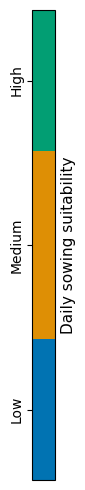

In [63]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import seaborn as sns

palette = sns.color_palette(
    "colorblind",
    n_colors=3
)

# ============================================================
# Colormap
# ============================================================

cmap = LinearSegmentedColormap.from_list(
    "probability",
    [
        (0.00, palette[0]),
        (0.30, palette[0]),
        (0.30, palette[1]),
        (0.70, palette[1]),
        (0.70, palette[2]),
        (1.00, palette[2])
    ]
)

norm = Normalize(
    vmin=0,
    vmax=1
)

# ============================================================
# Figura exclusiva para la barra
# ============================================================

fig, ax = plt.subplots(figsize=(1.5, 5))

sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=norm
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="vertical",
    fraction=0.5,
    pad=0.05
)

# ============================================================
# Etiqueta
# ============================================================

cbar.set_label(
    "Daily sowing suitability",
    fontsize=11
)

# ============================================================
# Categorías
# ============================================================

cbar.set_ticks([
    0.15,
    0.50,
    0.85
])

cbar.ax.set_yticklabels(
    ["Low", "Medium", "High"],
    rotation=90,
    va="center",
    ha="center"
)

# Separar las etiquetas de los ticks
cbar.ax.tick_params(
    axis="y",
    pad=7
)


cbar.ax.yaxis.set_ticks_position("left")

# ============================================================
# Ocultar eje auxiliar
# ============================================================

ax.remove()

plt.tight_layout()

plt.savefig(
    "Sowing suitability.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0,
    transparent= True
)

plt.show()

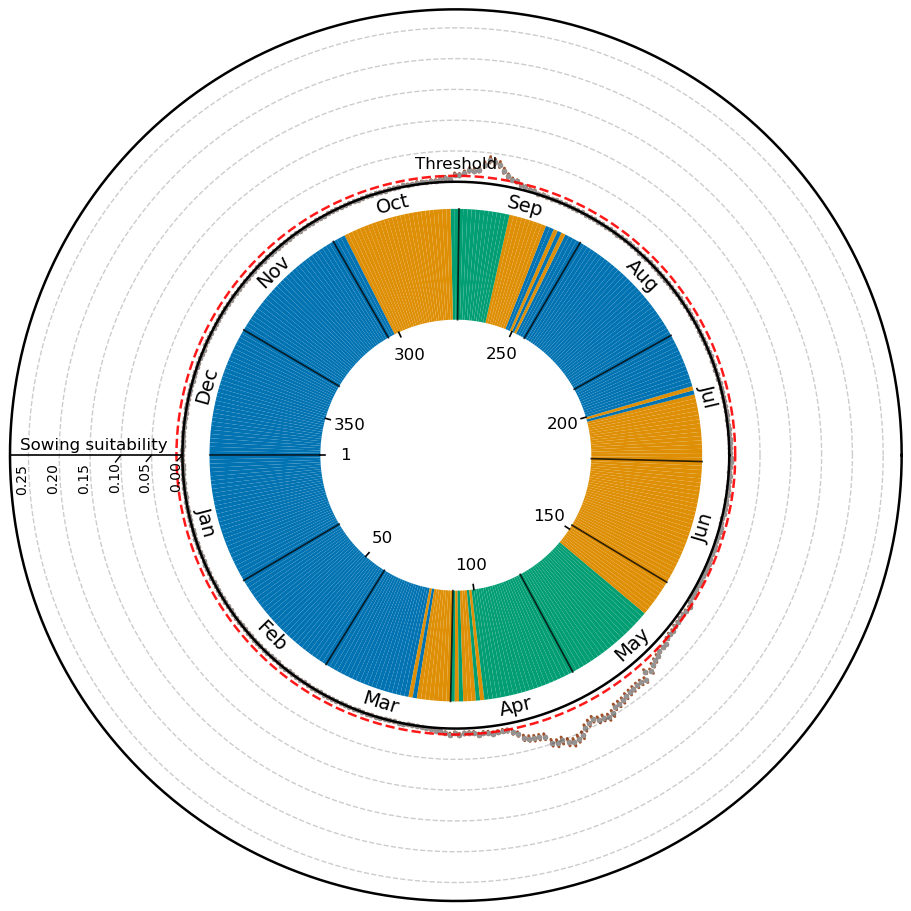

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import BoundaryNorm


# ============================================================
# Parámetros
# ============================================================

n = 365

# Círculo basal
r0 = 1.11

# Radio de las etiquetas de los meses
month_label_radius = 1.05

# Escala visual de los intervalos
scale = 2.5

# Probabilidad teórica de referencia
threshold = 0.7**13


# ============================================================
# Probabilidades
# ============================================================

p = np.full(n, np.nan)

for r in consecutive_euclidean:

    day = r["day"]

    p[day - 1] = r["emergence_probability"]

probabilities_bootstrap = np.array([
    r["p_bootstrap"]
    for r in consecutive_euclidean
])



probabilities_jackknife = np.array([
    r["p_jackknife_mean"]
    for r in consecutive_euclidean
])

# ============================================================
# Paleta colorblind
# ============================================================

palette = sns.color_palette(
    "colorblind",
    n_colors=3
)


# ============================================================
# Categorías de probabilidad
# ============================================================

bounds = [
    0,
    0.3**13,
    0.7**13,
    1.00
]

norm = BoundaryNorm(
    bounds,
    len(palette)
)

colors = [
    palette[norm(x)]
    if not np.isnan(x)
    else (0.85, 0.85, 0.85)
    for x in p
]


# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 9),
    subplot_kw={"projection": "polar"},
    constrained_layout=True
)


# ============================================================
# Ángulos de los 365 días
# ============================================================

theta = np.linspace(
    0,
    2 * np.pi,
    n,
    endpoint=False
)

# Día 1 comienza al Este
theta = theta[::1] + np.pi

# Mantener los ángulos dentro de [0, 2π]
theta = np.mod(theta, 2 * np.pi)


angular_width = 2 * np.pi / n


# ============================================================
# Anillo de probabilidades
# ============================================================

ax.bar(
    theta,
    np.full(n, 0.45),
    width=angular_width,
    bottom=0.55,
    color=colors,
    edgecolor="none",
    align="edge"
)


# ============================================================
# Función de conversión día → ángulo
# ============================================================

def day_to_angle(day):

    return np.mod(
        np.pi + (day - 1) * 2 * np.pi / 365,
        2 * np.pi
    )


# ============================================================
# Ticks cada 50 días
# ============================================================

tick_days = np.arange(
    0,
    351,
    50
)

for day in tick_days:

    actual_day = day + 1 if day == 0 else day

    angle = day_to_angle(actual_day)

    # --------------------------------------------------------
    # Tick
    # --------------------------------------------------------

    ax.plot(
        [angle, angle],
        [0.55, 0.53],
        color="black",
        linewidth=1.2,
        zorder=20
    )

    # --------------------------------------------------------
    # Número del día
    # --------------------------------------------------------

    ax.text(
        angle,
        0.45,
        str(actual_day),
        ha="center",
        va="center",
        fontsize=12,
        zorder=20
    )


# ============================================================
# Límites de los meses
# ============================================================

month_starts = [
    1, 32, 60, 91, 121, 152,
    182, 213, 244, 274, 305, 335
]

# Día central aproximado de cada mes
month_midpoints = [
    16, 46, 75, 106, 136, 167,
    197, 228, 259, 289, 320, 350
]


month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]


# ============================================================
# Líneas de separación de meses
# ============================================================

for day in month_starts:

    angle = day_to_angle(day)

    ax.plot(
        [angle, angle],
        [0.55, 1.00],
        color="black",
        linewidth=1.2,
        alpha=0.8,
        zorder=15
    )


# ============================================================
# Etiquetas de los meses
# ============================================================

for day, month in zip(
    month_midpoints,
    month_names
):

    angle = day_to_angle(day)

    # Ángulo en grados para determinar orientación
    angle_deg = np.rad2deg(angle)

    rotation = angle_deg + 90

    # Evitar texto invertido
    if 90 < rotation % 360 < 270:
        rotation += 180

    # IMPORTANTE:
    # En coordenadas polares usamos directamente
    # (ángulo, radio), NO (x, y).

    ax.text(
        angle,
        month_label_radius,
        month,
        ha="center",
        va="center",
        fontsize=14,
        rotation=rotation,
        rotation_mode="anchor",
        zorder=30
    )


# ============================================================
# Círculo basal
# ============================================================

theta_circle = np.linspace(
    0,
    2 * np.pi,
    1000
)

ax.plot(
    theta_circle,
    np.full_like(
        theta_circle,
        r0
    ),
    color="black",
    linewidth=1.8,
    zorder=25
)


# ============================================================
# Escala de probabilidad en theta = pi
# ============================================================

prob_ticks = np.arange(0, 0.3, 0.05)

prob_angle = np.pi

prob_angle_deg = np.rad2deg(
    prob_angle
)

rotation = prob_angle_deg + 90

# Evitar texto invertido
if 90 <= rotation % 360 <= 270:
    rotation += 180

for prob in prob_ticks:

    # --------------------------------------------------------
    # Radio correspondiente a la probabilidad
    # --------------------------------------------------------

    r = r0 + prob * scale

    # --------------------------------------------------------
    # Tick
    # --------------------------------------------------------

    ax.plot(
        [prob_angle, prob_angle + 0.02],
        [r , r + 0.022],
        color="black",
        linewidth=1.0,
        zorder=30
    )

    # --------------------------------------------------------
    # Etiqueta
    # --------------------------------------------------------

    ax.text(
        prob_angle + 0.019,
        r+0.025,
        f"{prob:.2f}",
        ha="right",
        va="center",
        fontsize=10,
        rotation=rotation,
        rotation_mode="anchor",
        zorder=30
    )
    
    if prob > 0: 
    
        ax.plot(
        theta_circle,
        np.full_like(
            theta_circle,
            r
        ),
        color="black",
        linestyle="--",
        alpha=0.2,
        linewidth=1,
        zorder=10,
        clip_on=False
        )
    

ax.plot(
    theta_circle,
    np.full_like(
    theta_circle,
    r0 + 0.28 * scale
    ),
    color="black",
    linestyle="-",
    linewidth=1.8,
    zorder=10,
    clip_on=False
    )
            
r_start = r0
r_end = r0 + 0.28 * scale

ax.plot(
    [np.pi, np.pi],
    [r_start, r_end],
    color="black",
    linewidth=1.2,
    zorder=25,
    clip_on=False
)

ax.text(
    np.pi-0.007,
    r0 + 0.27 * scale - 0.315,
    "Sowing suitability",
    ha="center",
    va="bottom",
    fontsize=12,
    fontweight=500,
    rotation=0,
    rotation_mode="anchor",
    zorder=30
)
        
# ============================================================
# Intervalos de confianza
# ============================================================

palette_2 = sns.color_palette(
    "colorblind",
    n_colors=8
)

for i, item in enumerate(
    consecutive_euclidean
):

    angle = day_to_angle(
        item["day"]
    )

    # ========================================================
    # Bootstrap
    # ========================================================

    bootstrap_low, bootstrap_high = (
        item["ci_prob_bootstrap"]
    )

    bootstrap_low = (
        r0
        + bootstrap_low * scale
    )

    bootstrap_high = (
        r0
        + bootstrap_high * scale
    )

    ax.plot(
        [angle, angle],
        [
            bootstrap_low,
            bootstrap_high
        ],
        color="sienna",
        linewidth=2.1,
        solid_capstyle="round",
        zorder=5,
        label=(
            "Bootstrap"
            if i == 0
            else None
        )
    )

    # Círculo únicamente en la estimación puntual
    ax.scatter(
        angle,
        r0 + probabilities_bootstrap[i] * scale,
        color="sienna",
        s=8.2,
        zorder=6
    )
    # ========================================================
    # Jackknife
    # ========================================================

    jack_low, jack_high = (
        item["ci_lengths_jack"]
    )

    jack_low = (
        r0
        + jack_low * scale
    )

    jack_high = (
        r0
        + jack_high * scale
    )

    ax.plot(
        [angle, angle],
        [
            jack_low,
            jack_high
        ],
        color=palette_2[7],
        linewidth=2.1,
        solid_capstyle="round",
        zorder=5,
        label=(
            "Jackknife"
            if i == 0
            else None
        )
    )

    # Círculo únicamente en la estimación puntual
    ax.scatter(
        angle,
        r0 + probabilities_jackknife[i] * scale,
        color=palette_2[7],
        s=7.8,
        zorder=6
    )


# ============================================================
# Círculo de referencia: 0.7^13
# ============================================================

threshold_radius = (
    r0
    + threshold * scale
)

ax.plot(
    theta_circle,
    np.full_like(
        theta_circle,
        threshold_radius
    ),
    color="red",
    linestyle="--",
    linewidth=1.8,
    alpha=0.9,
    zorder=10
)

# ============================================================
# Etiqueta "Threshold" siguiendo la curvatura
# ============================================================

threshold_angle = np.pi/2

threshold_angle_deg = np.rad2deg(
    threshold_angle
)

rotation = threshold_angle_deg + 90

# Evitar texto invertido
if 90 <= rotation % 360 <= 270:
    rotation += 180

ax.text(
    threshold_angle,
    threshold_radius + 0.05,
    "Threshold",
    ha="center",
    va="center",
    fontsize=12,
    color="black",
    rotation=rotation,
    rotation_mode="anchor",
    zorder=30
)


# ============================================================
# Límite radial
# ============================================================

max_probability = max(
    max(
        item["ci_prob_bootstrap"][1],
        item["ci_lengths_jack"][1]
    )
    for item in consecutive_euclidean
)

max_radius = (
    r0
    + max(
        threshold,
        max_probability
    ) * scale
    + 0.20
)

ax.set_ylim(
    0,
    max_radius
)


# ============================================================
# Orientación
# ============================================================

ax.set_theta_zero_location("E")
ax.set_theta_direction(1)


# ============================================================
# Apariencia
# ============================================================

ax.set_xticks([])
ax.set_yticks([])

ax.grid(False)

ax.spines["polar"].set_visible(False)






# ============================================================
# Guardar
# ============================================================

plt.savefig(
    "[Saxony][Circular][Euclidean]Sowing_windows.png",
    dpi=300,
    transparent=True
)


plt.show()

# Comparisions

## Jaccard index

In [65]:
import math

threshold = 0.7**13

days_filtered = set(
    entry["day"]
    for entry in consecutive_euclidean
    if entry["emergence_probability"] > 0.7**13
    and entry["day"] <= 182
)

print("Sowing window predicted" ,days_filtered, "\n")

for k in range(1,6):

    periodo = set(range(math.floor(116.2 - (7.3*k) ), math.ceil(116.2 + (7.3*k))))

    interseccion = periodo & days_filtered
    union = periodo | days_filtered

    jaccard = len(interseccion) / len(union)
    print(k,"-th standard deviation: ", periodo)
    print("Intersección:", interseccion)
    print("Cardinalidad intersección:", len(interseccion))
    print("Unión:", union)
    print("Cardinalidad unión:", len(union))
    print("Índice de Jaccard:", jaccard)
    print("\n")

Sowing window predicted {128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 91, 93, 97, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127} 

1 -th standard deviation:  {108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123}
Intersección: {108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123}
Cardinalidad intersección: 16
Unión: {128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 91, 93, 97, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127}
Cardinalidad unión: 47
Índice de Jaccard: 0.3404255319148936


2 -th standard deviation:  {128, 129, 130, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127}
Intersección: {128, 129, 130,

In [66]:
import math
import pandas as pd

threshold = 0.7**13

days_filtered = sorted(
    entry["day"]
    for entry in consecutive_euclidean
    if entry["emergence_probability"] > threshold
    and entry["day"] <= 182
)

print("Sowing window predicted:", days_filtered)


results = []

for k in range(1, 6):

    periodo = set(
        range(
            math.floor(116.2 - (7.3 * k)),
            math.ceil(116.2 + (7.3 * k))
        )
    )

    days_set = set(days_filtered)

    interseccion = sorted(periodo & days_set)
    union = sorted(periodo | days_set)

    jaccard = len(interseccion) / len(union)

    results.append({
        "Standard deviation": k,
        "Period": ", ".join(map(str, sorted(periodo))),
        "Predicted days": ", ".join(map(str, days_filtered)),
        "Intersection": ", ".join(map(str, interseccion)),
        "Intersection cardinality": len(interseccion),
        "Union": ", ".join(map(str, union)),
        "Union cardinality": len(union),
        "Jaccard index": jaccard
    })


results_df = pd.DataFrame(results)

results_df.to_excel(
    "[Saxony][Euclidean][Raw]Jaccard_index.xlsx",
    index=False
)

display(results_df)

Sowing window predicted: [91, 93, 97, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142]


,Standard deviation,Period,Predicted days,Intersection,Intersection cardinality,Union,Union cardinality,Jaccard index
0,1,"108, 109, 110, 111, 112, 113, 114, 115, 116, 1...","91, 93, 97, 99, 100, 101, 102, 103, 104, 105, ...","108, 109, 110, 111, 112, 113, 114, 115, 116, 1...",16,"91, 93, 97, 99, 100, 101, 102, 103, 104, 105, ...",47,0.340426
1,2,"101, 102, 103, 104, 105, 106, 107, 108, 109, 1...","91, 93, 97, 99, 100, 101, 102, 103, 104, 105, ...","101, 102, 103, 104, 105, 106, 107, 108, 109, 1...",30,"91, 93, 97, 99, 100, 101, 102, 103, 104, 105, ...",47,0.638298
2,3,"94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 10...","91, 93, 97, 99, 100, 101, 102, 103, 104, 105, ...","97, 99, 100, 101, 102, 103, 104, 105, 106, 107...",41,"91, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102,...",51,0.803922
3,4,"87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98...","91, 93, 97, 99, 100, 101, 102, 103, 104, 105, ...","91, 93, 97, 99, 100, 101, 102, 103, 104, 105, ...",47,"87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98...",59,0.796610
4,5,"79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90...","91, 93, 97, 99, 100, 101, 102, 103, 104, 105, ...","91, 93, 97, 99, 100, 101, 102, 103, 104, 105, ...",47,"79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90...",74,0.635135


In [67]:
import math

threshold = 0.7**13

days_filtered_CI = set(
    entry["day"]
    for entry in consecutive_euclidean
    if (
        entry["ci_prob_bootstrap"][0] <= threshold <= entry["ci_prob_bootstrap"][1]
        or
        threshold <= entry["ci_prob_bootstrap"][0]
        or
        entry["ci_lengths_jack"][0] <= threshold <= entry["ci_lengths_jack"][1]
        or
        threshold <= entry["ci_lengths_jack"][0]
    )
    and entry["day"] <= 182
)

print("Sowing window predicted" ,days_filtered_CI, "\n")


results = []

for k in range(1, 6):

    periodo = set(
        range(
            math.floor(116.2 - (7.3 * k)),
            math.ceil(116.2 + (7.3 * k))
        )
    )

    days_set = set(days_filtered_CI)

    interseccion = sorted(periodo & days_set)
    union = sorted(periodo | days_set)

    jaccard = len(interseccion) / len(union)

    results.append({
        "Standard deviation": k,
        "Period": ", ".join(map(str, sorted(periodo))),
        "Predicted days": ", ".join(map(str, days_filtered)),
        "Intersection": ", ".join(map(str, interseccion)),
        "Intersection cardinality": len(interseccion),
        "Union": ", ".join(map(str, union)),
        "Union cardinality": len(union),
        "Jaccard index": jaccard
    })


results_df = pd.DataFrame(results)

results_df.to_excel(
    "[Saxony][Euclidean][CI]Jaccard_index.xlsx",
    index=False
)

display(results_df)

Sowing window predicted {128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 146, 149, 150, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127} 



,Standard deviation,Period,Predicted days,Intersection,Intersection cardinality,Union,Union cardinality,Jaccard index
0,1,"108, 109, 110, 111, 112, 113, 114, 115, 116, 1...","91, 93, 97, 99, 100, 101, 102, 103, 104, 105, ...","108, 109, 110, 111, 112, 113, 114, 115, 116, 1...",16,"90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...",58,0.275862
1,2,"101, 102, 103, 104, 105, 106, 107, 108, 109, 1...","91, 93, 97, 99, 100, 101, 102, 103, 104, 105, ...","101, 102, 103, 104, 105, 106, 107, 108, 109, 1...",30,"90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...",58,0.517241
2,3,"94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 10...","91, 93, 97, 99, 100, 101, 102, 103, 104, 105, ...","94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 10...",45,"90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...",58,0.775862
3,4,"87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98...","91, 93, 97, 99, 100, 101, 102, 103, 104, 105, ...","90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...",55,"87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98...",62,0.887097
4,5,"79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90...","91, 93, 97, 99, 100, 101, 102, 103, 104, 105, ...","90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...",58,"79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90...",74,0.783784


## Sowing windows

In [68]:
import math
import pandas as pd

threshold = 0.7**13

days_filtered = sorted(
    entry["day"]
    for entry in consecutive_euclidean
    if entry["emergence_probability"] > threshold
    and entry["day"]
)


days_filtered_CI = sorted(
    entry["day"]
    for entry in consecutive_euclidean
    if (
        entry["ci_prob_bootstrap"][0] <= threshold <= entry["ci_prob_bootstrap"][1]
        or
        threshold <= entry["ci_prob_bootstrap"][0]
        or
        entry["ci_lengths_jack"][0] <= threshold <= entry["ci_lengths_jack"][1]
        or
        threshold <= entry["ci_lengths_jack"][0]
    )
)

print(days_filtered)
print(days_filtered_CI)

days_df = pd.DataFrame({
    "Predicted days": pd.Series(days_filtered),
    "CI days": pd.Series(days_filtered_CI)
})

display(days_df)

days_df.to_excel(
    "[Saxony][Euclidean]Sowing_windows.xlsx",
    index=False
)

[91, 93, 97, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275]
[90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 146, 149, 150, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275]


,Predicted days,CI days
0,91.0,90
1,93.0,91
2,97.0,92
3,99.0,93
4,100.0,94
...,...,...
67,NaN,271
68,NaN,272
69,NaN,273
70,NaN,274


## Yearly comparions of both periods

In [69]:
import pandas as pd
import numpy as np

from scipy.stats import mannwhitneyu
from scipy.stats import shapiro

from statsmodels.stats.multitest import multipletests


# ============================================================
# Cargar datos
# ============================================================

file_path = (
    r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\Saxony.xlsx"
)

variables = [
    "average_temp_c",
    "relative_humidity_%",
    "soil_temp_5cm_c",
    "soil_moisture_0-10cm_%"
]

df = pd.read_excel(file_path)

df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True
)

df["YEAR"] = df["Date"].dt.year


# ============================================================
# Días seleccionados por el modelo
# ============================================================

days_first_semester = {
    entry["day"]
    for entry in consecutive_euclidean
    if (
        entry["emergence_probability"] > 0.7**13
        and entry["day"] <= 182
    )
}

days_second_semester = {
    entry["day"]
    for entry in consecutive_euclidean
    if (
        entry["emergence_probability"] > 0.7**13
        and entry["day"] > 182
    )
}


# ============================================================
# Seleccionar datos
# ============================================================

df_analysis = df[
    df["DOY"].isin(
        days_first_semester | days_second_semester
    )
].copy()

df_analysis["Period"] = np.where(
    df_analysis["DOY"].isin(days_first_semester),
    "P1",
    "P2"
)


# ============================================================
# Pruebas de normalidad Shapiro-Wilk
# ============================================================

normality_results = []


for variable in variables:

    for year in sorted(
        df_analysis["YEAR"].unique()
    ):

        data_year = df_analysis[
            df_analysis["YEAR"] == year
        ]

        p1 = data_year.loc[
            data_year["Period"] == "P1",
            variable
        ].dropna()

        p2 = data_year.loc[
            data_year["Period"] == "P2",
            variable
        ].dropna()


        # ----------------------------------------------------
        # P1
        # ----------------------------------------------------

        if 3 <= len(p1) <= 5000:

            shapiro_p1_stat, shapiro_p1_p = shapiro(p1)

            if shapiro_p1_p >= 0.05:
                normality_p1 = "Normal"
            else:
                normality_p1 = "Not normal"

        else:

            shapiro_p1_stat = np.nan
            shapiro_p1_p = np.nan
            normality_p1 = "Not enough data"


        # ----------------------------------------------------
        # P2
        # ----------------------------------------------------

        if 3 <= len(p2) <= 5000:

            shapiro_p2_stat, shapiro_p2_p = shapiro(p2)

            if shapiro_p2_p >= 0.05:
                normality_p2 = "Normal"
            else:
                normality_p2 = "Not normal"

        else:

            shapiro_p2_stat = np.nan
            shapiro_p2_p = np.nan
            normality_p2 = "Not enough data"


        # ----------------------------------------------------
        # Guardar resultados
        # ----------------------------------------------------

        normality_results.append({

            "Variable": variable,
            "YEAR": year,

            "n_P1": len(p1),
            "n_P2": len(p2),

            "Shapiro_P1_W": shapiro_p1_stat,
            "Shapiro_P1_p": shapiro_p1_p,
            "P1_Normality": normality_p1,

            "Shapiro_P2_W": shapiro_p2_stat,
            "Shapiro_P2_p": shapiro_p2_p,
            "P2_Normality": normality_p2
        })


# ============================================================
# Tabla de normalidad
# ============================================================

normality_results_df = pd.DataFrame(
    normality_results
)


# ============================================================
# Ordenar resultados
# ============================================================

normality_results_df = (
    normality_results_df
    .sort_values(
        ["Variable", "YEAR"]
    )
    .reset_index(drop=True)
)


# ============================================================
# Mostrar resultados
# ============================================================

print("\n")
print("=" * 90)
print("PRUEBAS DE NORMALIDAD — SHAPIRO-WILK")
print("=" * 90)

display(
    normality_results_df[
        [
            "Variable",
            "YEAR",
            "n_P1",
            "n_P2",

            "Shapiro_P1_W",
            "Shapiro_P1_p",
            "P1_Normality",

            "Shapiro_P2_W",
            "Shapiro_P2_p",
            "P2_Normality"
        ]
    ]
)


# ============================================================
# Prueba U de Mann-Whitney
# ============================================================

mannwhitney_results = []


for variable in variables:

    for year in sorted(
        df_analysis["YEAR"].unique()
    ):

        data_year = df_analysis[
            df_analysis["YEAR"] == year
        ]

        p1 = data_year.loc[
            data_year["Period"] == "P1",
            variable
        ].dropna()

        p2 = data_year.loc[
            data_year["Period"] == "P2",
            variable
        ].dropna()


        if len(p1) > 0 and len(p2) > 0:

            U_statistic, p_value = mannwhitneyu(
                p1,
                p2,
                alternative="two-sided",
                method="auto"
            )

            mannwhitney_results.append({

                "Variable": variable,
                "YEAR": year,
                
                "mean_P1": np.mean(p1),
                
                "sd_P1": np.std(p1),

                "n_P1": len(p1),
                
                "mean_P2": np.mean(p2),
                
                "sd_P2": np.std(p2),
                
                "n_P2": len(p2),

                "U_statistic": U_statistic,
                "p_value": p_value
            })


# ============================================================
# Tabla de resultados Mann-Whitney
# ============================================================

mannwhitney_results_df = pd.DataFrame(
    mannwhitney_results
)


# ============================================================
# Corrección Bonferroni por variable
# ============================================================

mannwhitney_results_df["p_Bonferroni"] = np.nan
mannwhitney_results_df["Significant"] = False


for variable in variables:

    mask = (
        mannwhitney_results_df["Variable"]
        == variable
    )

    p_values = mannwhitney_results_df.loc[
        mask,
        "p_value"
    ]


    reject, p_adjusted, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="bonferroni"
    )


    mannwhitney_results_df.loc[
        mask,
        "p_Bonferroni"
    ] = p_adjusted


    mannwhitney_results_df.loc[
        mask,
        "Significant"
    ] = reject


# ============================================================
# Ordenar resultados
# ============================================================

mannwhitney_results_df = (
    mannwhitney_results_df
    .sort_values(
        ["Variable", "YEAR"]
    )
    .reset_index(drop=True)
)


# ============================================================
# Mostrar resultados Mann-Whitney
# ============================================================

print(
    mannwhitney_results_df[
        [
            "Variable",
            "YEAR",
            "n_P1",
            "n_P2",
            "U_statistic",
            "p_value",
            "p_Bonferroni",
            "Significant"
        ]
    ]
)

output_path = (
    r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\[Saxony][Euclidean][Raw]Yearly_normality.xlsx"
)

normality_results_df.to_excel(
    output_path,
    index=False
)

output_path = (
    r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\[Saxony][Euclidean][Raw]Yearly_U_test.xlsx"
)

mannwhitney_results_df.to_excel(
    output_path,
    index=False
)



PRUEBAS DE NORMALIDAD — SHAPIRO-WILK


,Variable,YEAR,n_P1,n_P2,Shapiro_P1_W,Shapiro_P1_p,P1_Normality,Shapiro_P2_W,Shapiro_P2_p,P2_Normality
0,average_temp_c,1996,47,14,0.970577,0.278623,Normal,0.796863,0.004566,Not normal
1,average_temp_c,1997,47,14,0.957384,0.084710,Normal,0.945712,0.496323,Normal
2,average_temp_c,1998,47,14,0.974563,0.390649,Normal,0.817095,0.008185,Not normal
3,average_temp_c,1999,47,14,0.971463,0.300862,Normal,0.907445,0.144675,Normal
4,average_temp_c,2000,47,14,0.937046,0.013793,Not normal,0.863492,0.034035,Not normal
...,...,...,...,...,...,...,...,...,...,...
115,soil_temp_5cm_c,2021,47,14,0.979124,0.556557,Normal,0.910802,0.161871,Normal
116,soil_temp_5cm_c,2022,47,14,0.965557,0.178355,Normal,0.911931,0.168093,Normal
117,soil_temp_5cm_c,2023,47,14,0.961820,0.127037,Normal,0.910104,0.158133,Normal
118,soil_temp_5cm_c,2024,47,14,0.861775,0.000053,Not normal,0.903954,0.128729,Normal


            Variable  YEAR  n_P1  n_P2  U_statistic       p_value  \
0     average_temp_c  1996    47    14        322.0  9.112361e-01   
1     average_temp_c  1997    47    14        288.0  4.873039e-01   
2     average_temp_c  1998    47    14        345.0  7.903656e-01   
3     average_temp_c  1999    47    14         34.0  4.397772e-07   
4     average_temp_c  2000    47    14        390.0  2.994483e-01   
..               ...   ...   ...   ...          ...           ...   
115  soil_temp_5cm_c  2021    47    14        101.0  9.548631e-05   
116  soil_temp_5cm_c  2022    47    14        419.0  1.247869e-01   
117  soil_temp_5cm_c  2023    47    14         61.0  4.479156e-06   
118  soil_temp_5cm_c  2024    47    14        386.0  3.325380e-01   
119  soil_temp_5cm_c  2025    47    14        427.0  9.448624e-02   

     p_Bonferroni  Significant  
0        1.000000        False  
1        1.000000        False  
2        1.000000        False  
3        0.000013         True  
4     

{128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 91, 93, 97, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127}
{262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275}


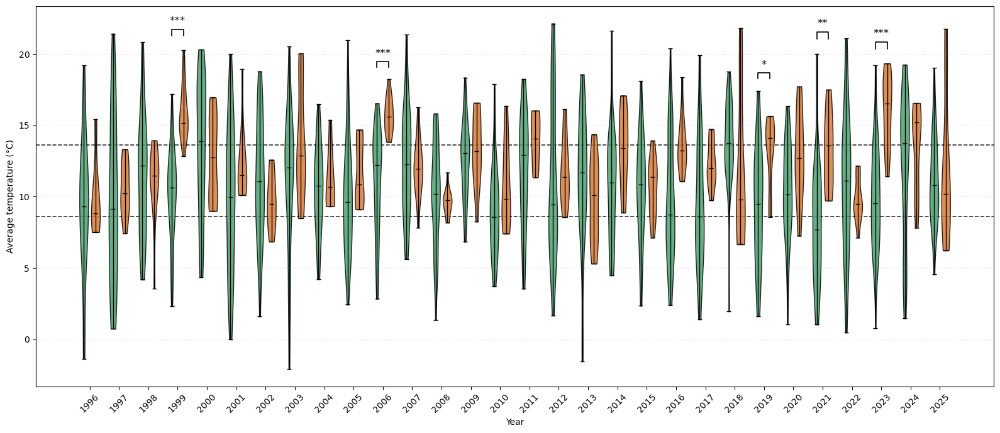

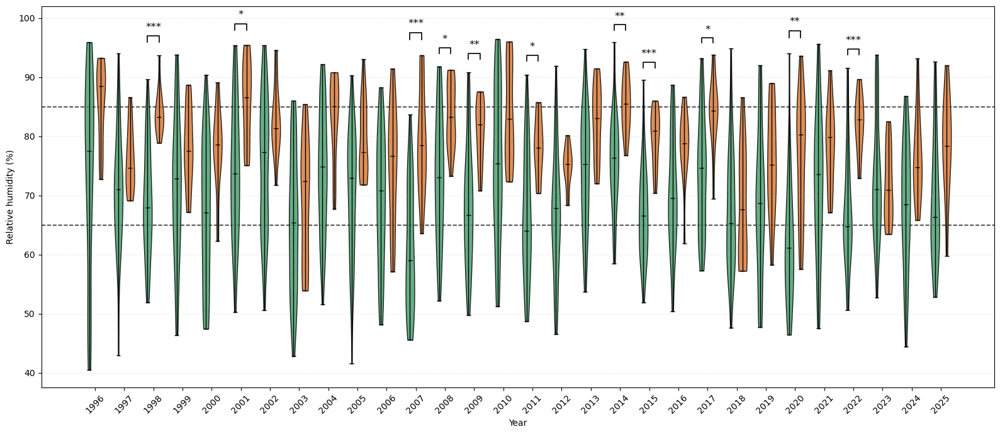

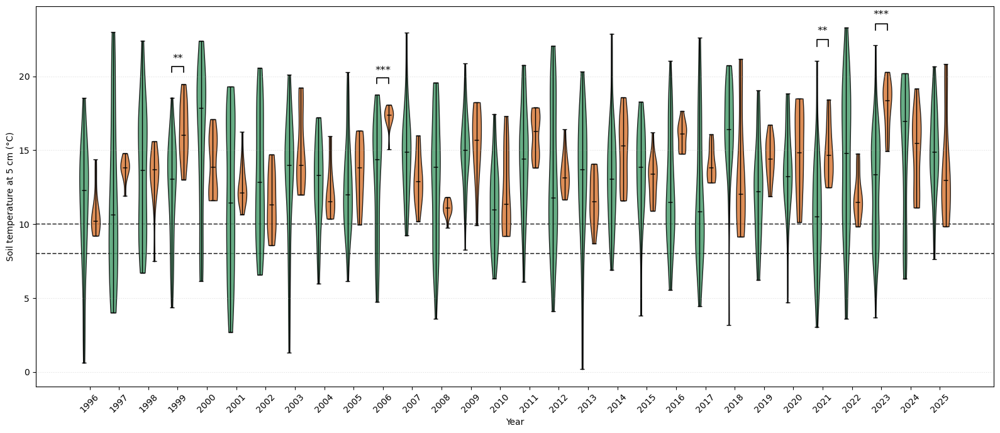

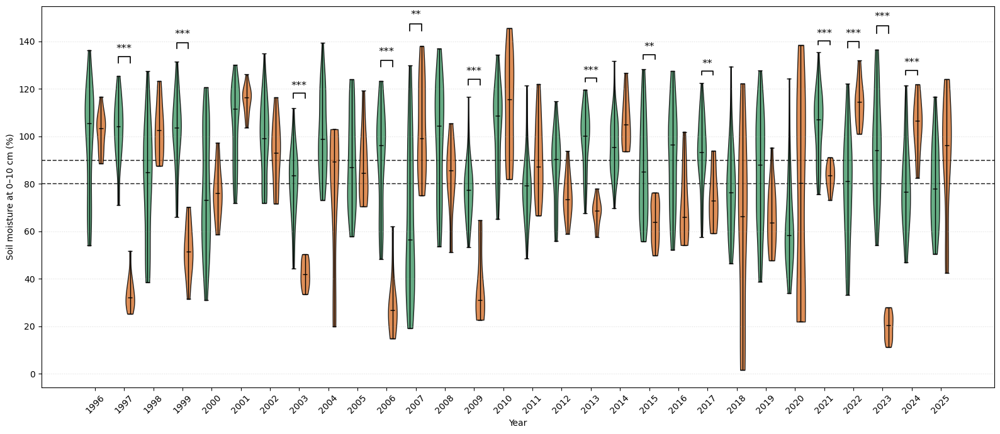

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# COLORES
# ============================================================

# Primer periodo
color_p1 = "#4C9F70"

# Segundo periodo: tono otoñal
color_p2 = "#D97A3A"

# ============================================================
# Días seleccionados
# ============================================================

days_first_semester = {
    entry["day"]
    for entry in consecutive_euclidean
    if entry["emergence_probability"] > 0.7**13
    and entry["day"] <= 182
}

days_second_semester = {
    entry["day"]
    for entry in consecutive_euclidean
    if entry["emergence_probability"] > 0.7**13
    and entry["day"] > 182
}

print(days_first_semester)

print(days_second_semester)

# ============================================================
# Preparar datos
# ============================================================

df_plot = df[
    df["DOY"].isin(
        days_first_semester | days_second_semester
    )
].copy()

df_plot["Period"] = np.where(
    df_plot["DOY"].isin(days_first_semester),
    "P1",
    "P2"
)


# ============================================================
# Función para obtener asteriscos
# ============================================================

def significance_stars(p):

    if pd.isna(p):
        return ""

    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""


# ============================================================
# Variables
# ============================================================

variables = [
    "average_temp_c",
    "relative_humidity_%",
    "soil_temp_5cm_c",
    "soil_moisture_0-10cm_%"
]


# ============================================================
# Etiquetas de variables
# ============================================================

variable_labels = {
    "average_temp_c":
        "Average temperature (°C)",

    "relative_humidity_%":
        "Relative humidity (%)",

    "soil_temp_5cm_c":
        "Soil temperature at 5 cm (°C)",

    "soil_moisture_0-10cm_%":
        "Soil moisture at 0–10 cm (%)"
}


figure_names = {
    "average_temp_c": "[Saxony][Euclidean][Raw]average_temperature",
    "relative_humidity_%": "[Saxony][Euclidean][Raw]relative_humidity",
    "soil_temp_5cm_c": "[Saxony][Euclidean][Raw]soil_temperature_5cm",
    "soil_moisture_0-10cm_%": "[Saxony][Euclidean][Raw]soil_moisture_0-10cm"
}

# ============================================================
# Límites de referencia
# ============================================================

reference_lines = {
    "average_temp_c": [
        11.10 - 2.5116,
        11.10 + 2.5116
    ],

    "relative_humidity_%": [
        65,
        85
    ],

    "soil_temp_5cm_c": [
        8,
        10
    ],

    "soil_moisture_0-10cm_%": [
        80,
        90
    ]
}

# ============================================================
# Gráficos
# ============================================================

for variable in variables:

    years = sorted(
        df_plot["YEAR"].unique()
    )

    data_p1 = []
    data_p2 = []

    valid_years = []

    # --------------------------------------------------------
    # Obtener los datos año por año
    # --------------------------------------------------------

    for year in years:

        data_year = df_plot[
            df_plot["YEAR"] == year
        ]

        p1 = data_year.loc[
            data_year["Period"] == "P1",
            variable
        ].dropna().values

        p2 = data_year.loc[
            data_year["Period"] == "P2",
            variable
        ].dropna().values

        if len(p1) > 0 and len(p2) > 0:

            data_p1.append(p1)
            data_p2.append(p2)
            valid_years.append(year)


    # --------------------------------------------------------
    # Crear figura
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(16, 7)
    )


    # --------------------------------------------------------
    # Posiciones
    # --------------------------------------------------------

    x = np.arange(
        len(valid_years)
    )

    offset = 0.20

    positions_p1 = x - offset
    positions_p2 = x + offset


       # --------------------------------------------------------
    # Violin plot primer semestre
    # --------------------------------------------------------

    vp1 = ax.violinplot(
        data_p1,
        positions=positions_p1,
        widths=0.30,
        showmeans=False,
        showmedians=True,
        showextrema=True
    )

    for body in vp1["bodies"]:
        body.set_facecolor(color_p1)
        body.set_edgecolor("black")
        body.set_linewidth(1.0)
        body.set_alpha(0.85)

    for key in ["cmedians", "cmins", "cmaxes", "cbars"]:
        if key in vp1:
            vp1[key].set_color("black")
            vp1[key].set_linewidth(1.0)


    # --------------------------------------------------------
    # Violin plot segundo semestre
    # --------------------------------------------------------

    vp2 = ax.violinplot(
        data_p2,
        positions=positions_p2,
        widths=0.30,
        showmeans=False,
        showmedians=True,
        showextrema=True
    )

    for body in vp2["bodies"]:
        body.set_facecolor(color_p2)
        body.set_edgecolor("black")
        body.set_linewidth(1.0)
        body.set_alpha(0.85)

    for key in ["cmedians", "cmins", "cmaxes", "cbars"]:
        if key in vp2:
            vp2[key].set_color("black")
            vp2[key].set_linewidth(1.0)
    # ========================================================
    # Líneas horizontales de referencia
    # ========================================================

    for reference_value in reference_lines[variable]:

        ax.axhline(
            y=reference_value,
            color="black",
            linestyle="--",
            linewidth=1.2,
            alpha=0.8,
            zorder=0
        )
            
            
    # ========================================================
    # Significancia estadística
    # ========================================================

    for i, year in enumerate(valid_years):

        result = mannwhitney_results_df[
            (mannwhitney_results_df["Variable"] == variable)
            &
            (mannwhitney_results_df["YEAR"] == year)
        ]

        if result.empty:
            continue

        p_corrected = result["p_Bonferroni"].iloc[0]

        stars = significance_stars(
            p_corrected
        )

        if stars == "":
            continue


        # ----------------------------------------------------
        # Altura de la línea
        # ----------------------------------------------------

        ymax = max(
            np.max(data_p1[i]),
            np.max(data_p2[i])
        )

        ymin = min(
            np.min(data_p1[i]),
            np.min(data_p2[i])
        )

        data_range = ymax - ymin

        if data_range == 0:
            data_range = 1


        line_y = (
            ymax
            + 0.08 * data_range
        )

        tick_y = (
            line_y
            - 0.025 * data_range
        )


        # ----------------------------------------------------
        # Línea de significancia
        # ----------------------------------------------------

        ax.plot(
            [
                positions_p1[i],
                positions_p1[i],
                positions_p2[i],
                positions_p2[i]
            ],
            [
                tick_y,
                line_y,
                line_y,
                tick_y
            ],
            linewidth=1.2,
            color="black"
        )


        # ----------------------------------------------------
        # Asteriscos
        # ----------------------------------------------------

        ax.text(
            x[i],
            line_y
            + 0.015 * data_range,
            stars,
            ha="center",
            va="bottom",
            fontsize=12
        )


    # ========================================================
    # Eje X
    # ========================================================

    ax.set_xticks(x)

    ax.set_xticklabels(
        valid_years,
        rotation=45
    )


    # ========================================================
    # Etiquetas
    # ========================================================

    ax.set_xlabel(
        "Year"
    )

    ax.set_ylabel(
        variable_labels[variable]
    )

    



    # ========================================================
    # Grid
    # ========================================================

    ax.grid(
        axis="y",
        linestyle=":",
        alpha=0.4
    )


    plt.tight_layout()

    fig.savefig(
        f"{figure_names[variable]}.png",
        dpi=600,
        transparent=True,
        bbox_inches="tight"
    )


    plt.show()

## Aggregated comparison



PRUEBAS DE NORMALIDAD — SHAPIRO-WILK


,Variable,n_P1,n_P2,Shapiro_P1_W,Shapiro_P1_p,P1_Normality,Shapiro_P2_W,Shapiro_P2_p,P2_Normality
0,average_temp_c,1410,420,0.997552,3.032056e-02,Not normal,0.985997,0.000446,Not normal
1,relative_humidity_%,1410,420,0.992361,1.102702e-06,Not normal,0.979514,0.000012,Not normal
2,soil_temp_5cm_c,1410,420,0.993984,1.781916e-05,Not normal,0.986053,0.000462,Not normal
3,soil_moisture_0-10cm_%,1410,420,0.988419,3.777209e-09,Not normal,0.974508,0.000001,Not normal




PRUEBA U DE MANN-WHITNEY


,Variable,n_P1,n_P2,Mean_P1,Mean_P2,SD_P1,SD_P2,Median_P1,Median_P2,Median_difference_P2_minus_P1,U,p_value,p_Bonferroni,Significant
0,average_temp_c,1410,420,10.783376,12.265800,4.309826,3.130484,10.804045,11.933756,1.129712,236820.0,4.484617e-10,1.793847e-09,True
1,relative_humidity_%,1410,420,70.060576,79.216564,11.356520,8.270312,69.999532,79.739206,9.739674,154151.0,2.014311e-50,8.057244e-50,True
2,soil_temp_5cm_c,1410,420,13.235762,13.927676,4.165761,2.638220,13.587282,13.711449,0.124168,270978.5,8.224594e-03,3.289838e-02,True
3,soil_moisture_0-10cm_%,1410,420,88.768369,76.840791,22.127937,30.773664,90.213388,79.124277,-11.089111,359343.0,2.870659e-11,1.148264e-10,True


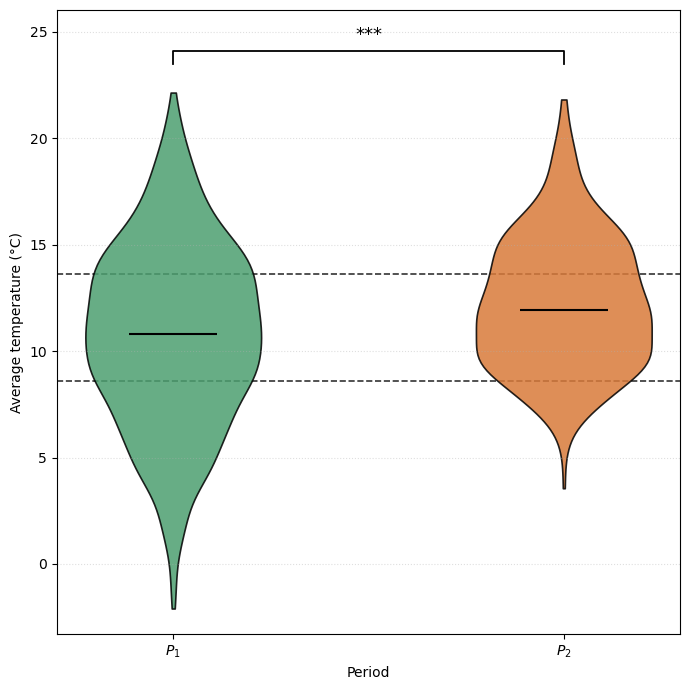

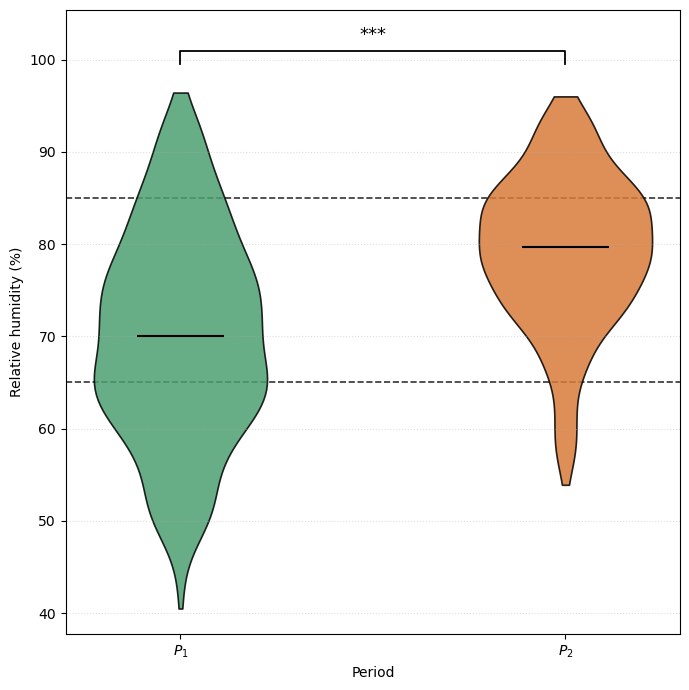

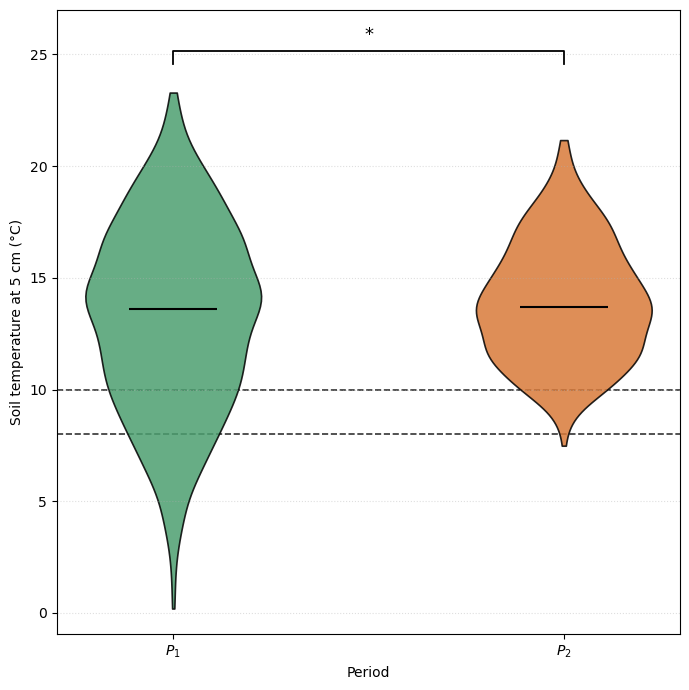

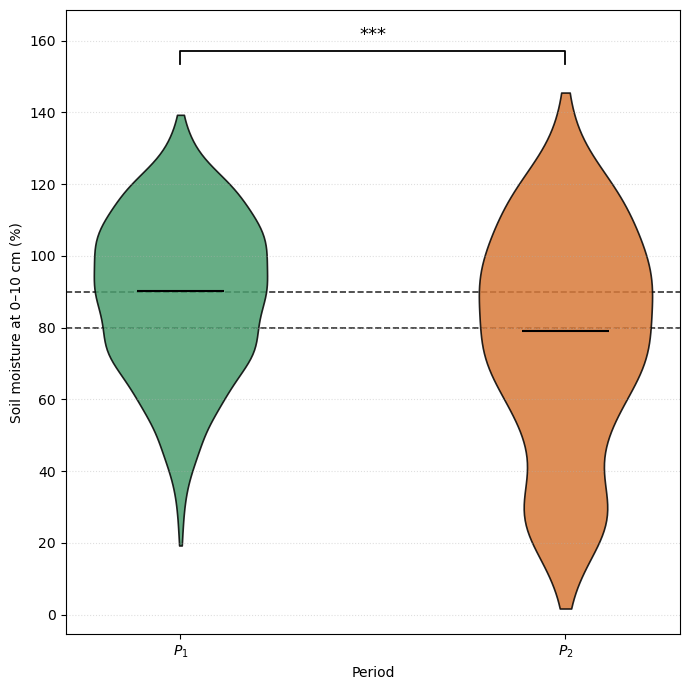

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import shapiro, mannwhitneyu
from statsmodels.stats.multitest import multipletests


# ============================================================
# Colores
# ============================================================

color_p1 = "#4C9F70"
color_p2 = "#D97A3A"


# ============================================================
# Variables
# ============================================================

variables = [
    "average_temp_c",
    "relative_humidity_%",
    "soil_temp_5cm_c",
    "soil_moisture_0-10cm_%"
]


# ============================================================
# Etiquetas
# ============================================================

variable_labels = {
    "average_temp_c":
        "Average temperature (°C)",

    "relative_humidity_%":
        "Relative humidity (%)",

    "soil_temp_5cm_c":
        "Soil temperature at 5 cm (°C)",

    "soil_moisture_0-10cm_%":
        "Soil moisture at 0–10 cm (%)"
}

figure_names = {
    "average_temp_c": "[Saxony][Euclidean][Raw]Aggregated_average_temperature",
    "relative_humidity_%": "[Saxony][Euclidean][Raw]Aggregated_relative_humidity",
    "soil_temp_5cm_c": "[Saxony][Euclidean][Raw]Aggregated_soil_temperature_5cm",
    "soil_moisture_0-10cm_%": "[Saxony][Euclidean][Raw]Aggregated_soil_moisture_0-10cm"
}


# ============================================================
# Función para obtener asteriscos
# ============================================================

def significance_stars(p):

    if pd.isna(p):
        return ""

    if p < 0.001:
        return "***"

    elif p < 0.01:
        return "**"

    elif p < 0.05:
        return "*"

    else:
        return ""

# ============================================================
# ============================================================
# 1. PRUEBAS DE NORMALIDAD
# ============================================================
# ============================================================

normality_results = []


for variable in variables:

    # --------------------------------------------------------
    # Datos P1
    # --------------------------------------------------------

    p1 = (
        df_plot.loc[
            df_plot["Period"] == "P1",
            variable
        ]
        .dropna()
        .values
    )


    # --------------------------------------------------------
    # Datos P2
    # --------------------------------------------------------

    p2 = (
        df_plot.loc[
            df_plot["Period"] == "P2",
            variable
        ]
        .dropna()
        .values
    )


    # --------------------------------------------------------
    # Shapiro-Wilk P1
    # --------------------------------------------------------

    if 3 <= len(p1) <= 5000:

        shapiro_p1_stat, shapiro_p1_p = shapiro(p1)

        # Interpretación explícita
        if shapiro_p1_p >= 0.05:
            normality_p1 = "Normal"
        else:
            normality_p1 = "Not normal"

    else:

        shapiro_p1_stat = np.nan
        shapiro_p1_p = np.nan
        normality_p1 = "Not enough data"


    # --------------------------------------------------------
    # Shapiro-Wilk P2
    # --------------------------------------------------------

    if 3 <= len(p2) <= 5000:

        shapiro_p2_stat, shapiro_p2_p = shapiro(p2)

        # Interpretación explícita
        if shapiro_p2_p >= 0.05:
            normality_p2 = "Normal"
        else:
            normality_p2 = "Not normal"

    else:

        shapiro_p2_stat = np.nan
        shapiro_p2_p = np.nan
        normality_p2 = "Not enough data"


    # --------------------------------------------------------
    # Guardar resultados
    # --------------------------------------------------------

    normality_results.append({

        "Variable": variable,

        "n_P1": len(p1),
        "n_P2": len(p2),

        "Shapiro_P1_W": shapiro_p1_stat,
        "Shapiro_P1_p": shapiro_p1_p,
        "P1_Normality": normality_p1,

        "Shapiro_P2_W": shapiro_p2_stat,
        "Shapiro_P2_p": shapiro_p2_p,
        "P2_Normality": normality_p2
    })


# ============================================================
# DataFrame de normalidad
# ============================================================

normality_results_df = pd.DataFrame(
    normality_results
)


# ============================================================
# MOSTRAR TABLA DE NORMALIDAD
# ============================================================

print("\n")
print("=" * 80)
print("PRUEBAS DE NORMALIDAD — SHAPIRO-WILK")
print("=" * 80)

display(
    normality_results_df[
        [
            "Variable",
            "n_P1",
            "n_P2",

            "Shapiro_P1_W",
            "Shapiro_P1_p",
            "P1_Normality",

            "Shapiro_P2_W",
            "Shapiro_P2_p",
            "P2_Normality"
        ]
    ]
)


# ============================================================
# ============================================================
# 2. MANN-WHITNEY U
# ============================================================
# ============================================================

u_results = []


for variable in variables:

    # --------------------------------------------------------
    # Datos P1
    # --------------------------------------------------------

    p1 = (
        df_plot.loc[
            df_plot["Period"] == "P1",
            variable
        ]
        .dropna()
        .values
    )


    # --------------------------------------------------------
    # Datos P2
    # --------------------------------------------------------

    p2 = (
        df_plot.loc[
            df_plot["Period"] == "P2",
            variable
        ]
        .dropna()
        .values
    )


    # --------------------------------------------------------
    # Mann-Whitney U
    # --------------------------------------------------------

    U, p_value = mannwhitneyu(
        p1,
        p2,
        alternative="two-sided",
        method="auto"
    )


    # --------------------------------------------------------
    # Medianas
    # --------------------------------------------------------

    median_p1 = np.median(p1)
    median_p2 = np.median(p2)
    
    mean_p1 = np.mean(p1)
    mean_p2 = np.mean(p2)
    
    sd_p1 = np.std(p1)
    sd_p2 = np.std(p2)


    # --------------------------------------------------------
    # Diferencia de medianas
    # --------------------------------------------------------

    median_difference = (
        median_p2 - median_p1
    )


    u_results.append({

        "Variable": variable,

        "n_P1": len(p1),
        "n_P2": len(p2),
        
        "Mean_P1":mean_p1,
        "Mean_P2":mean_p2,
        
        "SD_P1":sd_p1,
        "SD_P2":sd_p2,

        "Median_P1": median_p1,
        "Median_P2": median_p2,

        "Median_difference_P2_minus_P1":
            median_difference,

        "U": U,

        "p_value": p_value
    })


# ============================================================
# DataFrame Mann-Whitney
# ============================================================

u_results_df = pd.DataFrame(
    u_results
)


# ============================================================
# Corrección Bonferroni
# ============================================================

reject, p_adjusted, _, _ = multipletests(
    u_results_df["p_value"],
    alpha=0.05,
    method="bonferroni"
)


u_results_df["p_Bonferroni"] = p_adjusted

u_results_df["Significant"] = reject


# ============================================================
# MOSTRAR TABLA DE MANN-WHITNEY
# ============================================================

print("\n")
print("=" * 80)
print("PRUEBA U DE MANN-WHITNEY")
print("=" * 80)

display(
    u_results_df[
        [
            "Variable",
            "n_P1",
            "n_P2",
            
            "Mean_P1",
            "Mean_P2",

            "SD_P1",
            "SD_P2",

            "Median_P1",
            "Median_P2",

            "Median_difference_P2_minus_P1",

            "U",

            "p_value",
            "p_Bonferroni",
            "Significant"
        ]
    ]
)


# ============================================================
# ============================================================
# 3. VIOLINES
# ============================================================
# ============================================================

for variable in variables:

    # --------------------------------------------------------
    # Datos P1
    # --------------------------------------------------------

    p1 = (
        df_plot.loc[
            df_plot["Period"] == "P1",
            variable
        ]
        .dropna()
        .values
    )


    # --------------------------------------------------------
    # Datos P2
    # --------------------------------------------------------

    p2 = (
        df_plot.loc[
            df_plot["Period"] == "P2",
            variable
        ]
        .dropna()
        .values
    )


    # --------------------------------------------------------
    # Figura
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(7, 7)
    )


    # ========================================================
    # Violin P1
    # ========================================================

    vp1 = ax.violinplot(
        p1,
        positions=[1],
        widths=0.45,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )


    # ========================================================
    # Violin P2
    # ========================================================

    vp2 = ax.violinplot(
        p2,
        positions=[2],
        widths=0.45,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )


    # ========================================================
    # Color P1
    # ========================================================

    for body in vp1["bodies"]:

        body.set_facecolor(color_p1)
        body.set_edgecolor("black")
        body.set_linewidth(1.2)
        body.set_alpha(0.85)


    # ========================================================
    # Color P2
    # ========================================================

    for body in vp2["bodies"]:

        body.set_facecolor(color_p2)
        body.set_edgecolor("black")
        body.set_linewidth(1.2)
        body.set_alpha(0.85)


    # ========================================================
    # Medianas
    # ========================================================

    vp1["cmedians"].set_color("black")
    vp1["cmedians"].set_linewidth(1.5)

    vp2["cmedians"].set_color("black")
    vp2["cmedians"].set_linewidth(1.5)


    # ========================================================
    # Líneas horizontales de referencia
    # ========================================================

    for reference_value in reference_lines[variable]:

        ax.axhline(
            y=reference_value,
            color="black",
            linestyle="--",
            linewidth=1.2,
            alpha=0.8,
            zorder=0
        )


    # ========================================================
    # Resultado Mann-Whitney
    # ========================================================

    result = u_results_df[
        u_results_df["Variable"] == variable
    ]


    if not result.empty:

        # ----------------------------------------------------
        # IMPORTANTE:
        # utilizar p corregido por Bonferroni
        # ----------------------------------------------------

        p_value = result[
            "p_Bonferroni"
        ].iloc[0]


        stars = significance_stars(
            p_value
        )


        # ----------------------------------------------------
        # Dibujar solamente si es significativo
        # ----------------------------------------------------

        if stars != "":

            ymax = max(
                np.max(p1),
                np.max(p2)
            )

            ymin = min(
                np.min(p1),
                np.min(p2)
            )

            data_range = (
                ymax - ymin
            )


            if data_range == 0:
                data_range = 1


            # ------------------------------------------------
            # Altura de la barra
            # ------------------------------------------------

            line_y = (
                ymax
                + 0.08 * data_range
            )

            tick_y = (
                line_y
                - 0.025 * data_range
            )


            # ------------------------------------------------
            # Barra de significancia
            # ------------------------------------------------

            ax.plot(
                [1, 1, 2, 2],
                [
                    tick_y,
                    line_y,
                    line_y,
                    tick_y
                ],
                linewidth=1.3,
                color="black"
            )


            # ------------------------------------------------
            # Asteriscos
            # ------------------------------------------------

            ax.text(
                1.5,
                line_y + 0.015 * data_range,
                stars,
                ha="center",
                va="bottom",
                fontsize=13
            )


            # ------------------------------------------------
            # Ampliar límite superior
            # ------------------------------------------------

            ax.set_ylim(
                ymin - 0.05 * data_range,
                line_y + 0.08 * data_range
            )


    # ========================================================
    # Formato
    # ========================================================

    ax.set_xticks([
        1,
        2
    ])

    ax.set_xticklabels([
         r"$P_1$",
         r"$P_2$"
    ])

    ax.set_xlabel(
        "Period"
    )

    ax.set_ylabel(
        variable_labels[variable]
    )


    ax.grid(
        axis="y",
        linestyle=":",
        alpha=0.4
    )


    # ========================================================
    # Ajustes
    # ========================================================

    plt.tight_layout()
    
    fig.savefig(
        f"{figure_names[variable]}.png",
        dpi=300,
        transparent=True,
        bbox_inches="tight"
    )


    plt.show()
    
    output_path = (
        r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\[Saxony][Euclidean][Raw]Aggregated_normality.xlsx"
    )

    normality_results_df.to_excel(
        output_path,
        index=False
    )

    output_path = (
        r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\[Saxony][Euclidean][Raw]Aggregated_U_test.xlsx"
    )

    u_results_df.to_excel(
        output_path,
        index=False
    )

### CI

In [72]:
import pandas as pd
import numpy as np

from scipy.stats import mannwhitneyu
from scipy.stats import shapiro

from statsmodels.stats.multitest import multipletests


# ============================================================
# Cargar datos
# ============================================================

file_path = (
    r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\Saxony.xlsx"
)

variables = [
    "average_temp_c",
    "relative_humidity_%",
    "soil_temp_5cm_c",
    "soil_moisture_0-10cm_%"
]

df = pd.read_excel(file_path)

df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True
)

df["YEAR"] = df["Date"].dt.year


# ============================================================
# Días seleccionados por el modelo
# ============================================================


days_first_semester_CI = {
    entry["day"]
    for entry in consecutive_euclidean
    if (
        entry["ci_prob_bootstrap"][0] <= threshold <= entry["ci_prob_bootstrap"][1]
        or
        threshold <= entry["ci_prob_bootstrap"][0]
        or
        entry["ci_lengths_jack"][0] <= threshold <= entry["ci_lengths_jack"][1]
        or
        threshold <= entry["ci_lengths_jack"][0]
    )
    and entry["day"] <= 182
}

days_second_semester_CI = {
    entry["day"]
    for entry in consecutive_euclidean
    if (
        entry["ci_prob_bootstrap"][0] <= threshold <= entry["ci_prob_bootstrap"][1]
        or
        threshold <= entry["ci_prob_bootstrap"][0]
        or
        entry["ci_lengths_jack"][0] <= threshold <= entry["ci_lengths_jack"][1]
        or
        threshold <= entry["ci_lengths_jack"][0]
    )
    and entry["day"] > 182
}


# ============================================================
# Seleccionar datos
# ============================================================

df_analysis = df[
    df["DOY"].isin(
        days_first_semester_CI | days_second_semester_CI
    )
].copy()

df_analysis["Period"] = np.where(
    df_analysis["DOY"].isin(days_first_semester_CI),
    "P1",
    "P2"
)


# ============================================================
# Pruebas de normalidad Shapiro-Wilk
# ============================================================

normality_results = []


for variable in variables:

    for year in sorted(
        df_analysis["YEAR"].unique()
    ):

        data_year = df_analysis[
            df_analysis["YEAR"] == year
        ]

        p1_CI = data_year.loc[
            data_year["Period"] == "P1",
            variable
        ].dropna()

        p2_CI = data_year.loc[
            data_year["Period"] == "P2",
            variable
        ].dropna()


        # ----------------------------------------------------
        # P1
        # ----------------------------------------------------

        if 3 <= len(p1_CI) <= 5000:

            shapiro_p1_stat, shapiro_p1_p = shapiro(p1_CI)

            if shapiro_p1_p >= 0.05:
                normality_p1 = "Normal"
            else:
                normality_p1 = "Not normal"

        else:

            shapiro_p1_stat = np.nan
            shapiro_p1_p = np.nan
            normality_p1 = "Not enough data"


        # ----------------------------------------------------
        # P2
        # ----------------------------------------------------

        if 3 <= len(p2_CI) <= 5000:

            shapiro_p2_stat, shapiro_p2_p = shapiro(p2_CI)

            if shapiro_p2_p >= 0.05:
                normality_p2 = "Normal"
            else:
                normality_p2 = "Not normal"

        else:

            shapiro_p2_stat = np.nan
            shapiro_p2_p = np.nan
            normality_p2 = "Not enough data"


        # ----------------------------------------------------
        # Guardar resultados
        # ----------------------------------------------------

        normality_results.append({

            "Variable": variable,
            "YEAR": year,

            "n_P1": len(p1_CI),
            "n_P2": len(p2_CI),

            "Shapiro_P1_W": shapiro_p1_stat,
            "Shapiro_P1_p": shapiro_p1_p,
            "P1_Normality": normality_p1,

            "Shapiro_P2_W": shapiro_p2_stat,
            "Shapiro_P2_p": shapiro_p2_p,
            "P2_Normality": normality_p2
        })


# ============================================================
# Tabla de normalidad
# ============================================================

normality_results_df = pd.DataFrame(
    normality_results
)


# ============================================================
# Ordenar resultados
# ============================================================

normality_results_df = (
    normality_results_df
    .sort_values(
        ["Variable", "YEAR"]
    )
    .reset_index(drop=True)
)


# ============================================================
# Mostrar resultados
# ============================================================

print("\n")
print("=" * 90)
print("PRUEBAS DE NORMALIDAD — SHAPIRO-WILK")
print("=" * 90)

display(
    normality_results_df[
        [
            "Variable",
            "YEAR",
            "n_P1",
            "n_P2",

            "Shapiro_P1_W",
            "Shapiro_P1_p",
            "P1_Normality",

            "Shapiro_P2_W",
            "Shapiro_P2_p",
            "P2_Normality"
        ]
    ]
)


# ============================================================
# Prueba U de Mann-Whitney
# ============================================================

mannwhitney_results = []


for variable in variables:

    for year in sorted(
        df_analysis["YEAR"].unique()
    ):

        data_year = df_analysis[
            df_analysis["YEAR"] == year
        ]

        p1 = data_year.loc[
            data_year["Period"] == "P1",
            variable
        ].dropna()

        p2 = data_year.loc[
            data_year["Period"] == "P2",
            variable
        ].dropna()


        if len(p1) > 0 and len(p2) > 0:

            U_statistic, p_value = mannwhitneyu(
                p1,
                p2,
                alternative="two-sided",
                method="auto"
            )

            mannwhitney_results.append({

                "Variable": variable,
                "YEAR": year,
                
                "mean_P1": np.mean(p1),
                
                "sd_P1": np.std(p1),

                "n_P1": len(p1),
                
                "mean_P2": np.mean(p2),
                
                "sd_P2": np.std(p2),
                
                "n_P2": len(p2),

                "U_statistic": U_statistic,
                "p_value": p_value
            })


# ============================================================
# Tabla de resultados Mann-Whitney
# ============================================================

mannwhitney_results_df = pd.DataFrame(
    mannwhitney_results
)


# ============================================================
# Corrección Bonferroni por variable
# ============================================================

mannwhitney_results_df["p_Bonferroni"] = np.nan
mannwhitney_results_df["Significant"] = False


for variable in variables:

    mask = (
        mannwhitney_results_df["Variable"]
        == variable
    )

    p_values = mannwhitney_results_df.loc[
        mask,
        "p_value"
    ]


    reject, p_adjusted, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="bonferroni"
    )


    mannwhitney_results_df.loc[
        mask,
        "p_Bonferroni"
    ] = p_adjusted


    mannwhitney_results_df.loc[
        mask,
        "Significant"
    ] = reject


# ============================================================
# Ordenar resultados
# ============================================================

mannwhitney_results_df = (
    mannwhitney_results_df
    .sort_values(
        ["Variable", "YEAR"]
    )
    .reset_index(drop=True)
)


# ============================================================
# Mostrar resultados Mann-Whitney
# ============================================================

print(
    mannwhitney_results_df[
        [
            "Variable",
            "YEAR",
            "n_P1",
            "n_P2",
            "U_statistic",
            "p_value",
            "p_Bonferroni",
            "Significant"
        ]
    ]
)

output_path = (
    r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\[Saxony][Euclidean][CI]Yearly_normality.xlsx"
)

normality_results_df.to_excel(
    output_path,
    index=False
)

output_path = (
    r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\[Saxony][Euclidean][CI]Yearly_U_test.xlsx"
)

mannwhitney_results_df.to_excel(
    output_path,
    index=False
)



PRUEBAS DE NORMALIDAD — SHAPIRO-WILK


,Variable,YEAR,n_P1,n_P2,Shapiro_P1_W,Shapiro_P1_p,P1_Normality,Shapiro_P2_W,Shapiro_P2_p,P2_Normality
0,average_temp_c,1996,58,14,0.972448,0.208815,Normal,0.796863,0.004566,Not normal
1,average_temp_c,1997,58,14,0.956056,0.034772,Not normal,0.945712,0.496323,Normal
2,average_temp_c,1998,58,14,0.974905,0.271067,Normal,0.817095,0.008185,Not normal
3,average_temp_c,1999,58,14,0.978822,0.403408,Normal,0.907445,0.144675,Normal
4,average_temp_c,2000,58,14,0.943198,0.008967,Not normal,0.863492,0.034035,Not normal
...,...,...,...,...,...,...,...,...,...,...
115,soil_temp_5cm_c,2021,58,14,0.982169,0.549966,Normal,0.910802,0.161871,Normal
116,soil_temp_5cm_c,2022,58,14,0.953166,0.025478,Not normal,0.911931,0.168093,Normal
117,soil_temp_5cm_c,2023,58,14,0.970884,0.176353,Normal,0.910104,0.158133,Normal
118,soil_temp_5cm_c,2024,58,14,0.880395,0.000036,Not normal,0.903954,0.128729,Normal


            Variable  YEAR  n_P1  n_P2  U_statistic   p_value  p_Bonferroni  \
0     average_temp_c  1996    58    14        392.0  0.847679      1.000000   
1     average_temp_c  1997    58    14        311.0  0.178765      1.000000   
2     average_temp_c  1998    58    14        410.0  0.960283      1.000000   
3     average_temp_c  1999    58    14         71.0  0.000002      0.000058   
4     average_temp_c  2000    58    14        438.0  0.654016      1.000000   
..               ...   ...   ...   ...          ...       ...           ...   
115  soil_temp_5cm_c  2021    58    14        134.0  0.000112      0.003361   
116  soil_temp_5cm_c  2022    58    14        489.0  0.240463      1.000000   
117  soil_temp_5cm_c  2023    58    14        105.0  0.000019      0.000572   
118  soil_temp_5cm_c  2024    58    14        489.0  0.240463      1.000000   
119  soil_temp_5cm_c  2025    58    14        489.0  0.240463      1.000000   

     Significant  
0          False  
1          Fa

Días P1 con CI: {128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 146, 149, 150, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127}
Días P2 con CI: {262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275}


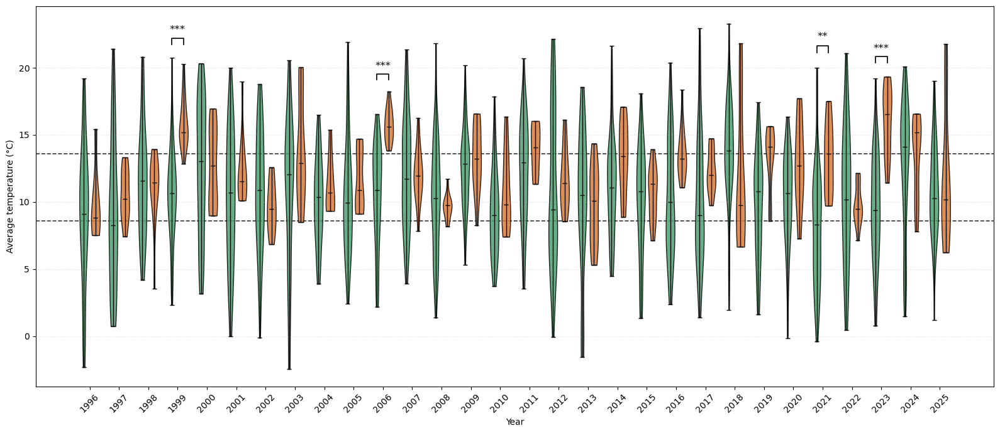

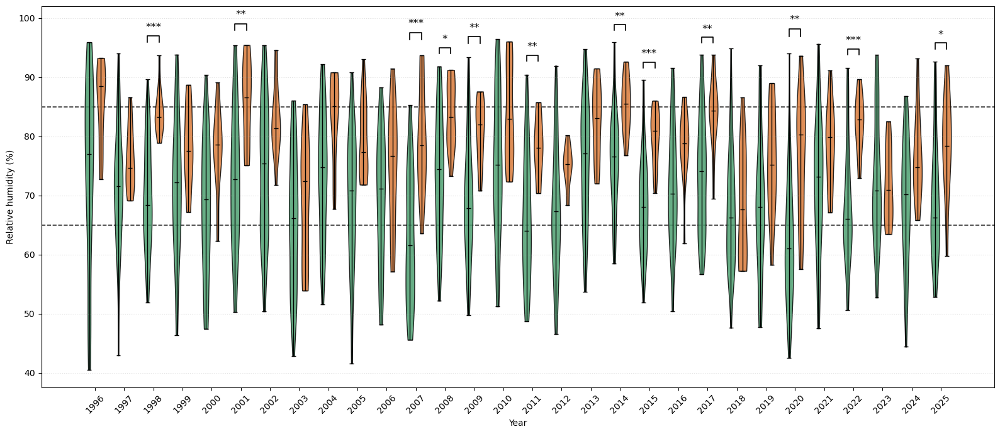

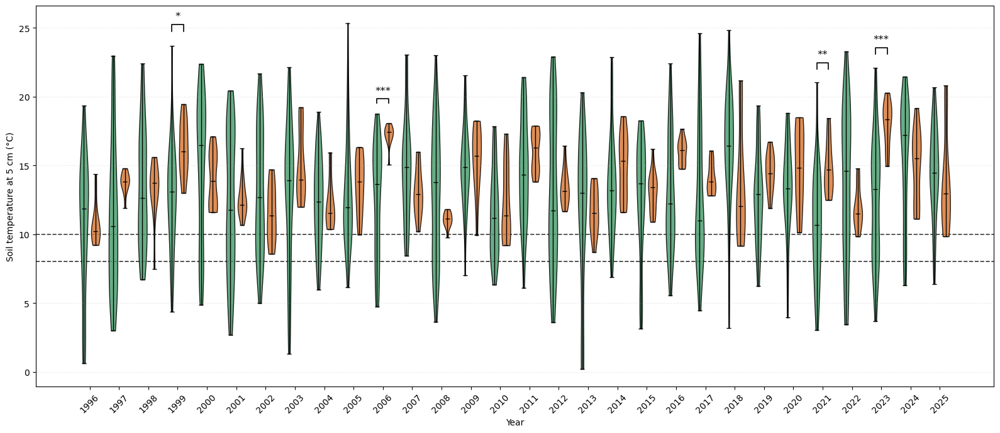

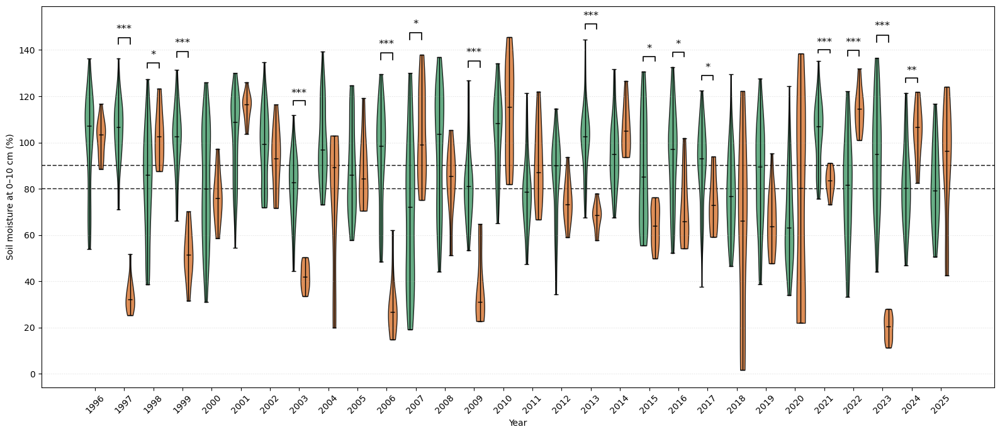

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# COLORES
# ============================================================

# Primer periodo
color_p1 = "#4C9F70"

# Segundo periodo: tono otoñal
color_p2 = "#D97A3A"


# ============================================================
# Días seleccionados mediante intervalos de confianza
# ============================================================

threshold = 0.7**13


# ------------------------------------------------------------
# Primer periodo
# ------------------------------------------------------------

days_first_semester_CI = {
    entry["day"]
    for entry in consecutive_euclidean
    if (
        entry["ci_prob_bootstrap"][0] <= threshold <= entry["ci_prob_bootstrap"][1]
        or
        threshold <= entry["ci_prob_bootstrap"][0]
        or
        entry["ci_lengths_jack"][0] <= threshold <= entry["ci_lengths_jack"][1]
        or
        threshold <= entry["ci_lengths_jack"][0]
    )
    and entry["day"] <= 182
}


print(
    "Días P1 con CI:",
    days_first_semester_CI
)


# ------------------------------------------------------------
# Segundo periodo
# ------------------------------------------------------------

days_second_semester_CI = {
    entry["day"]
    for entry in consecutive_euclidean
    if (
        entry["ci_prob_bootstrap"][0] <= threshold <= entry["ci_prob_bootstrap"][1]
        or
        threshold <= entry["ci_prob_bootstrap"][0]
        or
        entry["ci_lengths_jack"][0] <= threshold <= entry["ci_lengths_jack"][1]
        or
        threshold <= entry["ci_lengths_jack"][0]
    )
    and entry["day"] > 182
}


print(
    "Días P2 con CI:",
    days_second_semester_CI
)


# ============================================================
# Preparar datos
# ============================================================

df_plot_CI = df[
    df["DOY"].isin(
        days_first_semester_CI | days_second_semester_CI
    )
].copy()


# ------------------------------------------------------------
# Asignar periodo
# ------------------------------------------------------------

df_plot_CI["Period"] = np.where(
    df_plot_CI["DOY"].isin(days_first_semester_CI),
    "P1",
    "P2"
)


# ============================================================
# Función para obtener asteriscos de significancia
# ============================================================

def significance_stars(p):

    if pd.isna(p):
        return ""

    if p < 0.001:
        return "***"

    elif p < 0.01:
        return "**"

    elif p < 0.05:
        return "*"

    else:
        return ""


# ============================================================
# Variables
# ============================================================

variables = [
    "average_temp_c",
    "relative_humidity_%",
    "soil_temp_5cm_c",
    "soil_moisture_0-10cm_%"
]


# ============================================================
# Etiquetas de variables
# ============================================================

variable_labels = {

    "average_temp_c":
        "Average temperature (°C)",

    "relative_humidity_%":
        "Relative humidity (%)",

    "soil_temp_5cm_c":
        "Soil temperature at 5 cm (°C)",

    "soil_moisture_0-10cm_%":
        "Soil moisture at 0–10 cm (%)"
}


figure_names = {
    "average_temp_c": "[Saxony][Euclidean][CI]average_temperature",
    "relative_humidity_%": "[Saxony][Euclidean][CI]relative_humidity",
    "soil_temp_5cm_c": "[Saxony][Euclidean][CI]soil_temperature_5cm",
    "soil_moisture_0-10cm_%": "[Saxony][Euclidean][CI]soil_moisture_0-10cm"
}

# ============================================================
# Límites de referencia
# ============================================================

reference_lines = {

    "average_temp_c": [
        11.10 - 2.5116,
        11.10 + 2.5116
    ],

    "relative_humidity_%": [
        65,
        85
    ],

    "soil_temp_5cm_c": [
        8,
        10
    ],

    "soil_moisture_0-10cm_%": [
        80,
        90
    ]
}


# ============================================================
# Gráficos
# ============================================================

for variable in variables:

    # --------------------------------------------------------
    # Años disponibles
    # --------------------------------------------------------

    years_CI = sorted(
        df_plot_CI["YEAR"].unique()
    )


    # --------------------------------------------------------
    # Contenedores de datos
    # --------------------------------------------------------

    data_p1_CI = []
    data_p2_CI = []

    valid_years_CI = []


    # ========================================================
    # Obtener los datos año por año
    # ========================================================

    for year in years_CI:

        data_year_CI = df_plot_CI[
            df_plot_CI["YEAR"] == year
        ]


        # ----------------------------------------------------
        # Datos del primer periodo
        # ----------------------------------------------------

        p1_CI = data_year_CI.loc[
            data_year_CI["Period"] == "P1",
            variable
        ].dropna().values


        # ----------------------------------------------------
        # Datos del segundo periodo
        # ----------------------------------------------------

        p2_CI = data_year_CI.loc[
            data_year_CI["Period"] == "P2",
            variable
        ].dropna().values


        # ----------------------------------------------------
        # Conservar únicamente años con ambos periodos
        # ----------------------------------------------------

        if len(p1_CI) > 0 and len(p2_CI) > 0:

            data_p1_CI.append(p1_CI)
            data_p2_CI.append(p2_CI)

            valid_years_CI.append(year)


    # ========================================================
    # Crear figura
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(16, 7)
    )


    # ========================================================
    # Posiciones
    # ========================================================

    x_CI = np.arange(
        len(valid_years_CI)
    )

    offset_CI = 0.20

    positions_p1_CI = (
        x_CI - offset_CI
    )

    positions_p2_CI = (
        x_CI + offset_CI
    )


    # ========================================================
    # Violin plot: primer periodo
    # ========================================================

    vp1_CI = ax.violinplot(
        data_p1_CI,
        positions=positions_p1_CI,
        widths=0.30,
        showmeans=False,
        showmedians=True,
        showextrema=True
    )


    for body in vp1_CI["bodies"]:

        body.set_facecolor(
            color_p1
        )

        body.set_edgecolor(
            "black"
        )

        body.set_linewidth(
            1.0
        )

        body.set_alpha(
            0.85
        )


    for key in [
        "cmedians",
        "cmins",
        "cmaxes",
        "cbars"
    ]:

        if key in vp1_CI:

            vp1_CI[key].set_color(
                "black"
            )

            vp1_CI[key].set_linewidth(
                1.0
            )


    # ========================================================
    # Violin plot: segundo periodo
    # ========================================================

    vp2_CI = ax.violinplot(
        data_p2_CI,
        positions=positions_p2_CI,
        widths=0.30,
        showmeans=False,
        showmedians=True,
        showextrema=True
    )


    for body in vp2_CI["bodies"]:

        body.set_facecolor(
            color_p2
        )

        body.set_edgecolor(
            "black"
        )

        body.set_linewidth(
            1.0
        )

        body.set_alpha(
            0.85
        )


    for key in [
        "cmedians",
        "cmins",
        "cmaxes",
        "cbars"
    ]:

        if key in vp2_CI:

            vp2_CI[key].set_color(
                "black"
            )

            vp2_CI[key].set_linewidth(
                1.0
            )


    # ========================================================
    # Líneas horizontales de referencia
    # ========================================================

    for reference_value in reference_lines[variable]:

        ax.axhline(
            y=reference_value,
            color="black",
            linestyle="--",
            linewidth=1.2,
            alpha=0.8,
            zorder=0
        )


    # ========================================================
    # Significancia estadística
    # ========================================================

    for i, year in enumerate(valid_years_CI):

        result_CI = mannwhitney_results_df[
            (mannwhitney_results_df["Variable"] == variable)
            &
            (mannwhitney_results_df["YEAR"] == year)
        ]


        if result_CI.empty:
            continue


        p_corrected_CI = (
            result_CI["p_Bonferroni"].iloc[0]
        )


        stars_CI = significance_stars(
            p_corrected_CI
        )


        if stars_CI == "":
            continue


        # ----------------------------------------------------
        # Altura de los datos
        # ----------------------------------------------------

        ymax_CI = max(
            np.max(data_p1_CI[i]),
            np.max(data_p2_CI[i])
        )


        ymin_CI = min(
            np.min(data_p1_CI[i]),
            np.min(data_p2_CI[i])
        )


        data_range_CI = (
            ymax_CI - ymin_CI
        )


        if data_range_CI == 0:

            data_range_CI = 1


        # ----------------------------------------------------
        # Altura de la línea
        # ----------------------------------------------------

        line_y_CI = (
            ymax_CI
            + 0.08 * data_range_CI
        )


        tick_y_CI = (
            line_y_CI
            - 0.025 * data_range_CI
        )


        # ----------------------------------------------------
        # Línea de significancia
        # ----------------------------------------------------

        ax.plot(
            [
                positions_p1_CI[i],
                positions_p1_CI[i],
                positions_p2_CI[i],
                positions_p2_CI[i]
            ],
            [
                tick_y_CI,
                line_y_CI,
                line_y_CI,
                tick_y_CI
            ],
            linewidth=1.2,
            color="black"
        )


        # ----------------------------------------------------
        # Asteriscos
        # ----------------------------------------------------

        ax.text(
            x_CI[i],
            line_y_CI
            + 0.015 * data_range_CI,
            stars_CI,
            ha="center",
            va="bottom",
            fontsize=12
        )


    # ========================================================
    # Eje X
    # ========================================================

    ax.set_xticks(
        x_CI
    )


    ax.set_xticklabels(
        valid_years_CI,
        rotation=45
    )


    # ========================================================
    # Etiquetas
    # ========================================================

    ax.set_xlabel(
        "Year"
    )


    ax.set_ylabel(
        variable_labels[variable]
    )




    # ========================================================
    # Grid
    # ========================================================

    ax.grid(
        axis="y",
        linestyle=":",
        alpha=0.4
    )


    # ========================================================
    # Ajuste final
    # ========================================================

    plt.tight_layout()

    fig.savefig(
        f"{figure_names[variable]}.png",
        dpi=300,
        bbox_inches="tight",
        transparent=True
    )
    
    plt.show()

### Agreggated CI



PRUEBAS DE NORMALIDAD — SHAPIRO-WILK


,Variable,n_P1,n_P2,Shapiro_P1_W,Shapiro_P1_p,P1_Normality,Shapiro_P2_W,Shapiro_P2_p,P2_Normality
0,average_temp_c,1740,420,0.99766,1.185077e-02,Not normal,0.985997,0.000446,Not normal
1,relative_humidity_%,1740,420,0.99312,2.990999e-07,Not normal,0.979514,0.000012,Not normal
2,soil_temp_5cm_c,1740,420,0.99577,8.472565e-05,Not normal,0.986053,0.000462,Not normal
3,soil_moisture_0-10cm_%,1740,420,0.98886,2.629406e-10,Not normal,0.974508,0.000001,Not normal




PRUEBA U DE MANN-WHITNEY


,Variable,n_P1,n_P2,n_P1,n_P2,Mean_P1,Mean_P2,Median_P1,Median_P2,Median_difference_P2_minus_P1,U,p_value,p_Bonferroni,Significant
0,average_temp_c,1740,420,1740,420,10.695947,12.265800,10.731487,11.933756,1.202269,290789.0,7.834141e-11,3.133657e-10,True
1,relative_humidity_%,1740,420,1740,420,70.253614,79.216564,70.182440,79.739206,9.556767,191727.0,8.966796e-52,3.586719e-51,True
2,soil_temp_5cm_c,1740,420,1740,420,13.130350,13.927676,13.421109,13.711449,0.290341,329371.5,1.686375e-03,6.745501e-03,True
3,soil_moisture_0-10cm_%,1740,420,1740,420,89.648060,76.840791,91.229468,79.124277,-12.105191,450198.0,1.449135e-13,5.796538e-13,True


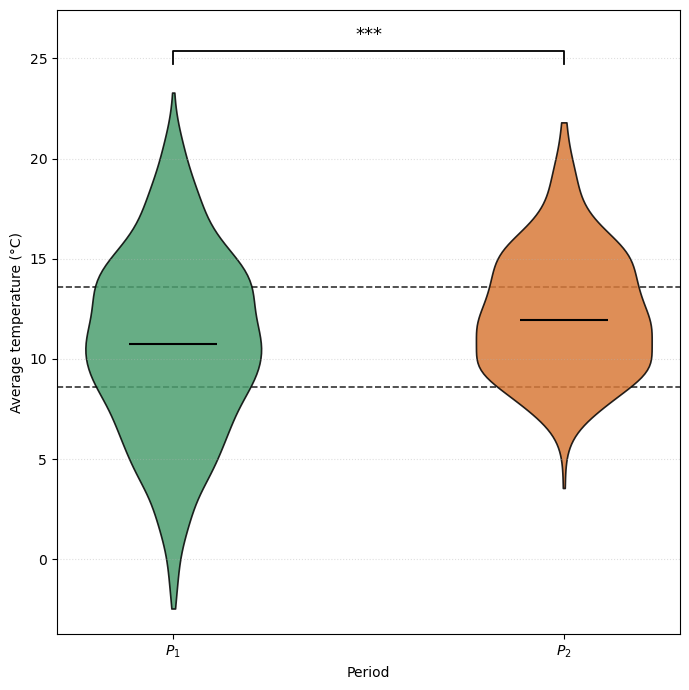

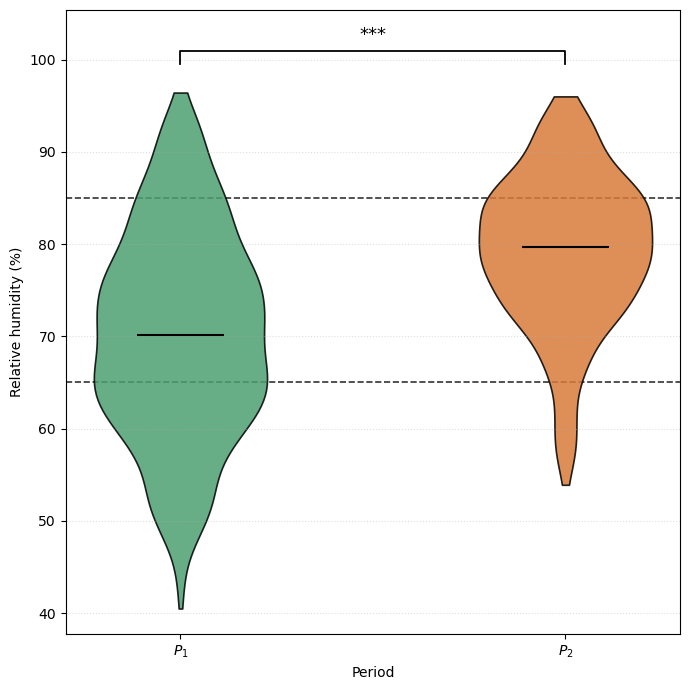

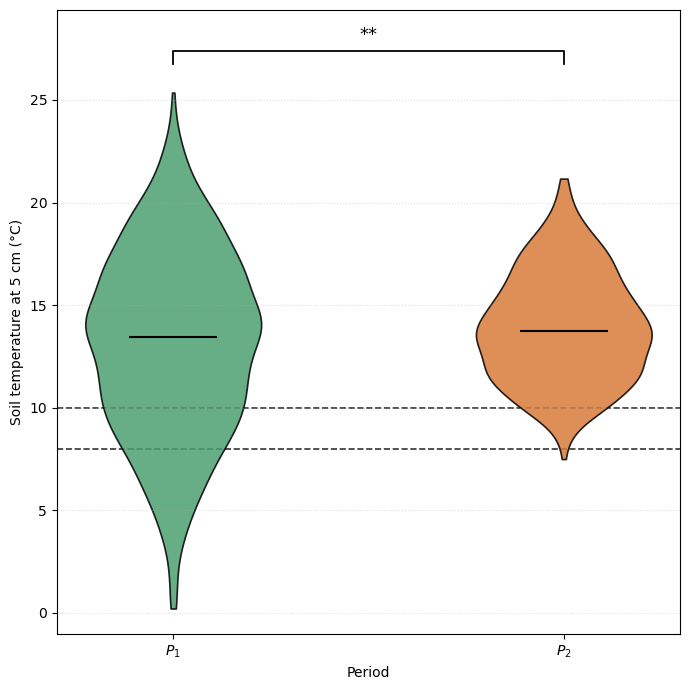

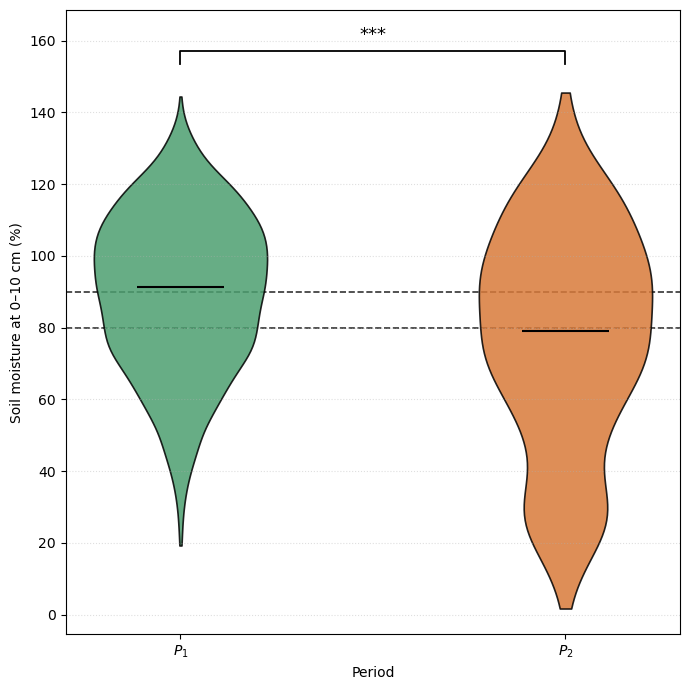

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import shapiro, mannwhitneyu
from statsmodels.stats.multitest import multipletests


# ============================================================
# Colores
# ============================================================

color_p1 = "#4C9F70"
color_p2 = "#D97A3A"


# ============================================================
# Variables
# ============================================================

variables = [
    "average_temp_c",
    "relative_humidity_%",
    "soil_temp_5cm_c",
    "soil_moisture_0-10cm_%"
]


# ============================================================
# Etiquetas
# ============================================================

variable_labels = {
    "average_temp_c":
        "Average temperature (°C)",

    "relative_humidity_%":
        "Relative humidity (%)",

    "soil_temp_5cm_c":
        "Soil temperature at 5 cm (°C)",

    "soil_moisture_0-10cm_%":
        "Soil moisture at 0–10 cm (%)"
}

figure_names = {
    "average_temp_c": "[Saxony][Euclidean][CI]Aggregated_average_temperature",
    "relative_humidity_%": "[Saxony][Euclidean][CI]Aggregated_relative_humidity",
    "soil_temp_5cm_c": "[Saxony][Euclidean][CI]Aggregated_soil_temperature_5cm",
    "soil_moisture_0-10cm_%": "[Saxony][Euclidean][CI]Aggregated_soil_moisture_0-10cm"
}



# ============================================================
# Función para obtener asteriscos
# ============================================================

def significance_stars(p):

    if pd.isna(p):
        return ""

    if p < 0.001:
        return "***"

    elif p < 0.01:
        return "**"

    elif p < 0.05:
        return "*"

    else:
        return ""


# ============================================================
# ============================================================
# 1. PRUEBAS DE NORMALIDAD
# ============================================================
# ============================================================

normality_results_CI = []


for variable in variables:

    # ========================================================
    # Datos P1
    # ========================================================

    p1_CI = (
        df_plot_CI.loc[
            df_plot_CI["Period"] == "P1",
            variable
        ]
        .dropna()
        .values
    )


    # ========================================================
    # Datos P2
    # ========================================================

    p2_CI = (
        df_plot_CI.loc[
            df_plot_CI["Period"] == "P2",
            variable
        ]
        .dropna()
        .values
    )


    # ========================================================
    # Shapiro-Wilk P1
    # ========================================================

    if 3 <= len(p1_CI) <= 5000:

        shapiro_p1_stat_CI, shapiro_p1_p_CI = shapiro(
            p1_CI
        )


        if shapiro_p1_p_CI >= 0.05:

            normality_p1_CI = "Normal"

        else:

            normality_p1_CI = "Not normal"


    else:

        shapiro_p1_stat_CI = np.nan
        shapiro_p1_p_CI = np.nan
        normality_p1_CI = "Not enough data"


    # ========================================================
    # Shapiro-Wilk P2
    # ========================================================

    if 3 <= len(p2_CI) <= 5000:

        shapiro_p2_stat_CI, shapiro_p2_p_CI = shapiro(
            p2_CI
        )


        if shapiro_p2_p_CI >= 0.05:

            normality_p2_CI = "Normal"

        else:

            normality_p2_CI = "Not normal"


    else:

        shapiro_p2_stat_CI = np.nan
        shapiro_p2_p_CI = np.nan
        normality_p2_CI = "Not enough data"


    # ========================================================
    # Guardar resultados
    # ========================================================

    normality_results_CI.append({

        "Variable": variable,

        "n_P1": len(p1_CI),
        "n_P2": len(p2_CI),

        "Shapiro_P1_W": shapiro_p1_stat_CI,
        "Shapiro_P1_p": shapiro_p1_p_CI,
        "P1_Normality": normality_p1_CI,

        "Shapiro_P2_W": shapiro_p2_stat_CI,
        "Shapiro_P2_p": shapiro_p2_p_CI,
        "P2_Normality": normality_p2_CI
    })


# ============================================================
# DataFrame de normalidad
# ============================================================

normality_results_df_CI = pd.DataFrame(
    normality_results_CI
)


# ============================================================
# MOSTRAR TABLA DE NORMALIDAD
# ============================================================

print("\n")
print("=" * 80)
print("PRUEBAS DE NORMALIDAD — SHAPIRO-WILK")
print("=" * 80)


display(
    normality_results_df_CI[
        [
            "Variable",
            "n_P1",
            "n_P2",

            "Shapiro_P1_W",
            "Shapiro_P1_p",
            "P1_Normality",

            "Shapiro_P2_W",
            "Shapiro_P2_p",
            "P2_Normality"
        ]
    ]
)


# ============================================================
# ============================================================
# 2. MANN-WHITNEY U
# ============================================================
# ============================================================

u_results_CI = []


for variable in variables:

    # ========================================================
    # Datos P1
    # ========================================================

    p1_CI = (
        df_plot_CI.loc[
            df_plot_CI["Period"] == "P1",
            variable
        ]
        .dropna()
        .values
    )


    # ========================================================
    # Datos P2
    # ========================================================

    p2_CI = (
        df_plot_CI.loc[
            df_plot_CI["Period"] == "P2",
            variable
        ]
        .dropna()
        .values
    )


    # ========================================================
    # Mann-Whitney U
    # ========================================================

    U_CI, p_value_CI = mannwhitneyu(
        p1_CI,
        p2_CI,
        alternative="two-sided",
        method="auto"
    )


    # ========================================================
    # Medianas
    # ========================================================

    median_p1_CI = np.median(
        p1_CI
    )

    median_p2_CI = np.median(
        p2_CI
    )
    
    mean_p1_CI = np.mean(
        p1_CI
    )
    
    mean_p2_CI = np.mean(
        p2_CI
    )
    
    sd_p1_CI = np.std(
        p1_CI
    )
    
    sd_p2_CI = np.std(
        p2_CI
    )


    # ========================================================
    # Diferencia de medianas
    # ========================================================

    median_difference_CI = (
        median_p2_CI - median_p1_CI
    )


    # ========================================================
    # Guardar resultados
    # ========================================================

    u_results_CI.append({

        "Variable": variable,

        "n_P1": len(p1_CI),
        "n_P2": len(p2_CI),
        
        "Mean_P1":mean_p1_CI,
        "Mean_P2":mean_p2_CI,
        
        "SD_P1":sd_p1_CI,
        "SD_P2":sd_p2_CI,

        "Median_P1": median_p1_CI,
        "Median_P2": median_p2_CI,

        "Median_difference_P2_minus_P1":
            median_difference_CI,

        "U": U_CI,

        "p_value": p_value_CI
    })


# ============================================================
# DataFrame Mann-Whitney
# ============================================================

u_results_df_CI = pd.DataFrame(
    u_results_CI
)


# ============================================================
# Corrección Bonferroni
# ============================================================

reject_CI, p_adjusted_CI, _, _ = multipletests(
    u_results_df_CI["p_value"],
    alpha=0.05,
    method="bonferroni"
)


u_results_df_CI["p_Bonferroni"] = (
    p_adjusted_CI
)

u_results_df_CI["Significant"] = (
    reject_CI
)


# ============================================================
# MOSTRAR TABLA DE MANN-WHITNEY
# ============================================================

print("\n")
print("=" * 80)
print("PRUEBA U DE MANN-WHITNEY")
print("=" * 80)


display(
    u_results_df_CI[
        [
            "Variable",
            "n_P1",
            "n_P2",
            
            "n_P1",
            "n_P2",

            "Mean_P1",
            "Mean_P2",

            "Median_P1",
            "Median_P2",

            "Median_difference_P2_minus_P1",

            "U",

            "p_value",
            "p_Bonferroni",
            "Significant"
        ]
    ]
)


# ============================================================
# ============================================================
# 3. VIOLINES
# ============================================================
# ============================================================

for variable in variables:

    # ========================================================
    # Datos P1
    # ========================================================

    p1_CI = (
        df_plot_CI.loc[
            df_plot_CI["Period"] == "P1",
            variable
        ]
        .dropna()
        .values
    )


    # ========================================================
    # Datos P2
    # ========================================================

    p2_CI = (
        df_plot_CI.loc[
            df_plot_CI["Period"] == "P2",
            variable
        ]
        .dropna()
        .values
    )


    # ========================================================
    # Figura
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(7, 7)
    )


    # ========================================================
    # Violin P1
    # ========================================================

    vp1_CI = ax.violinplot(
        p1_CI,
        positions=[1],
        widths=0.45,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )


    # ========================================================
    # Violin P2
    # ========================================================

    vp2_CI = ax.violinplot(
        p2_CI,
        positions=[2],
        widths=0.45,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )


    # ========================================================
    # Color P1
    # ========================================================

    for body in vp1_CI["bodies"]:

        body.set_facecolor(
            color_p1
        )

        body.set_edgecolor(
            "black"
        )

        body.set_linewidth(
            1.2
        )

        body.set_alpha(
            0.85
        )


    # ========================================================
    # Color P2
    # ========================================================

    for body in vp2_CI["bodies"]:

        body.set_facecolor(
            color_p2
        )

        body.set_edgecolor(
            "black"
        )

        body.set_linewidth(
            1.2
        )

        body.set_alpha(
            0.85
        )


    # ========================================================
    # Medianas
    # ========================================================

    vp1_CI["cmedians"].set_color(
        "black"
    )

    vp1_CI["cmedians"].set_linewidth(
        1.5
    )


    vp2_CI["cmedians"].set_color(
        "black"
    )

    vp2_CI["cmedians"].set_linewidth(
        1.5
    )


    # ========================================================
    # Líneas horizontales de referencia
    # ========================================================

    for reference_value in reference_lines[variable]:

        ax.axhline(
            y=reference_value,
            color="black",
            linestyle="--",
            linewidth=1.2,
            alpha=0.8,
            zorder=0
        )


    # ========================================================
    # Resultado Mann-Whitney
    # ========================================================

    result_CI = u_results_df_CI[
        u_results_df_CI["Variable"] == variable
    ]


    if not result_CI.empty:

        # ----------------------------------------------------
        # Utilizar p corregido por Bonferroni
        # ----------------------------------------------------

        p_value_CI = result_CI[
            "p_Bonferroni"
        ].iloc[0]


        stars_CI = significance_stars(
            p_value_CI
        )


        # ----------------------------------------------------
        # Dibujar solamente si es significativo
        # ----------------------------------------------------

        if stars_CI != "":

            ymax_CI = max(
                np.max(p1_CI),
                np.max(p2_CI)
            )


            ymin_CI = min(
                np.min(p1_CI),
                np.min(p2_CI)
            )


            data_range_CI = (
                ymax_CI - ymin_CI
            )


            if data_range_CI == 0:

                data_range_CI = 1


            # ------------------------------------------------
            # Altura de la barra
            # ------------------------------------------------

            line_y_CI = (
                ymax_CI
                + 0.08 * data_range_CI
            )


            tick_y_CI = (
                line_y_CI
                - 0.025 * data_range_CI
            )


            # ------------------------------------------------
            # Barra de significancia
            # ------------------------------------------------

            ax.plot(
                [1, 1, 2, 2],
                [
                    tick_y_CI,
                    line_y_CI,
                    line_y_CI,
                    tick_y_CI
                ],
                linewidth=1.3,
                color="black"
            )


            # ------------------------------------------------
            # Asteriscos
            # ------------------------------------------------

            ax.text(
                1.5,
                line_y_CI
                + 0.015 * data_range_CI,
                stars_CI,
                ha="center",
                va="bottom",
                fontsize=13
            )


            # ------------------------------------------------
            # Ampliar límite superior
            # ------------------------------------------------

            ax.set_ylim(
                ymin_CI - 0.05 * data_range_CI,
                line_y_CI + 0.08 * data_range_CI
            )


    # ========================================================
    # Formato
    # ========================================================

    ax.set_xticks([
        1,
        2
    ])


    ax.set_xticklabels([
        r"$P_1$",
        r"$P_2$"
    ])


    ax.set_xlabel(
        "Period"
    )


    ax.set_ylabel(
        variable_labels[variable]
    )




    ax.grid(
        axis="y",
        linestyle=":",
        alpha=0.4
    )


    # ========================================================
    # Ajustes
    # ========================================================

    plt.tight_layout()

    fig.savefig(
        f"{figure_names[variable]}.png",
        dpi=300,
        bbox_inches="tight",
        transparent=True
    )
    
    plt.show()
    
    output_path = (
        r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\[Saxony][Euclidean][CI]Aggregated_normality.xlsx"
    )

    normality_results_df_CI.to_excel(
        output_path,
        index=False
    )

    output_path = (
        r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\[Saxony][Euclidean][CI]Aggregated_U_test.xlsx"
    )

    u_results_df_CI.to_excel(
        output_path,
        index=False
    )

# Manhattan

## Graph

C:\Users\amigo\AppData\Local\Temp\ipykernel_12416\1560541380.py:202: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(
C:\Users\amigo\AppData\Local\Temp\ipykernel_12416\3602314001.py:9: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


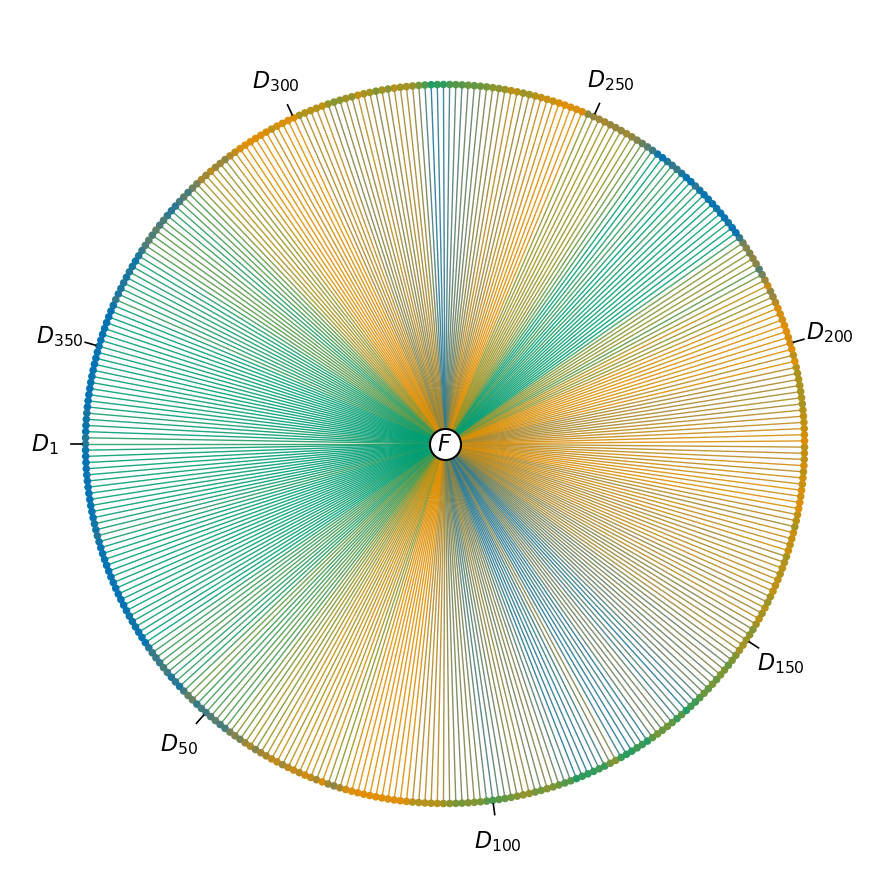

In [75]:
fig = plot_transition_graph(manhattan_vector_complement)

fig.savefig(
    "[Saxony][Manhattan]Transition_graph.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)
fig.show()

In [76]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

consecutive_manhattan = []

for day in range(1, 366):

    # ==========================================
    # Random generator
    # ==========================================
    rng = np.random.default_rng()

    probabilities = manhattan_vector_complement
    starting_position = day
    emergence_threshold = 13

    results = []

    # ==========================================
    # 5000 realizaciones de la caminata
    # ==========================================
    for _ in range(5000):

        emerged, path_length, outcome, emerged_position, emerged_time, path = random_walking(
            probabilities=probabilities,
            starting_position=starting_position,
            emergence_threshold=emergence_threshold,
            rng=rng
        )

        results.append(
            {
                "path_length": path_length,
                "outcome": outcome,
                "emerged": emerged,
                "emerged_position": emerged_position,
                "emerged_time": emerged_time,
                "path": path
            }
        )

    # ==========================================
    # Probabilidad de emergencia
    # ==========================================
    
    #print(Counter(r["emerged"] for r in results))
    
    emergence_probability = (
        sum(r["emerged"] for r in results)
        / len(results)
    )
    
    final = np.array([r["emerged"] for r in results], dtype=bool)

    n = len(final)
    n_bootstrap = 5000

    bootstrap_prob = np.array([
        np.mean(
            rng.choice(
                final,
                size=n,
                replace=True
            )
        )
        for _ in range(n_bootstrap)
    ])

    # ==========================================
    # IC 95% bootstrap percentile
    # ==========================================
    ci_prob_bootstrap = np.quantile(
        bootstrap_prob,
        [0.025, 0.975]
    )

    # ==========================================
    # Probabilidad estimada
    # ==========================================
    p_bootstrap = np.mean(final)

    #print(f"n = {n}")
    #print(f"Emergencias = {np.sum(final)}")
    #print(f"p_hat = {p_hat:.6f}")
    #print(f"IC 95% = ({ci_prob_bootstrap[0]:.6f}, "
    #      f"{ci_prob_bootstrap[1]:.6f})")

    #print(f"Probabilidad de emergencia: {p_hat:.6f}")
    #print(f"IC 95% bootstrap: {ci_prob_bootstrap}")
    

    # ==========================================
    # Longitudes de emergencia
    # ==========================================
    emergence_lengths = np.array([
        r["path_length"]
        for r in results
    ])
    
    #plt.figure(figsize=(8, 5))

    #plt.hist(
    #    emergence_lengths,
    #    bins=np.arange(
    #        emergence_lengths.min(),
    #        emergence_lengths.max() + 2
    #    ) - 0.5,
    #    edgecolor="black"
    #)

    #plt.xlabel("Emergence length")
    #plt.ylabel("Frequency")
    #plt.title("Distribution of emergence lengths")

    #plt.tight_layout()
    #plt.show()

    # Intervalo por cuantiles de las realizaciones
    ci_lengths = np.quantile(
        emergence_lengths,
        [0.025, 0.975],
        method="nearest"
    )

    # ==========================================
    # JACKKNIFE
    # ==========================================

    n = len(final)

    # Estimaciones jackknife:
    # eliminar una observación en cada iteración
    jackknife_prob = np.array([
        np.mean(
            np.delete(final, i)
        )
        for i in range(n)
    ])

    # Media de las estimaciones jackknife
    jackknife_mean = np.mean(jackknife_prob)

    # Varianza muestral de las estimaciones jackknife
    jackknife_var = np.var(
        jackknife_prob,
        ddof=1
    )

    # Error estándar jackknife
    jackknife_se = np.sqrt(
        jackknife_var / n
    )

    # t crítico
    t_score = stats.t.ppf(
        q=0.975,
        df=n - 1
    )

    # IC 95% jackknife
    ci_lengths_jack = (
        jackknife_mean - t_score * jackknife_se,
        jackknife_mean + t_score * jackknife_se
    )

    
    # ==========================================
    # Guardar resultados
    # ==========================================
    consecutive_manhattan.append(
        {
            "day": day,
            "emergence_probability": emergence_probability,
            "ci_prob_bootstrap": ci_prob_bootstrap,
            "p_bootstrap":  p_bootstrap,
            "ci_lengths_jack": ci_lengths_jack,
            "p_jackknife_mean": jackknife_mean,
            "ci_lengths" : ci_lengths

        }
    )

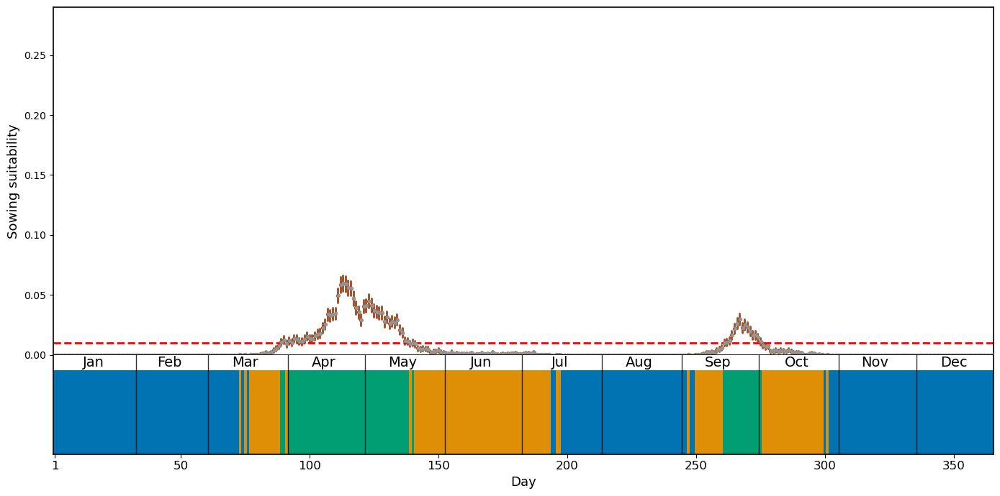

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm


# ============================================================
# Colores
# ============================================================

colorblind = sns.color_palette("colorblind")

blue = colorblind[0]
orange = colorblind[1]


# ============================================================
# Datos de probabilidad
# ============================================================

days = np.array([
    r["day"]
    for r in consecutive_manhattan
])

probabilities_bootstrap = np.array([
    r["p_bootstrap"]
    for r in consecutive_manhattan
])

ci_bootstrap = np.array([
    r["ci_prob_bootstrap"]
    for r in consecutive_manhattan
])


ci_jackknife = np.array([
    r["ci_lengths_jack"]
    for r in consecutive_manhattan
])

probabilities_jackknife = np.array([
    r["p_jackknife_mean"]
    for r in consecutive_manhattan
])


# ============================================================
# Límites de los intervalos
# ============================================================

bootstrap_low = ci_bootstrap[:, 0]
bootstrap_high = ci_bootstrap[:, 1]

jackknife_low = ci_jackknife[:, 0]
jackknife_high = ci_jackknife[:, 1]


# ============================================================
# Posiciones X
# ============================================================

x = days

offset = 0.12


# ============================================================
# Umbral teórico
# ============================================================

threshold = 0.7**13


# ============================================================
# Datos para la banda inferior
# ============================================================

n = 365

p = np.full(n, np.nan)

for r in consecutive_manhattan:

    day = r["day"]

    p[day - 1] = r["emergence_probability"]


# ============================================================
# Paleta
# ============================================================

palette = sns.color_palette(
    "colorblind",
    n_colors=3
)


# ============================================================
# Categorías de probabilidad
# ============================================================

bounds = [
    0,
    0.3**13,
    0.7**13,
    1.00
]

norm = BoundaryNorm(
    bounds,
    len(palette)
)


colors = [
    palette[norm(value)]
    if not np.isnan(value)
    else (0.85, 0.85, 0.85)
    for value in p
]


# ============================================================
# Figura
# ============================================================

fig, (ax_top, ax_bottom) = plt.subplots(
    2,
    1,
    figsize=(14, 7),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3.5, 1],
        "hspace": 0
    }
)


# ============================================================
# GRÁFICA SUPERIOR
# ============================================================

# ------------------------------------------------------------
# Bootstrap
# ------------------------------------------------------------

palette_2 = sns.color_palette(
    "colorblind",
    n_colors=8
)

for i in range(len(days)):

    ax_top.plot(
        [x[i] - offset, x[i] - offset],
        [
            bootstrap_low[i],
            bootstrap_high[i]
        ],
        color="sienna",
        linewidth=2.1,
        solid_capstyle="round"
    )

    ax_top.scatter(
        x[i] - offset,
        probabilities_bootstrap[i],
        color="sienna",
        s=8.2,
        zorder=3
    )


# ------------------------------------------------------------
# Jackknife
# ------------------------------------------------------------

for i in range(len(days)):

    ax_top.plot(
        [x[i] + offset, x[i] + offset],
        [
            jackknife_low[i],
            jackknife_high[i]
        ],
        color=palette_2[7],
        solid_capstyle="round",
        linewidth=2
    )

    ax_top.scatter(
        x[i] + offset,
        probabilities_jackknife[i],
        color=palette_2[7],
        s=8,
        zorder=3
    )


# ------------------------------------------------------------
# Umbral
# ------------------------------------------------------------

ax_top.axhline(
    threshold,
    color="red",
    linestyle="--",
    linewidth=2
)


zero = 0

ax_top.axhline(
    zero,
    color="black",
    linestyle="-",
    linewidth=2,
    zorder=5
)


# ------------------------------------------------------------
# Ejes superiores
# ------------------------------------------------------------

ax_top.set_ylabel(
    "Sowing suitability",
    fontsize=13
)

ax_top.grid(False)

ax_top.set_xlim(
    0.5,
    365.5
)


# ============================================================
# Bordes de la gráfica superior
# ============================================================

for spine in ax_top.spines.values():

    spine.set_linewidth(1.2)


# ============================================================
# Leyenda superior
# ============================================================

#legend_elements = [
#
#    Line2D(
#        [0],
#        [0],
#        color=blue,
#        marker="o",
#        linewidth=2.5,
#        markersize=5,
#        label="Bootstrap"
#    ),

#    Line2D(
#        [0],
#        [0],
#        color=orange,
#        marker="o",
#        linewidth=2.5,
#        markersize=5,
#        label="Jackknife"
#    ),

#    Line2D(
#        [0],
#        [0],
#        color="red",
#        linestyle="--",
#        linewidth=2,
#        label=r"Threshold: $0.7^{13}$"
#    )
#]

#ax_top.legend(
#    handles=legend_elements,
#    frameon=False,
#    loc="upper right"
#)


# ============================================================
# BANDA INFERIOR
# ============================================================

for day in range(1, n + 1):

    ax_bottom.bar(
        day,
        1,
        width=1,
        bottom=0,
        color=colors[day - 1],
        edgecolor="none",
        align="center"
    )


# ============================================================
# Límites de los meses
# ============================================================

month_starts = [
    1, 32, 60, 91, 121, 152,
    182, 213, 244, 274, 305, 335
]

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

month_ends = month_starts[1:] + [366]


# ============================================================
# Divisiones internas de los meses
# ============================================================

for start in month_starts[1:]:

    x_month = start + 0.5

    # --------------------------------------------------------
    # División en la banda inferior
    # --------------------------------------------------------

    ax_bottom.axvline(
        x_month,
        ymin=-0.5,
        ymax=2,
        color="black",
        linewidth=1.0,
        alpha=0.8,
        zorder=5
    )

    # --------------------------------------------------------
    # Extensión de la división hacia la gráfica superior
    #
    # En ax_top.get_xaxis_transform():
    #   y = 0  -> línea de y = 0
    #   y = 1  -> borde superior de ax_top
    #
    # Por tanto, la línea llega exactamente hasta y = 0.
    # --------------------------------------------------------

    ax_top.add_line(
        Line2D(
            [x_month, x_month],
            [-0.1, 0],
            color="black",
            linewidth=1.0,
            alpha=0.8,
            zorder=5,
            clip_on=True
        )
    )
    
    ax_top.set_ylim(0, 0.29)

    ax_top.set_yticks(
        np.arange(0, 0.30, 0.05)
    )

# ============================================================
# Marco exterior de la banda
# ============================================================

# Borde inferior
ax_bottom.spines["bottom"].set_visible(True)
ax_bottom.spines["bottom"].set_linewidth(1.2)

# Borde izquierdo
ax_bottom.spines["left"].set_visible(True)
ax_bottom.spines["left"].set_linewidth(1.2)

# Borde derecho
ax_bottom.spines["right"].set_visible(True)
ax_bottom.spines["right"].set_linewidth(1.2)

# Borde superior
ax_bottom.spines["top"].set_visible(False)
ax_bottom.spines["top"].set_linewidth(0.2)


# ============================================================
# Etiquetas de los meses
# ============================================================

month_midpoints = [
    (start + end - 1) / 2
    for start, end in zip(
        month_starts,
        month_ends
    )
]


for midpoint, month in zip(
    month_midpoints,
    month_names
):

    ax_bottom.text(
        midpoint,
        1.005,
        month,
        ha="center",
        va="bottom",
        fontsize=14
    )


# ============================================================
# Ticks del DOY
# ============================================================

tick_days = [
    1, 50, 100, 150,
    200, 250, 300, 350
]

ax_bottom.set_xticks(
    tick_days
)

ax_bottom.set_xticklabels(
    tick_days,
    fontsize=12
)


# ============================================================
# Límites de la banda
# ============================================================

ax_bottom.set_xlim(
    0.5,
    365.5
)

ax_bottom.set_ylim(
    0,
    1.18
)


# ============================================================
# Eje Y
# ============================================================

ax_bottom.set_yticks([])


# ============================================================
# Eje X
# ============================================================

ax_bottom.set_xlabel(
    "Day",
    fontsize=13
)


# ============================================================
# Leyenda inferior
# ============================================================

#legend_labels = [
#    r"$0 \leq p < 0.3^{13}$",
#    r"$0.3^{13} \leq p < 0.7^{13}$",
#    r"$0.7^{13} \leq p \leq 1$"
#]


#legend_elements_band = [
#    Patch(
#        facecolor=palette[i],
#        label=legend_labels[i]
#    )
#    for i in range(3)
#]


#ax_bottom.legend(
#    handles=legend_elements_band,
#    loc="upper center",
#    bbox_to_anchor=(0.5, -0.30),
#    ncol=3,
#    frameon=False,
#    fontsize=11
#)


# ============================================================
# Separación entre ambas gráficas
# ============================================================

ax_top.spines["bottom"].set_visible(False)

ax_top.tick_params(
    axis="x",
    bottom=False,
    labelbottom=False
)



# ============================================================
# Ajuste final
# ============================================================

plt.tight_layout()


# ============================================================
# Guardar
# ============================================================

plt.savefig(
     "[Saxony][Rectangular][Manhattan]Sowing_windows.png",
     dpi=300,
     bbox_inches="tight",
    pad_inches=0.05,
     transparent=True
)


plt.show()

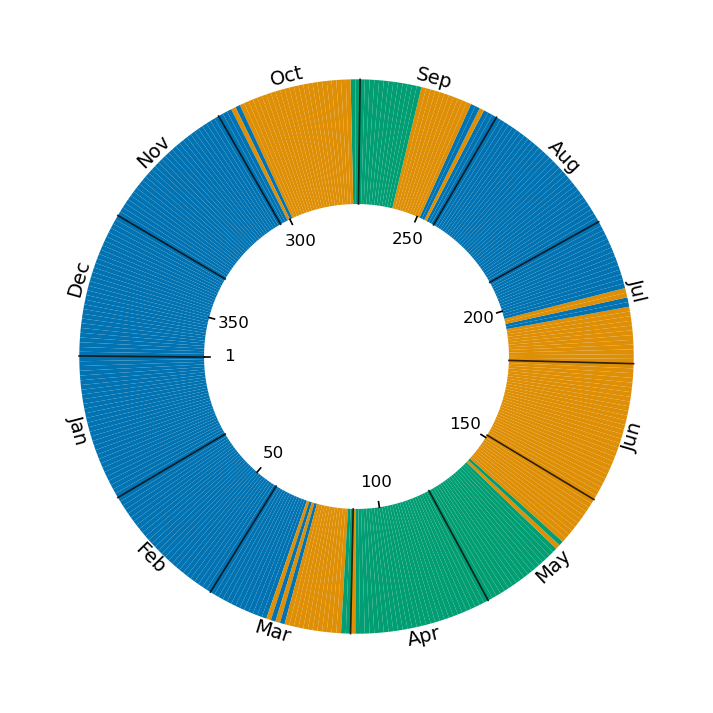

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Patch

# ============================================================
# Probabilidades
# ============================================================

n = 365

p = np.full(n, np.nan)

for r in consecutive_manhattan:
    day = r["day"]
    p[day - 1] = r["emergence_probability"]

# ============================================================
# Paleta colorblind
# ============================================================

palette = sns.color_palette("colorblind", n_colors=3)

# ============================================================
# Categorías de probabilidad
# ============================================================

bounds = [0, 0.3**13, 0.7**13, 1.00]

norm = BoundaryNorm(
    bounds,
    len(palette)
)

colors = [
    palette[norm(x)]
    if not np.isnan(x)
    else (0.85, 0.85, 0.85)
    for x in p
]

# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(figsize=(9, 9))

ax.pie(
    np.ones(n),
    colors=colors,
    startangle=180,
    counterclock=True,
    wedgeprops={
        "width": 0.45,
        "edgecolor": "none"
    }
)

# ============================================================
# Ticks cada 50 días
# ============================================================

tick_days = list(np.arange(0, 351, 50))

for day in tick_days:

    angle = np.deg2rad(
        180 + day * 360 / 365
    )

    ax.plot(
        [np.cos(angle) * 0.55, np.cos(angle) * 0.53],
        [np.sin(angle) * 0.55, np.sin(angle) * 0.53],
        color="black",
        linewidth=1.2
    )

    label_day = day + 1 if day == 0 else day

    ax.text(
        np.cos(angle) * 0.46,
        np.sin(angle) * 0.46,
        str(label_day),
        ha="center",
        va="center",
        fontsize=12
    )

# ============================================================
# Límites de los meses
# ============================================================

month_starts = [
    1, 32, 60, 91, 121, 152,
    182, 213, 244, 274, 305, 335
]

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

def day_to_angle(day):
    return 180 + (day - 1) * 360 / 365

for day in month_starts:

    angle = np.deg2rad(day_to_angle(day))

    ax.plot(
        [np.cos(angle) * 0.55, np.cos(angle)],
        [np.sin(angle) * 0.55, np.sin(angle)],
        color="black",
        linewidth=1.2,
        alpha=0.8
    )


# ============================================================
# Etiquetas de los meses — siguiendo la curvatura del círculo
# ============================================================

month_label_radius = 1.04

# Día central aproximado de cada mes
month_midpoints = [
    16, 46, 75, 106, 136, 167,
    197, 228, 259, 289, 320, 350
]

for day, month in zip(month_midpoints, month_names):

    angle_deg = day_to_angle(day)

    angle = np.deg2rad(angle_deg)

    # Posición sobre la circunferencia
    x = np.cos(angle) * month_label_radius
    y = np.sin(angle) * month_label_radius

    # Rotación tangencial:
    # el texto sigue la dirección de la circunferencia
    rotation = angle_deg + 90

    # Evitar que el texto quede invertido
    if 90 < rotation % 360 < 270:
        rotation += 180

    ax.text(
        x,
        y,
        month,
        ha="center",
        va="center",
        fontsize=14,
        rotation=rotation,
        rotation_mode="anchor"
    )


# ============================================================
# Leyenda
# ============================================================

#legend_labels = [
#    "0.00 – 0.25",
#    "0.25 – 0.50",
#    "0.50 – 0.75",
#    "0.75 – 1.00"
#]

#legend_elements = [
#    Patch(facecolor=palette[i], label=legend_labels[i])
#    for i in range(3)
#]

#ax.legend(
#    handles=legend_elements,
#    loc="center",
#    bbox_to_anchor=(0.5, 0.5),
#    frameon=False
#)

# ============================================================
# Apariencia
# ============================================================

ax.set_aspect("equal")
ax.axis("off")

plt.savefig(
    "[Saxony][Circular][Manhattan]NO_CI.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0,
    transparent=True
)

plt.show()

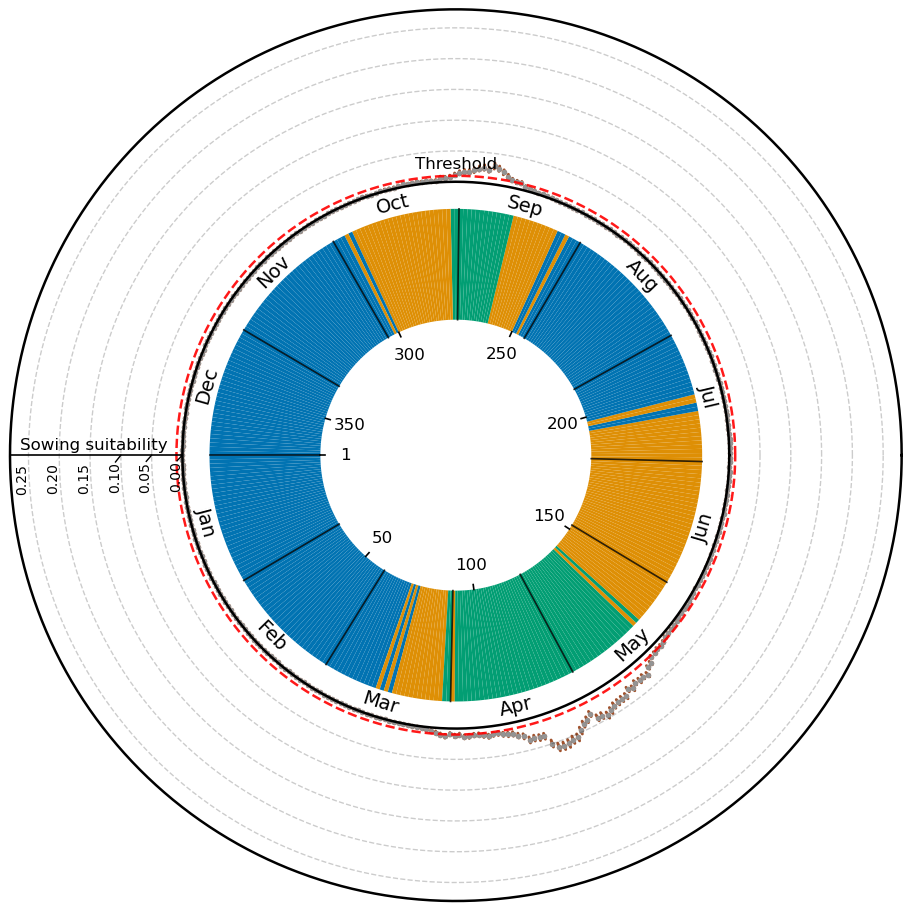

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import BoundaryNorm


# ============================================================
# Parámetros
# ============================================================

n = 365

# Círculo basal
r0 = 1.11

# Radio de las etiquetas de los meses
month_label_radius = 1.05

# Escala visual de los intervalos
scale = 2.5

# Probabilidad teórica de referencia
threshold = 0.7**13


# ============================================================
# Probabilidades
# ============================================================

p = np.full(n, np.nan)

for r in consecutive_manhattan:

    day = r["day"]

    p[day - 1] = r["emergence_probability"]

probabilities_bootstrap = np.array([
    r["p_bootstrap"]
    for r in consecutive_manhattan
])



probabilities_jackknife = np.array([
    r["p_jackknife_mean"]
    for r in consecutive_manhattan
])

# ============================================================
# Paleta colorblind
# ============================================================

palette = sns.color_palette(
    "colorblind",
    n_colors=3
)


# ============================================================
# Categorías de probabilidad
# ============================================================

bounds = [
    0,
    0.3**13,
    0.7**13,
    1.00
]

norm = BoundaryNorm(
    bounds,
    len(palette)
)

colors = [
    palette[norm(x)]
    if not np.isnan(x)
    else (0.85, 0.85, 0.85)
    for x in p
]


# ============================================================
# Figura
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 9),
    subplot_kw={"projection": "polar"},
    constrained_layout=True
)


# ============================================================
# Ángulos de los 365 días
# ============================================================

theta = np.linspace(
    0,
    2 * np.pi,
    n,
    endpoint=False
)

# Día 1 comienza al Este
theta = theta[::1] + np.pi

# Mantener los ángulos dentro de [0, 2π]
theta = np.mod(theta, 2 * np.pi)


angular_width = 2 * np.pi / n


# ============================================================
# Anillo de probabilidades
# ============================================================

ax.bar(
    theta,
    np.full(n, 0.45),
    width=angular_width,
    bottom=0.55,
    color=colors,
    edgecolor="none",
    align="edge"
)


# ============================================================
# Función de conversión día → ángulo
# ============================================================

def day_to_angle(day):

    return np.mod(
        np.pi + (day - 1) * 2 * np.pi / 365,
        2 * np.pi
    )


# ============================================================
# Ticks cada 50 días
# ============================================================

tick_days = np.arange(
    0,
    351,
    50
)

for day in tick_days:

    actual_day = day + 1 if day == 0 else day

    angle = day_to_angle(actual_day)

    # --------------------------------------------------------
    # Tick
    # --------------------------------------------------------

    ax.plot(
        [angle, angle],
        [0.55, 0.53],
        color="black",
        linewidth=1.2,
        zorder=20
    )

    # --------------------------------------------------------
    # Número del día
    # --------------------------------------------------------

    ax.text(
        angle,
        0.45,
        str(actual_day),
        ha="center",
        va="center",
        fontsize=12,
        zorder=20
    )


# ============================================================
# Límites de los meses
# ============================================================

month_starts = [
    1, 32, 60, 91, 121, 152,
    182, 213, 244, 274, 305, 335
]

# Día central aproximado de cada mes
month_midpoints = [
    16, 46, 75, 106, 136, 167,
    197, 228, 259, 289, 320, 350
]


month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]


# ============================================================
# Líneas de separación de meses
# ============================================================

for day in month_starts:

    angle = day_to_angle(day)

    ax.plot(
        [angle, angle],
        [0.55, 1.00],
        color="black",
        linewidth=1.2,
        alpha=0.8,
        zorder=15
    )


# ============================================================
# Etiquetas de los meses
# ============================================================

for day, month in zip(
    month_midpoints,
    month_names
):

    angle = day_to_angle(day)

    # Ángulo en grados para determinar orientación
    angle_deg = np.rad2deg(angle)

    rotation = angle_deg + 90

    # Evitar texto invertido
    if 90 < rotation % 360 < 270:
        rotation += 180

    # IMPORTANTE:
    # En coordenadas polares usamos directamente
    # (ángulo, radio), NO (x, y).

    ax.text(
        angle,
        month_label_radius,
        month,
        ha="center",
        va="center",
        fontsize=14,
        rotation=rotation,
        rotation_mode="anchor",
        zorder=30
    )


# ============================================================
# Círculo basal
# ============================================================

theta_circle = np.linspace(
    0,
    2 * np.pi,
    1000
)

ax.plot(
    theta_circle,
    np.full_like(
        theta_circle,
        r0
    ),
    color="black",
    linewidth=1.8,
    zorder=25
)


# ============================================================
# Escala de probabilidad en theta = pi
# ============================================================

prob_ticks = np.arange(0, 0.3, 0.05)

prob_angle = np.pi

prob_angle_deg = np.rad2deg(
    prob_angle
)

rotation = prob_angle_deg + 90

# Evitar texto invertido
if 90 <= rotation % 360 <= 270:
    rotation += 180

for prob in prob_ticks:

    # --------------------------------------------------------
    # Radio correspondiente a la probabilidad
    # --------------------------------------------------------

    r = r0 + prob * scale

    # --------------------------------------------------------
    # Tick
    # --------------------------------------------------------

    ax.plot(
        [prob_angle, prob_angle + 0.02],
        [r , r + 0.022],
        color="black",
        linewidth=1.0,
        zorder=30
    )

    # --------------------------------------------------------
    # Etiqueta
    # --------------------------------------------------------

    ax.text(
        prob_angle + 0.019,
        r+0.025,
        f"{prob:.2f}",
        ha="right",
        va="center",
        fontsize=10,
        rotation=rotation,
        rotation_mode="anchor",
        zorder=30
    )
    
    if prob > 0: 
    
        ax.plot(
        theta_circle,
        np.full_like(
            theta_circle,
            r
        ),
        color="black",
        linestyle="--",
        alpha=0.2,
        linewidth=1,
        clip_on=False,
        zorder=10
        )
    

ax.plot(
    theta_circle,
    np.full_like(
    theta_circle,
    r0 + 0.28 * scale
    ),
    color="black",
    linestyle="-",
    linewidth=1.8,
    zorder=10,
    clip_on=False
    )
            
r_start = r0
r_end = r0 + 0.28 * scale

ax.plot(
    [np.pi, np.pi],
    [r_start, r_end],
    color="black",
    linewidth=1.2,
    zorder=25,
    clip_on=False
)

ax.text(
    np.pi-0.007,
    r0 + 0.27 * scale - 0.315,
    "Sowing suitability",
    ha="center",
    va="bottom",
    fontsize=12,
    fontweight=500,
    rotation=0,
    rotation_mode="anchor",
    zorder=30
)
        
# ============================================================
# Intervalos de confianza
# ============================================================

palette_2 = sns.color_palette(
    "colorblind",
    n_colors=8
)

for i, item in enumerate(
    consecutive_manhattan
):

    angle = day_to_angle(
        item["day"]
    )

    # ========================================================
    # Bootstrap
    # ========================================================

    bootstrap_low, bootstrap_high = (
        item["ci_prob_bootstrap"]
    )

    bootstrap_low = (
        r0
        + bootstrap_low * scale
    )

    bootstrap_high = (
        r0
        + bootstrap_high * scale
    )

    ax.plot(
        [angle, angle],
        [
            bootstrap_low,
            bootstrap_high
        ],
        color="sienna",
        linewidth=2.1,
        solid_capstyle="round",
        zorder=5,
        label=(
            "Bootstrap"
            if i == 0
            else None
        )
    )

    # Círculo únicamente en la estimación puntual
    ax.scatter(
        angle,
        r0 + probabilities_bootstrap[i] * scale,
        color="sienna",
        s=8.2,
        zorder=6
    )
    # ========================================================
    # Jackknife
    # ========================================================

    jack_low, jack_high = (
        item["ci_lengths_jack"]
    )

    jack_low = (
        r0
        + jack_low * scale
    )

    jack_high = (
        r0
        + jack_high * scale
    )

    ax.plot(
        [angle, angle],
        [
            jack_low,
            jack_high
        ],
        color=palette_2[7],
        linewidth=2.1,
        solid_capstyle="round",
        zorder=5,
        label=(
            "Jackknife"
            if i == 0
            else None
        )
    )

    # Círculo únicamente en la estimación puntual
    ax.scatter(
        angle,
        r0 + probabilities_jackknife[i] * scale,
        color=palette_2[7],
        s=7.8,
        zorder=6
    )


# ============================================================
# Círculo de referencia: 0.7^13
# ============================================================

threshold_radius = (
    r0
    + threshold * scale
)

ax.plot(
    theta_circle,
    np.full_like(
        theta_circle,
        threshold_radius
    ),
    color="red",
    linestyle="--",
    linewidth=1.8,
    alpha=0.9,
    zorder=10
)

# ============================================================
# Etiqueta "Threshold" siguiendo la curvatura
# ============================================================

threshold_angle = np.pi/2

threshold_angle_deg = np.rad2deg(
    threshold_angle
)

rotation = threshold_angle_deg + 90

# Evitar texto invertido
if 90 <= rotation % 360 <= 270:
    rotation += 180

ax.text(
    threshold_angle,
    threshold_radius + 0.05,
    "Threshold",
    ha="center",
    va="center",
    fontsize=12,
    color="black",
    rotation=rotation,
    rotation_mode="anchor",
    zorder=30
)


# ============================================================
# Límite radial
# ============================================================

max_probability = max(
    max(
        item["ci_prob_bootstrap"][1],
        item["ci_lengths_jack"][1]
    )
    for item in consecutive_manhattan
)

max_radius = (
    r0
    + max(
        threshold,
        max_probability
    ) * scale
    + 0.20
)

ax.set_ylim(
    0,
    max_radius
)


# ============================================================
# Orientación
# ============================================================

ax.set_theta_zero_location("E")
ax.set_theta_direction(1)


# ============================================================
# Apariencia
# ============================================================

ax.set_xticks([])
ax.set_yticks([])

ax.grid(False)

ax.spines["polar"].set_visible(False)






# ============================================================
# Guardar
# ============================================================

plt.savefig(
    "[Saxony][Circular][Manhattan]Sowing_windows.png",
    dpi=300,
    transparent=True
)


plt.show()

# Comparisons

## Jaccard index

In [80]:
import math
import pandas as pd

threshold = 0.7**13

days_filtered = sorted(
    entry["day"]
    for entry in consecutive_manhattan
    if entry["emergence_probability"] > threshold
    and entry["day"] <= 182
)

print("Sowing window predicted:", days_filtered)


results = []

for k in range(1, 6):

    periodo = set(
        range(
            math.floor(116.2 - (7.3 * k)),
            math.ceil(116.2 + (7.3 * k))
        )
    )

    days_set = set(days_filtered)

    interseccion = sorted(periodo & days_set)
    union = sorted(periodo | days_set)

    jaccard = len(interseccion) / len(union)

    results.append({
        "Standard deviation": k,
        "Period": ", ".join(map(str, sorted(periodo))),
        "Predicted days": ", ".join(map(str, days_filtered)),
        "Intersection": ", ".join(map(str, interseccion)),
        "Intersection cardinality": len(interseccion),
        "Union": ", ".join(map(str, union)),
        "Union cardinality": len(union),
        "Jaccard index": jaccard
    })


results_df = pd.DataFrame(results)

results_df.to_excel(
    "[Saxony][Manhattan][Raw]Jaccard_index.xlsx",
    index=False
)

display(results_df)

Sowing window predicted: [89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 140]


,Standard deviation,Period,Predicted days,Intersection,Intersection cardinality,Union,Union cardinality,Jaccard index
0,1,"108, 109, 110, 111, 112, 113, 114, 115, 116, 1...","89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...","108, 109, 110, 111, 112, 113, 114, 115, 116, 1...",16,"89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...",50,0.320000
1,2,"101, 102, 103, 104, 105, 106, 107, 108, 109, 1...","89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...","101, 102, 103, 104, 105, 106, 107, 108, 109, 1...",30,"89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...",50,0.600000
2,3,"94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 10...","89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...","94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 10...",45,"89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...",50,0.900000
3,4,"87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98...","89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...","89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...",50,"87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98...",59,0.847458
4,5,"79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90...","89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...","89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...",50,"79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90...",74,0.675676


## Jaccard index CI

In [81]:
import math

threshold = 0.7**13

days_filtered_CI = set(
    entry["day"]
    for entry in consecutive_manhattan
    if (
        entry["ci_prob_bootstrap"][0] <= threshold <= entry["ci_prob_bootstrap"][1]
        or
        threshold <= entry["ci_prob_bootstrap"][0]
        or
        entry["ci_lengths_jack"][0] <= threshold <= entry["ci_lengths_jack"][1]
        or
        threshold <= entry["ci_lengths_jack"][0]
    )
    and entry["day"] <= 182
)

print("Sowing window predicted" ,days_filtered_CI, "\n")


results = []

for k in range(1, 6):

    periodo = set(
        range(
            math.floor(116.2 - (7.3 * k)),
            math.ceil(116.2 + (7.3 * k))
        )
    )

    days_set = set(days_filtered_CI)

    interseccion = sorted(periodo & days_set)
    union = sorted(periodo | days_set)

    jaccard = len(interseccion) / len(union)

    results.append({
        "Standard deviation": k,
        "Period": ", ".join(map(str, sorted(periodo))),
        "Predicted days": ", ".join(map(str, days_filtered)),
        "Intersection": ", ".join(map(str, interseccion)),
        "Intersection cardinality": len(interseccion),
        "Union": ", ".join(map(str, union)),
        "Union cardinality": len(union),
        "Jaccard index": jaccard
    })


results_df = pd.DataFrame(results)

results_df.to_excel(
    "[Saxony][Manhattan][CI]Jaccard_index.xlsx",
    index=False
)

display(results_df)

Sowing window predicted {128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127} 



,Standard deviation,Period,Predicted days,Intersection,Intersection cardinality,Union,Union cardinality,Jaccard index
0,1,"108, 109, 110, 111, 112, 113, 114, 115, 116, 1...","89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...","108, 109, 110, 111, 112, 113, 114, 115, 116, 1...",16,"88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99...",54,0.296296
1,2,"101, 102, 103, 104, 105, 106, 107, 108, 109, 1...","89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...","101, 102, 103, 104, 105, 106, 107, 108, 109, 1...",30,"88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99...",54,0.555556
2,3,"94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 10...","89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...","94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 10...",45,"88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99...",54,0.833333
3,4,"87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98...","89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...","88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99...",54,"87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98...",59,0.915254
4,5,"79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90...","89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 1...","88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99...",54,"79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90...",74,0.729730


## Sowing windows

In [82]:
import math
import pandas as pd

threshold = 0.7**13

days_filtered = sorted(
    entry["day"]
    for entry in consecutive_manhattan
    if entry["emergence_probability"] > threshold
    and entry["day"]
)


days_filtered_CI = sorted(
    entry["day"]
    for entry in consecutive_manhattan
    if (
        entry["ci_prob_bootstrap"][0] <= threshold <= entry["ci_prob_bootstrap"][1]
        or
        threshold <= entry["ci_prob_bootstrap"][0]
        or
        entry["ci_lengths_jack"][0] <= threshold <= entry["ci_lengths_jack"][1]
        or
        threshold <= entry["ci_lengths_jack"][0]
    )
)

print(days_filtered)
print(days_filtered_CI)

days_df = pd.DataFrame({
    "Predicted days": pd.Series(days_filtered),
    "CI days": pd.Series(days_filtered_CI)
})

display(days_df)

days_df.to_excel(
    "[Saxony][Manhattan]Sowing_windows.xlsx",
    index=False
)

[89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 140, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275]
[88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 278]


,Predicted days,CI days
0,89.0,88
1,90.0,89
2,92.0,90
3,93.0,91
4,94.0,92
...,...,...
66,NaN,273
67,NaN,274
68,NaN,275
69,NaN,276


## Yearly comparisons both

In [83]:
import pandas as pd
import numpy as np

from scipy.stats import mannwhitneyu
from scipy.stats import shapiro

from statsmodels.stats.multitest import multipletests


# ============================================================
# Cargar datos
# ============================================================

file_path = (
    r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\Saxony.xlsx"
)

variables = [
    "average_temp_c",
    "relative_humidity_%",
    "soil_temp_5cm_c",
    "soil_moisture_0-10cm_%"
]

df = pd.read_excel(file_path)

df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True
)

df["YEAR"] = df["Date"].dt.year


# ============================================================
# Días seleccionados por el modelo
# ============================================================

days_first_semester = {
    entry["day"]
    for entry in consecutive_manhattan
    if (
        entry["emergence_probability"] > 0.7**13
        and entry["day"] <= 182
    )
}

days_second_semester = {
    entry["day"]
    for entry in consecutive_manhattan
    if (
        entry["emergence_probability"] > 0.7**13
        and entry["day"] > 182
    )
}


# ============================================================
# Seleccionar datos
# ============================================================

df_analysis = df[
    df["DOY"].isin(
        days_first_semester | days_second_semester
    )
].copy()

df_analysis["Period"] = np.where(
    df_analysis["DOY"].isin(days_first_semester),
    "P1",
    "P2"
)


# ============================================================
# Pruebas de normalidad Shapiro-Wilk
# ============================================================

normality_results = []


for variable in variables:

    for year in sorted(
        df_analysis["YEAR"].unique()
    ):

        data_year = df_analysis[
            df_analysis["YEAR"] == year
        ]

        p1 = data_year.loc[
            data_year["Period"] == "P1",
            variable
        ].dropna()

        p2 = data_year.loc[
            data_year["Period"] == "P2",
            variable
        ].dropna()


        # ----------------------------------------------------
        # P1
        # ----------------------------------------------------

        if 3 <= len(p1) <= 5000:

            shapiro_p1_stat, shapiro_p1_p = shapiro(p1)

            if shapiro_p1_p >= 0.05:
                normality_p1 = "Normal"
            else:
                normality_p1 = "Not normal"

        else:

            shapiro_p1_stat = np.nan
            shapiro_p1_p = np.nan
            normality_p1 = "Not enough data"


        # ----------------------------------------------------
        # P2
        # ----------------------------------------------------

        if 3 <= len(p2) <= 5000:

            shapiro_p2_stat, shapiro_p2_p = shapiro(p2)

            if shapiro_p2_p >= 0.05:
                normality_p2 = "Normal"
            else:
                normality_p2 = "Not normal"

        else:

            shapiro_p2_stat = np.nan
            shapiro_p2_p = np.nan
            normality_p2 = "Not enough data"


        # ----------------------------------------------------
        # Guardar resultados
        # ----------------------------------------------------

        normality_results.append({

            "Variable": variable,
            "YEAR": year,

            "n_P1": len(p1),
            "n_P2": len(p2),

            "Shapiro_P1_W": shapiro_p1_stat,
            "Shapiro_P1_p": shapiro_p1_p,
            "P1_Normality": normality_p1,

            "Shapiro_P2_W": shapiro_p2_stat,
            "Shapiro_P2_p": shapiro_p2_p,
            "P2_Normality": normality_p2
        })


# ============================================================
# Tabla de normalidad
# ============================================================

normality_results_df = pd.DataFrame(
    normality_results
)


# ============================================================
# Ordenar resultados
# ============================================================

normality_results_df = (
    normality_results_df
    .sort_values(
        ["Variable", "YEAR"]
    )
    .reset_index(drop=True)
)


# ============================================================
# Mostrar resultados
# ============================================================

print("\n")
print("=" * 90)
print("PRUEBAS DE NORMALIDAD — SHAPIRO-WILK")
print("=" * 90)

display(
    normality_results_df[
        [
            "Variable",
            "YEAR",
            "n_P1",
            "n_P2",

            "Shapiro_P1_W",
            "Shapiro_P1_p",
            "P1_Normality",

            "Shapiro_P2_W",
            "Shapiro_P2_p",
            "P2_Normality"
        ]
    ]
)


# ============================================================
# Prueba U de Mann-Whitney
# ============================================================

mannwhitney_results = []


for variable in variables:

    for year in sorted(
        df_analysis["YEAR"].unique()
    ):

        data_year = df_analysis[
            df_analysis["YEAR"] == year
        ]

        p1 = data_year.loc[
            data_year["Period"] == "P1",
            variable
        ].dropna()

        p2 = data_year.loc[
            data_year["Period"] == "P2",
            variable
        ].dropna()


        if len(p1) > 0 and len(p2) > 0:

            U_statistic, p_value = mannwhitneyu(
                p1,
                p2,
                alternative="two-sided",
                method="auto"
            )

            mannwhitney_results.append({

                "Variable": variable,
                "YEAR": year,
                
                "mean_P1": np.mean(p1),
                
                "sd_P1": np.std(p1),

                "n_P1": len(p1),
                
                "mean_P2": np.mean(p2),
                
                "sd_P2": np.std(p2),
                
                "n_P2": len(p2),

                "U_statistic": U_statistic,
                "p_value": p_value
            })


# ============================================================
# Tabla de resultados Mann-Whitney
# ============================================================

mannwhitney_results_df = pd.DataFrame(
    mannwhitney_results
)


# ============================================================
# Corrección Bonferroni por variable
# ============================================================

mannwhitney_results_df["p_Bonferroni"] = np.nan
mannwhitney_results_df["Significant"] = False


for variable in variables:

    mask = (
        mannwhitney_results_df["Variable"]
        == variable
    )

    p_values = mannwhitney_results_df.loc[
        mask,
        "p_value"
    ]


    reject, p_adjusted, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="bonferroni"
    )


    mannwhitney_results_df.loc[
        mask,
        "p_Bonferroni"
    ] = p_adjusted


    mannwhitney_results_df.loc[
        mask,
        "Significant"
    ] = reject


# ============================================================
# Ordenar resultados
# ============================================================

mannwhitney_results_df = (
    mannwhitney_results_df
    .sort_values(
        ["Variable", "YEAR"]
    )
    .reset_index(drop=True)
)


# ============================================================
# Mostrar resultados Mann-Whitney
# ============================================================

print(
    mannwhitney_results_df[
        [
            "Variable",
            "YEAR",
            "n_P1",
            "n_P2",
            "U_statistic",
            "p_value",
            "p_Bonferroni",
            "Significant"
        ]
    ]
)

output_path = (
    r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\[Saxony][Manhattan][Raw]Yearly_normality.xlsx"
)

normality_results_df.to_excel(
    output_path,
    index=False
)

output_path = (
    r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\[Saxony][Manhattan][Raw]Yearly_U_test.xlsx"
)

mannwhitney_results_df.to_excel(
    output_path,
    index=False
)



PRUEBAS DE NORMALIDAD — SHAPIRO-WILK


,Variable,YEAR,n_P1,n_P2,Shapiro_P1_W,Shapiro_P1_p,P1_Normality,Shapiro_P2_W,Shapiro_P2_p,P2_Normality
0,average_temp_c,1996,50,15,0.977726,0.460538,Normal,0.781507,0.002149,Not normal
1,average_temp_c,1997,50,15,0.934829,0.008456,Not normal,0.966905,0.809880,Normal
2,average_temp_c,1998,50,15,0.976499,0.415529,Normal,0.806924,0.004517,Not normal
3,average_temp_c,1999,50,15,0.975998,0.398065,Normal,0.923562,0.218240,Normal
4,average_temp_c,2000,50,15,0.919416,0.002246,Not normal,0.870003,0.033744,Not normal
...,...,...,...,...,...,...,...,...,...,...
115,soil_temp_5cm_c,2021,50,15,0.975285,0.374169,Normal,0.916879,0.172607,Normal
116,soil_temp_5cm_c,2022,50,15,0.964657,0.139261,Normal,0.903805,0.108818,Normal
117,soil_temp_5cm_c,2023,50,15,0.944465,0.020310,Not normal,0.946862,0.476455,Normal
118,soil_temp_5cm_c,2024,50,15,0.890961,0.000245,Not normal,0.893106,0.074734,Normal


            Variable  YEAR  n_P1  n_P2  U_statistic       p_value  \
0     average_temp_c  1996    50    15        321.0  4.048482e-01   
1     average_temp_c  1997    50    15        263.0  8.255453e-02   
2     average_temp_c  1998    50    15        366.0  8.947116e-01   
3     average_temp_c  1999    50    15         25.0  5.277224e-08   
4     average_temp_c  2000    50    15        406.0  6.348694e-01   
..               ...   ...   ...   ...          ...           ...   
115  soil_temp_5cm_c  2021    50    15         87.0  7.592324e-06   
116  soil_temp_5cm_c  2022    50    15        405.0  6.460084e-01   
117  soil_temp_5cm_c  2023    50    15         30.0  8.146308e-08   
118  soil_temp_5cm_c  2024    50    15        402.0  6.798964e-01   
119  soil_temp_5cm_c  2025    50    15        421.0  4.786758e-01   

     p_Bonferroni  Significant  
0        1.000000        False  
1        1.000000        False  
2        1.000000        False  
3        0.000002         True  
4     

{128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 140, 89, 90, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127}
{261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275}


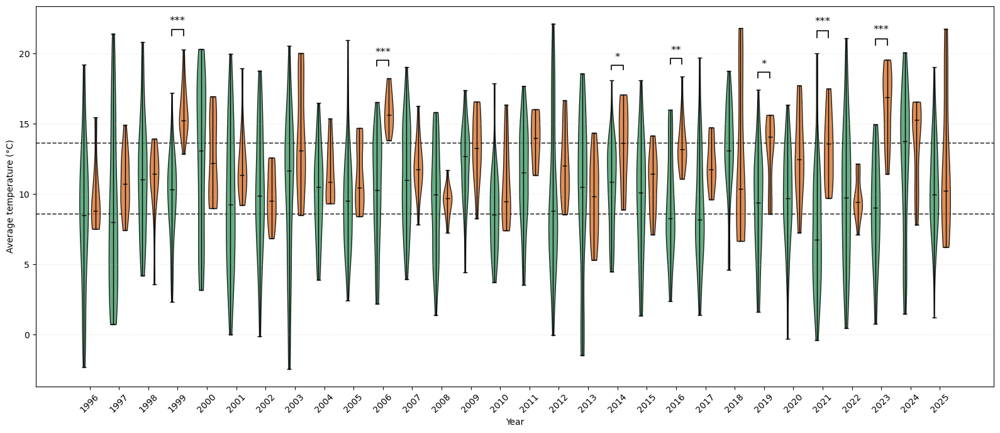

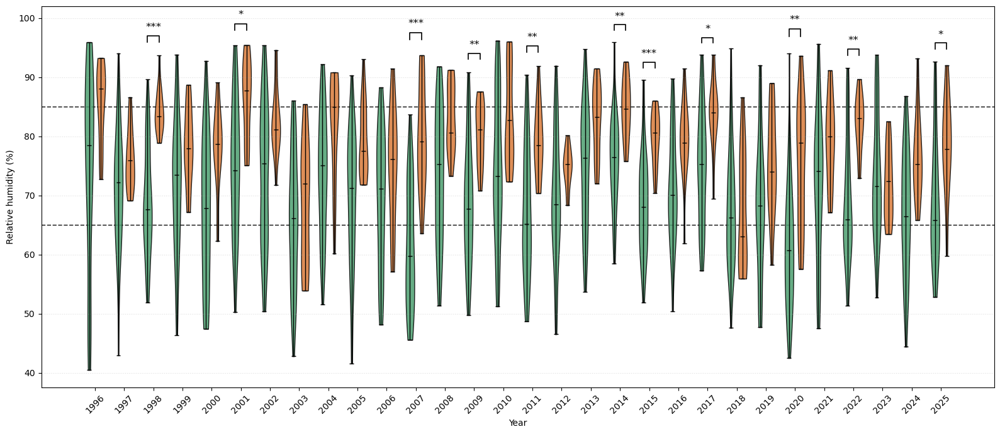

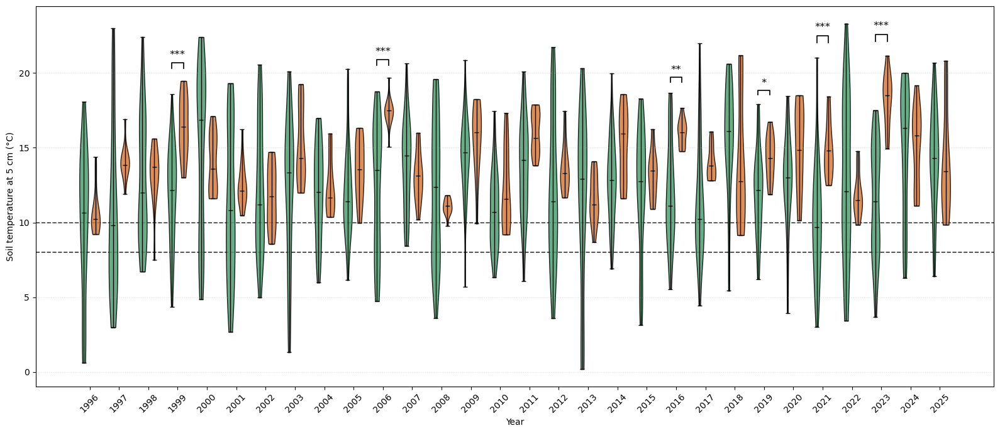

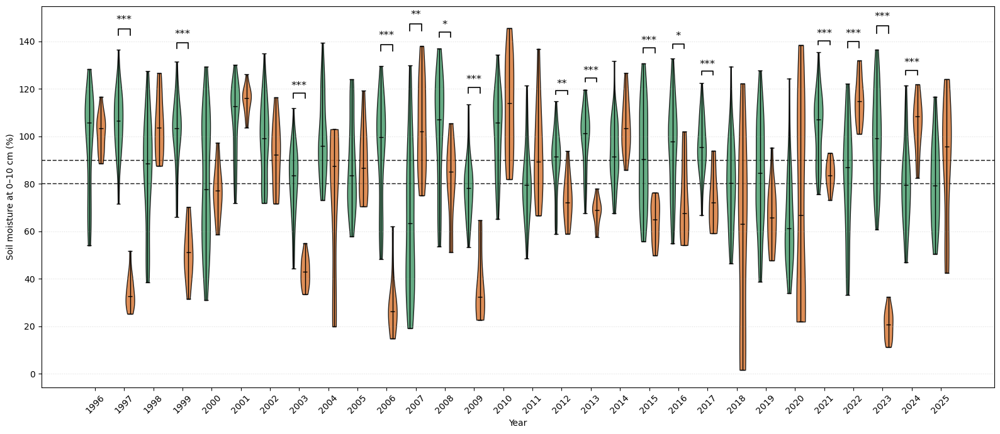

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# COLORES
# ============================================================

# Primer periodo
color_p1 = "#4C9F70"

# Segundo periodo: tono otoñal
color_p2 = "#D97A3A"

# ============================================================
# Días seleccionados
# ============================================================

days_first_semester = {
    entry["day"]
    for entry in consecutive_manhattan
    if entry["emergence_probability"] > 0.7**13
    and entry["day"] <= 182
}

days_second_semester = {
    entry["day"]
    for entry in consecutive_manhattan
    if entry["emergence_probability"] > 0.7**13
    and entry["day"] > 182
}

print(days_first_semester)

print(days_second_semester)

# ============================================================
# Preparar datos
# ============================================================

df_plot = df[
    df["DOY"].isin(
        days_first_semester | days_second_semester
    )
].copy()

df_plot["Period"] = np.where(
    df_plot["DOY"].isin(days_first_semester),
    "P1",
    "P2"
)


# ============================================================
# Función para obtener asteriscos
# ============================================================

def significance_stars(p):

    if pd.isna(p):
        return ""

    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""


# ============================================================
# Variables
# ============================================================

variables = [
    "average_temp_c",
    "relative_humidity_%",
    "soil_temp_5cm_c",
    "soil_moisture_0-10cm_%"
]


# ============================================================
# Etiquetas de variables
# ============================================================

variable_labels = {
    "average_temp_c":
        "Average temperature (°C)",

    "relative_humidity_%":
        "Relative humidity (%)",

    "soil_temp_5cm_c":
        "Soil temperature at 5 cm (°C)",

    "soil_moisture_0-10cm_%":
        "Soil moisture at 0–10 cm (%)"
}


figure_names = {
    "average_temp_c": "[Saxony][Manhattan][Raw]average_temperature",
    "relative_humidity_%": "[Saxony][Manhattan][Raw]relative_humidity",
    "soil_temp_5cm_c": "[Saxony][Manhattan][Raw]soil_temperature_5cm",
    "soil_moisture_0-10cm_%": "[Saxony][Manhattan][Raw]soil_moisture_0-10cm"
}

# ============================================================
# Límites de referencia
# ============================================================

reference_lines = {
    "average_temp_c": [
        11.10 - 2.5116,
        11.10 + 2.5116
    ],

    "relative_humidity_%": [
        65,
        85
    ],

    "soil_temp_5cm_c": [
        8,
        10
    ],

    "soil_moisture_0-10cm_%": [
        80,
        90
    ]
}

# ============================================================
# Gráficos
# ============================================================

for variable in variables:

    years = sorted(
        df_plot["YEAR"].unique()
    )

    data_p1 = []
    data_p2 = []

    valid_years = []

    # --------------------------------------------------------
    # Obtener los datos año por año
    # --------------------------------------------------------

    for year in years:

        data_year = df_plot[
            df_plot["YEAR"] == year
        ]

        p1 = data_year.loc[
            data_year["Period"] == "P1",
            variable
        ].dropna().values

        p2 = data_year.loc[
            data_year["Period"] == "P2",
            variable
        ].dropna().values

        if len(p1) > 0 and len(p2) > 0:

            data_p1.append(p1)
            data_p2.append(p2)
            valid_years.append(year)


    # --------------------------------------------------------
    # Crear figura
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(16, 7)
    )


    # --------------------------------------------------------
    # Posiciones
    # --------------------------------------------------------

    x = np.arange(
        len(valid_years)
    )

    offset = 0.20

    positions_p1 = x - offset
    positions_p2 = x + offset


       # --------------------------------------------------------
    # Violin plot primer semestre
    # --------------------------------------------------------

    vp1 = ax.violinplot(
        data_p1,
        positions=positions_p1,
        widths=0.30,
        showmeans=False,
        showmedians=True,
        showextrema=True
    )

    for body in vp1["bodies"]:
        body.set_facecolor(color_p1)
        body.set_edgecolor("black")
        body.set_linewidth(1.0)
        body.set_alpha(0.85)

    for key in ["cmedians", "cmins", "cmaxes", "cbars"]:
        if key in vp1:
            vp1[key].set_color("black")
            vp1[key].set_linewidth(1.0)


    # --------------------------------------------------------
    # Violin plot segundo semestre
    # --------------------------------------------------------

    vp2 = ax.violinplot(
        data_p2,
        positions=positions_p2,
        widths=0.30,
        showmeans=False,
        showmedians=True,
        showextrema=True
    )

    for body in vp2["bodies"]:
        body.set_facecolor(color_p2)
        body.set_edgecolor("black")
        body.set_linewidth(1.0)
        body.set_alpha(0.85)

    for key in ["cmedians", "cmins", "cmaxes", "cbars"]:
        if key in vp2:
            vp2[key].set_color("black")
            vp2[key].set_linewidth(1.0)
    # ========================================================
    # Líneas horizontales de referencia
    # ========================================================

    for reference_value in reference_lines[variable]:

        ax.axhline(
            y=reference_value,
            color="black",
            linestyle="--",
            linewidth=1.2,
            alpha=0.8,
            zorder=0
        )
            
            
    # ========================================================
    # Significancia estadística
    # ========================================================

    for i, year in enumerate(valid_years):

        result = mannwhitney_results_df[
            (mannwhitney_results_df["Variable"] == variable)
            &
            (mannwhitney_results_df["YEAR"] == year)
        ]

        if result.empty:
            continue

        p_corrected = result["p_Bonferroni"].iloc[0]

        stars = significance_stars(
            p_corrected
        )

        if stars == "":
            continue


        # ----------------------------------------------------
        # Altura de la línea
        # ----------------------------------------------------

        ymax = max(
            np.max(data_p1[i]),
            np.max(data_p2[i])
        )

        ymin = min(
            np.min(data_p1[i]),
            np.min(data_p2[i])
        )

        data_range = ymax - ymin

        if data_range == 0:
            data_range = 1


        line_y = (
            ymax
            + 0.08 * data_range
        )

        tick_y = (
            line_y
            - 0.025 * data_range
        )


        # ----------------------------------------------------
        # Línea de significancia
        # ----------------------------------------------------

        ax.plot(
            [
                positions_p1[i],
                positions_p1[i],
                positions_p2[i],
                positions_p2[i]
            ],
            [
                tick_y,
                line_y,
                line_y,
                tick_y
            ],
            linewidth=1.2,
            color="black"
        )


        # ----------------------------------------------------
        # Asteriscos
        # ----------------------------------------------------

        ax.text(
            x[i],
            line_y
            + 0.015 * data_range,
            stars,
            ha="center",
            va="bottom",
            fontsize=12
        )


    # ========================================================
    # Eje X
    # ========================================================

    ax.set_xticks(x)

    ax.set_xticklabels(
        valid_years,
        rotation=45
    )


    # ========================================================
    # Etiquetas
    # ========================================================

    ax.set_xlabel(
        "Year"
    )

    ax.set_ylabel(
        variable_labels[variable]
    )

    



    # ========================================================
    # Grid
    # ========================================================

    ax.grid(
        axis="y",
        linestyle=":",
        alpha=0.4
    )


    plt.tight_layout()

    fig.savefig(
        f"{figure_names[variable]}.png",
        dpi=300,
        transparent=True,
        bbox_inches="tight"
    )


    plt.show()

## Aggregated comparions



PRUEBAS DE NORMALIDAD — SHAPIRO-WILK


,Variable,n_P1,n_P2,Shapiro_P1_W,Shapiro_P1_p,P1_Normality,Shapiro_P2_W,Shapiro_P2_p,P2_Normality
0,average_temp_c,1500,450,0.997560,2.194401e-02,Not normal,0.984703,1.111040e-04,Not normal
1,relative_humidity_%,1500,450,0.992446,5.915815e-07,Not normal,0.977831,2.324096e-06,Not normal
2,soil_temp_5cm_c,1500,450,0.994407,2.046226e-05,Not normal,0.984899,1.253523e-04,Not normal
3,soil_moisture_0-10cm_%,1500,450,0.986700,1.670127e-10,Not normal,0.976161,9.982467e-07,Not normal




PRUEBA U DE MANN-WHITNEY


,Variable,n_P1,n_P2,Mean_P1,Mean_P2,SD_P1,SD_P2,Median_P1,Median_P2,Median_difference_P2_minus_P1,U,p_value,p_Bonferroni,Significant
0,average_temp_c,1500,450,10.118911,12.318804,4.399661,3.169378,10.218833,11.977172,1.758339,237783.0,1.753778e-21,7.015113e-21,True
1,relative_humidity_%,1500,450,70.323923,79.141633,11.380426,8.340641,70.341676,79.682329,9.340652,181914.0,6.772100e-50,2.708840e-49,True
2,soil_temp_5cm_c,1500,450,12.422785,13.999826,4.289802,2.687844,12.506224,13.742231,1.236007,263320.0,1.431279e-12,5.725114e-12,True
3,soil_moisture_0-10cm_%,1500,450,90.047055,76.616950,21.607814,31.065313,91.536459,78.303247,-13.233213,420359.0,2.584951e-15,1.033980e-14,True


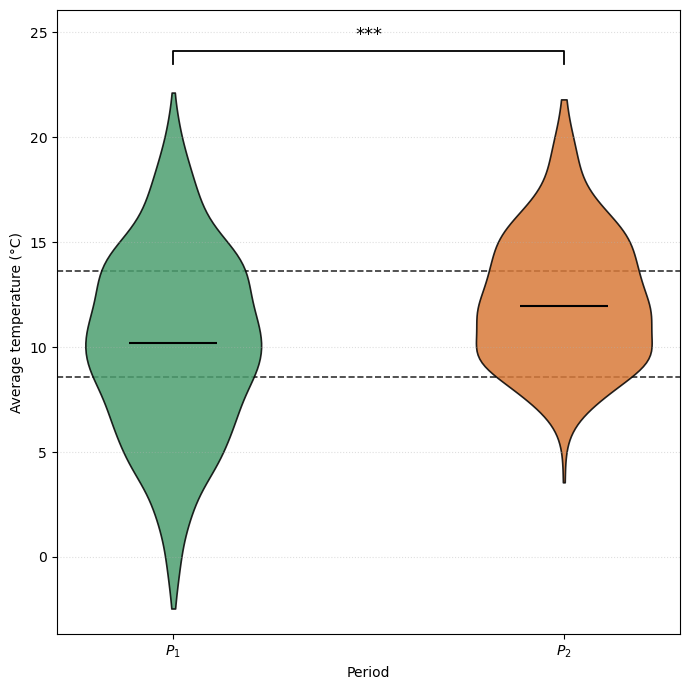

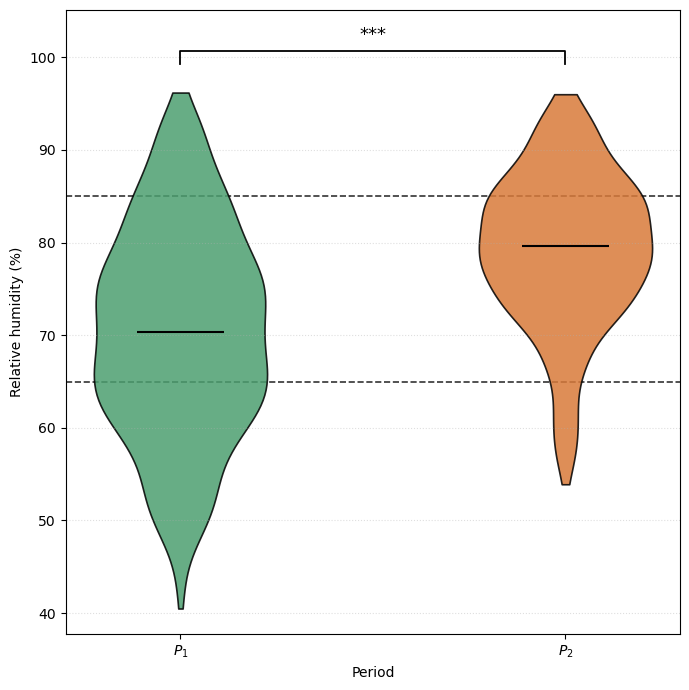

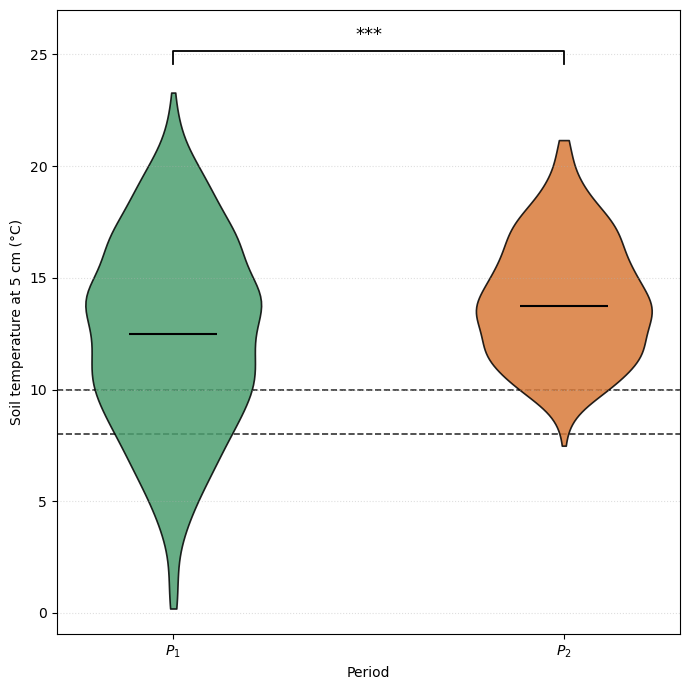

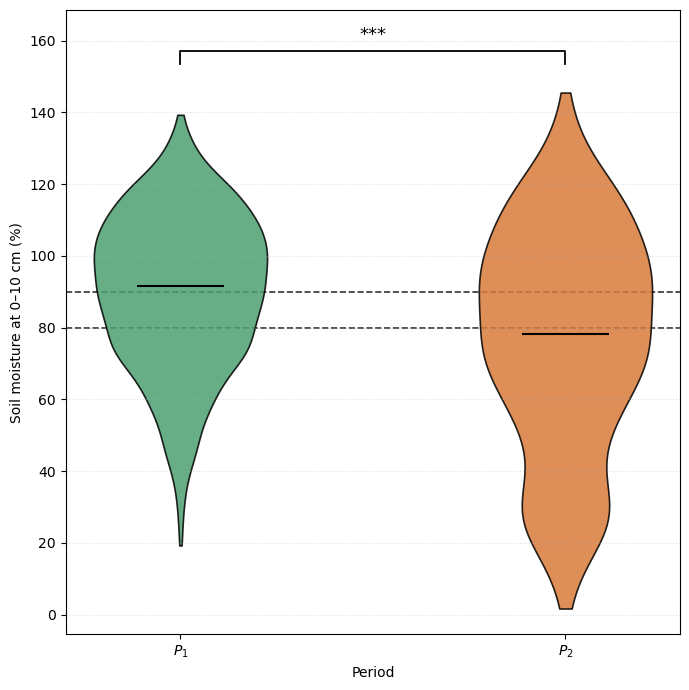

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import shapiro, mannwhitneyu
from statsmodels.stats.multitest import multipletests


# ============================================================
# Colores
# ============================================================

color_p1 = "#4C9F70"
color_p2 = "#D97A3A"


# ============================================================
# Variables
# ============================================================

variables = [
    "average_temp_c",
    "relative_humidity_%",
    "soil_temp_5cm_c",
    "soil_moisture_0-10cm_%"
]


# ============================================================
# Etiquetas
# ============================================================

variable_labels = {
    "average_temp_c":
        "Average temperature (°C)",

    "relative_humidity_%":
        "Relative humidity (%)",

    "soil_temp_5cm_c":
        "Soil temperature at 5 cm (°C)",

    "soil_moisture_0-10cm_%":
        "Soil moisture at 0–10 cm (%)"
}

figure_names = {
    "average_temp_c": "[Saxony][Manhattan][Raw]Aggregated_average_temperature",
    "relative_humidity_%": "[Saxony][Manhattan][Raw]Aggregated_relative_humidity",
    "soil_temp_5cm_c": "[Saxony][Manhattan][Raw]Aggregated_soil_temperature_5cm",
    "soil_moisture_0-10cm_%": "[Saxony][Manhattan][Raw]Aggregated_soil_moisture_0-10cm"
}


# ============================================================
# Función para obtener asteriscos
# ============================================================

def significance_stars(p):

    if pd.isna(p):
        return ""

    if p < 0.001:
        return "***"

    elif p < 0.01:
        return "**"

    elif p < 0.05:
        return "*"

    else:
        return ""

# ============================================================
# ============================================================
# 1. PRUEBAS DE NORMALIDAD
# ============================================================
# ============================================================

normality_results = []


for variable in variables:

    # --------------------------------------------------------
    # Datos P1
    # --------------------------------------------------------

    p1 = (
        df_plot.loc[
            df_plot["Period"] == "P1",
            variable
        ]
        .dropna()
        .values
    )


    # --------------------------------------------------------
    # Datos P2
    # --------------------------------------------------------

    p2 = (
        df_plot.loc[
            df_plot["Period"] == "P2",
            variable
        ]
        .dropna()
        .values
    )


    # --------------------------------------------------------
    # Shapiro-Wilk P1
    # --------------------------------------------------------

    if 3 <= len(p1) <= 5000:

        shapiro_p1_stat, shapiro_p1_p = shapiro(p1)

        # Interpretación explícita
        if shapiro_p1_p >= 0.05:
            normality_p1 = "Normal"
        else:
            normality_p1 = "Not normal"

    else:

        shapiro_p1_stat = np.nan
        shapiro_p1_p = np.nan
        normality_p1 = "Not enough data"


    # --------------------------------------------------------
    # Shapiro-Wilk P2
    # --------------------------------------------------------

    if 3 <= len(p2) <= 5000:

        shapiro_p2_stat, shapiro_p2_p = shapiro(p2)

        # Interpretación explícita
        if shapiro_p2_p >= 0.05:
            normality_p2 = "Normal"
        else:
            normality_p2 = "Not normal"

    else:

        shapiro_p2_stat = np.nan
        shapiro_p2_p = np.nan
        normality_p2 = "Not enough data"


    # --------------------------------------------------------
    # Guardar resultados
    # --------------------------------------------------------

    normality_results.append({

        "Variable": variable,

        "n_P1": len(p1),
        "n_P2": len(p2),

        "Shapiro_P1_W": shapiro_p1_stat,
        "Shapiro_P1_p": shapiro_p1_p,
        "P1_Normality": normality_p1,

        "Shapiro_P2_W": shapiro_p2_stat,
        "Shapiro_P2_p": shapiro_p2_p,
        "P2_Normality": normality_p2
    })


# ============================================================
# DataFrame de normalidad
# ============================================================

normality_results_df = pd.DataFrame(
    normality_results
)


# ============================================================
# MOSTRAR TABLA DE NORMALIDAD
# ============================================================

print("\n")
print("=" * 80)
print("PRUEBAS DE NORMALIDAD — SHAPIRO-WILK")
print("=" * 80)

display(
    normality_results_df[
        [
            "Variable",
            "n_P1",
            "n_P2",

            "Shapiro_P1_W",
            "Shapiro_P1_p",
            "P1_Normality",

            "Shapiro_P2_W",
            "Shapiro_P2_p",
            "P2_Normality"
        ]
    ]
)


# ============================================================
# ============================================================
# 2. MANN-WHITNEY U
# ============================================================
# ============================================================

u_results = []


for variable in variables:

    # --------------------------------------------------------
    # Datos P1
    # --------------------------------------------------------

    p1 = (
        df_plot.loc[
            df_plot["Period"] == "P1",
            variable
        ]
        .dropna()
        .values
    )


    # --------------------------------------------------------
    # Datos P2
    # --------------------------------------------------------

    p2 = (
        df_plot.loc[
            df_plot["Period"] == "P2",
            variable
        ]
        .dropna()
        .values
    )


    # --------------------------------------------------------
    # Mann-Whitney U
    # --------------------------------------------------------

    U, p_value = mannwhitneyu(
        p1,
        p2,
        alternative="two-sided",
        method="auto"
    )


    # --------------------------------------------------------
    # Medianas
    # --------------------------------------------------------

    median_p1 = np.median(p1)
    median_p2 = np.median(p2)
    
    mean_p1 = np.mean(p1)
    mean_p2 = np.mean(p2)
    
    sd_p1 = np.std(p1)
    sd_p2 = np.std(p2)


    # --------------------------------------------------------
    # Diferencia de medianas
    # --------------------------------------------------------

    median_difference = (
        median_p2 - median_p1
    )


    u_results.append({

        "Variable": variable,

        "n_P1": len(p1),
        "n_P2": len(p2),
        
        "Mean_P1":mean_p1,
        "Mean_P2":mean_p2,
        
        "SD_P1":sd_p1,
        "SD_P2":sd_p2,

        "Median_P1": median_p1,
        "Median_P2": median_p2,

        "Median_difference_P2_minus_P1":
            median_difference,

        "U": U,

        "p_value": p_value
    })


# ============================================================
# DataFrame Mann-Whitney
# ============================================================

u_results_df = pd.DataFrame(
    u_results
)


# ============================================================
# Corrección Bonferroni
# ============================================================

reject, p_adjusted, _, _ = multipletests(
    u_results_df["p_value"],
    alpha=0.05,
    method="bonferroni"
)


u_results_df["p_Bonferroni"] = p_adjusted

u_results_df["Significant"] = reject


# ============================================================
# MOSTRAR TABLA DE MANN-WHITNEY
# ============================================================

print("\n")
print("=" * 80)
print("PRUEBA U DE MANN-WHITNEY")
print("=" * 80)

display(
    u_results_df[
        [
            "Variable",
            "n_P1",
            "n_P2",
            
            "Mean_P1",
            "Mean_P2",

            "SD_P1",
            "SD_P2",

            "Median_P1",
            "Median_P2",

            "Median_difference_P2_minus_P1",

            "U",

            "p_value",
            "p_Bonferroni",
            "Significant"
        ]
    ]
)


# ============================================================
# ============================================================
# 3. VIOLINES
# ============================================================
# ============================================================

for variable in variables:

    # --------------------------------------------------------
    # Datos P1
    # --------------------------------------------------------

    p1 = (
        df_plot.loc[
            df_plot["Period"] == "P1",
            variable
        ]
        .dropna()
        .values
    )


    # --------------------------------------------------------
    # Datos P2
    # --------------------------------------------------------

    p2 = (
        df_plot.loc[
            df_plot["Period"] == "P2",
            variable
        ]
        .dropna()
        .values
    )


    # --------------------------------------------------------
    # Figura
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(7, 7)
    )


    # ========================================================
    # Violin P1
    # ========================================================

    vp1 = ax.violinplot(
        p1,
        positions=[1],
        widths=0.45,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )


    # ========================================================
    # Violin P2
    # ========================================================

    vp2 = ax.violinplot(
        p2,
        positions=[2],
        widths=0.45,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )


    # ========================================================
    # Color P1
    # ========================================================

    for body in vp1["bodies"]:

        body.set_facecolor(color_p1)
        body.set_edgecolor("black")
        body.set_linewidth(1.2)
        body.set_alpha(0.85)


    # ========================================================
    # Color P2
    # ========================================================

    for body in vp2["bodies"]:

        body.set_facecolor(color_p2)
        body.set_edgecolor("black")
        body.set_linewidth(1.2)
        body.set_alpha(0.85)


    # ========================================================
    # Medianas
    # ========================================================

    vp1["cmedians"].set_color("black")
    vp1["cmedians"].set_linewidth(1.5)

    vp2["cmedians"].set_color("black")
    vp2["cmedians"].set_linewidth(1.5)


    # ========================================================
    # Líneas horizontales de referencia
    # ========================================================

    for reference_value in reference_lines[variable]:

        ax.axhline(
            y=reference_value,
            color="black",
            linestyle="--",
            linewidth=1.2,
            alpha=0.8,
            zorder=0
        )


    # ========================================================
    # Resultado Mann-Whitney
    # ========================================================

    result = u_results_df[
        u_results_df["Variable"] == variable
    ]


    if not result.empty:

        # ----------------------------------------------------
        # IMPORTANTE:
        # utilizar p corregido por Bonferroni
        # ----------------------------------------------------

        p_value = result[
            "p_Bonferroni"
        ].iloc[0]


        stars = significance_stars(
            p_value
        )


        # ----------------------------------------------------
        # Dibujar solamente si es significativo
        # ----------------------------------------------------

        if stars != "":

            ymax = max(
                np.max(p1),
                np.max(p2)
            )

            ymin = min(
                np.min(p1),
                np.min(p2)
            )

            data_range = (
                ymax - ymin
            )


            if data_range == 0:
                data_range = 1


            # ------------------------------------------------
            # Altura de la barra
            # ------------------------------------------------

            line_y = (
                ymax
                + 0.08 * data_range
            )

            tick_y = (
                line_y
                - 0.025 * data_range
            )


            # ------------------------------------------------
            # Barra de significancia
            # ------------------------------------------------

            ax.plot(
                [1, 1, 2, 2],
                [
                    tick_y,
                    line_y,
                    line_y,
                    tick_y
                ],
                linewidth=1.3,
                color="black"
            )


            # ------------------------------------------------
            # Asteriscos
            # ------------------------------------------------

            ax.text(
                1.5,
                line_y + 0.015 * data_range,
                stars,
                ha="center",
                va="bottom",
                fontsize=13
            )


            # ------------------------------------------------
            # Ampliar límite superior
            # ------------------------------------------------

            ax.set_ylim(
                ymin - 0.05 * data_range,
                line_y + 0.08 * data_range
            )


    # ========================================================
    # Formato
    # ========================================================

    ax.set_xticks([
        1,
        2
    ])

    ax.set_xticklabels([
         r"$P_1$",
         r"$P_2$"
    ])

    ax.set_xlabel(
        "Period"
    )

    ax.set_ylabel(
        variable_labels[variable]
    )


    ax.grid(
        axis="y",
        linestyle=":",
        alpha=0.4
    )


    # ========================================================
    # Ajustes
    # ========================================================

    plt.tight_layout()
    
    fig.savefig(
        f"{figure_names[variable]}.png",
        dpi=300,
        transparent=True,
        bbox_inches="tight"
    )


    plt.show()
    
    output_path = (
        r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\[Saxony][Manhattan][Raw]Aggregated_normality.xlsx"
    )

    normality_results_df.to_excel(
        output_path,
        index=False
    )

    output_path = (
        r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\[Saxony][Manhattan][Raw]Aggregated_U_test.xlsx"
    )

    u_results_df.to_excel(
        output_path,
        index=False
    )

## CI

In [86]:
import pandas as pd
import numpy as np

from scipy.stats import mannwhitneyu
from scipy.stats import shapiro

from statsmodels.stats.multitest import multipletests


# ============================================================
# Cargar datos
# ============================================================

file_path = (
    r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\Saxony.xlsx"
)

variables = [
    "average_temp_c",
    "relative_humidity_%",
    "soil_temp_5cm_c",
    "soil_moisture_0-10cm_%"
]

df = pd.read_excel(file_path)

df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True
)

df["YEAR"] = df["Date"].dt.year


# ============================================================
# Días seleccionados por el modelo
# ============================================================


days_first_semester_CI = {
    entry["day"]
    for entry in consecutive_manhattan
    if (
        entry["ci_prob_bootstrap"][0] <= threshold <= entry["ci_prob_bootstrap"][1]
        or
        threshold <= entry["ci_prob_bootstrap"][0]
        or
        entry["ci_lengths_jack"][0] <= threshold <= entry["ci_lengths_jack"][1]
        or
        threshold <= entry["ci_lengths_jack"][0]
    )
    and entry["day"] <= 182
}

days_second_semester_CI = {
    entry["day"]
    for entry in consecutive_manhattan
    if (
        entry["ci_prob_bootstrap"][0] <= threshold <= entry["ci_prob_bootstrap"][1]
        or
        threshold <= entry["ci_prob_bootstrap"][0]
        or
        entry["ci_lengths_jack"][0] <= threshold <= entry["ci_lengths_jack"][1]
        or
        threshold <= entry["ci_lengths_jack"][0]
    )
    and entry["day"] > 182
}


# ============================================================
# Seleccionar datos
# ============================================================

df_analysis = df[
    df["DOY"].isin(
        days_first_semester_CI | days_second_semester_CI
    )
].copy()

df_analysis["Period"] = np.where(
    df_analysis["DOY"].isin(days_first_semester_CI),
    "P1",
    "P2"
)


# ============================================================
# Pruebas de normalidad Shapiro-Wilk
# ============================================================

normality_results = []


for variable in variables:

    for year in sorted(
        df_analysis["YEAR"].unique()
    ):

        data_year = df_analysis[
            df_analysis["YEAR"] == year
        ]

        p1_CI = data_year.loc[
            data_year["Period"] == "P1",
            variable
        ].dropna()

        p2_CI = data_year.loc[
            data_year["Period"] == "P2",
            variable
        ].dropna()


        # ----------------------------------------------------
        # P1
        # ----------------------------------------------------

        if 3 <= len(p1_CI) <= 5000:

            shapiro_p1_stat, shapiro_p1_p = shapiro(p1_CI)

            if shapiro_p1_p >= 0.05:
                normality_p1 = "Normal"
            else:
                normality_p1 = "Not normal"

        else:

            shapiro_p1_stat = np.nan
            shapiro_p1_p = np.nan
            normality_p1 = "Not enough data"


        # ----------------------------------------------------
        # P2
        # ----------------------------------------------------

        if 3 <= len(p2_CI) <= 5000:

            shapiro_p2_stat, shapiro_p2_p = shapiro(p2_CI)

            if shapiro_p2_p >= 0.05:
                normality_p2 = "Normal"
            else:
                normality_p2 = "Not normal"

        else:

            shapiro_p2_stat = np.nan
            shapiro_p2_p = np.nan
            normality_p2 = "Not enough data"


        # ----------------------------------------------------
        # Guardar resultados
        # ----------------------------------------------------

        normality_results.append({

            "Variable": variable,
            "YEAR": year,

            "n_P1": len(p1_CI),
            "n_P2": len(p2_CI),

            "Shapiro_P1_W": shapiro_p1_stat,
            "Shapiro_P1_p": shapiro_p1_p,
            "P1_Normality": normality_p1,

            "Shapiro_P2_W": shapiro_p2_stat,
            "Shapiro_P2_p": shapiro_p2_p,
            "P2_Normality": normality_p2
        })


# ============================================================
# Tabla de normalidad
# ============================================================

normality_results_df = pd.DataFrame(
    normality_results
)


# ============================================================
# Ordenar resultados
# ============================================================

normality_results_df = (
    normality_results_df
    .sort_values(
        ["Variable", "YEAR"]
    )
    .reset_index(drop=True)
)


# ============================================================
# Mostrar resultados
# ============================================================

print("\n")
print("=" * 90)
print("PRUEBAS DE NORMALIDAD — SHAPIRO-WILK")
print("=" * 90)

display(
    normality_results_df[
        [
            "Variable",
            "YEAR",
            "n_P1",
            "n_P2",

            "Shapiro_P1_W",
            "Shapiro_P1_p",
            "P1_Normality",

            "Shapiro_P2_W",
            "Shapiro_P2_p",
            "P2_Normality"
        ]
    ]
)


# ============================================================
# Prueba U de Mann-Whitney
# ============================================================

mannwhitney_results = []


for variable in variables:

    for year in sorted(
        df_analysis["YEAR"].unique()
    ):

        data_year = df_analysis[
            df_analysis["YEAR"] == year
        ]

        p1 = data_year.loc[
            data_year["Period"] == "P1",
            variable
        ].dropna()

        p2 = data_year.loc[
            data_year["Period"] == "P2",
            variable
        ].dropna()


        if len(p1) > 0 and len(p2) > 0:

            U_statistic, p_value = mannwhitneyu(
                p1,
                p2,
                alternative="two-sided",
                method="auto"
            )

            mannwhitney_results.append({

                "Variable": variable,
                "YEAR": year,
                
                "mean_P1": np.mean(p1),
                
                "sd_P1": np.std(p1),

                "n_P1": len(p1),
                
                "mean_P2": np.mean(p2),
                
                "sd_P2": np.std(p2),
                
                "n_P2": len(p2),

                "U_statistic": U_statistic,
                "p_value": p_value
            })


# ============================================================
# Tabla de resultados Mann-Whitney
# ============================================================

mannwhitney_results_df = pd.DataFrame(
    mannwhitney_results
)


# ============================================================
# Corrección Bonferroni por variable
# ============================================================

mannwhitney_results_df["p_Bonferroni"] = np.nan
mannwhitney_results_df["Significant"] = False


for variable in variables:

    mask = (
        mannwhitney_results_df["Variable"]
        == variable
    )

    p_values = mannwhitney_results_df.loc[
        mask,
        "p_value"
    ]


    reject, p_adjusted, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="bonferroni"
    )


    mannwhitney_results_df.loc[
        mask,
        "p_Bonferroni"
    ] = p_adjusted


    mannwhitney_results_df.loc[
        mask,
        "Significant"
    ] = reject


# ============================================================
# Ordenar resultados
# ============================================================

mannwhitney_results_df = (
    mannwhitney_results_df
    .sort_values(
        ["Variable", "YEAR"]
    )
    .reset_index(drop=True)
)


# ============================================================
# Mostrar resultados Mann-Whitney
# ============================================================

print(
    mannwhitney_results_df[
        [
            "Variable",
            "YEAR",
            "n_P1",
            "n_P2",
            "U_statistic",
            "p_value",
            "p_Bonferroni",
            "Significant"
        ]
    ]
)

output_path = (
    r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\[Saxony][Manhattan][CI]Yearly_normality.xlsx"
)

normality_results_df.to_excel(
    output_path,
    index=False
)

output_path = (
    r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\[Saxony][Manhattan][CI]Yearly_U_test.xlsx"
)

mannwhitney_results_df.to_excel(
    output_path,
    index=False
)



PRUEBAS DE NORMALIDAD — SHAPIRO-WILK


,Variable,YEAR,n_P1,n_P2,Shapiro_P1_W,Shapiro_P1_p,P1_Normality,Shapiro_P2_W,Shapiro_P2_p,P2_Normality
0,average_temp_c,1996,54,17,0.972782,0.254876,Normal,0.764216,0.000683,Not normal
1,average_temp_c,1997,54,17,0.937756,0.007523,Not normal,0.962989,0.688154,Normal
2,average_temp_c,1998,54,17,0.979416,0.475795,Normal,0.853042,0.011937,Not normal
3,average_temp_c,1999,54,17,0.982293,0.603274,Normal,0.930936,0.225626,Normal
4,average_temp_c,2000,54,17,0.928199,0.003097,Not normal,0.899753,0.067281,Normal
...,...,...,...,...,...,...,...,...,...,...
115,soil_temp_5cm_c,2021,54,17,0.979586,0.482875,Normal,0.933794,0.251725,Normal
116,soil_temp_5cm_c,2022,54,17,0.961102,0.077200,Normal,0.920909,0.152992,Normal
117,soil_temp_5cm_c,2023,54,17,0.958070,0.056487,Normal,0.946533,0.404049,Normal
118,soil_temp_5cm_c,2024,54,17,0.896977,0.000223,Not normal,0.900135,0.068277,Normal


            Variable  YEAR  n_P1  n_P2  U_statistic       p_value  \
0     average_temp_c  1996    54    17        399.0  4.227178e-01   
1     average_temp_c  1997    54    17        333.0  9.083446e-02   
2     average_temp_c  1998    54    17        494.0  6.420318e-01   
3     average_temp_c  1999    54    17         99.0  1.272667e-06   
4     average_temp_c  2000    54    17        468.0  9.088171e-01   
..               ...   ...   ...   ...          ...           ...   
115  soil_temp_5cm_c  2021    54    17        110.0  2.656183e-06   
116  soil_temp_5cm_c  2022    54    17        493.0  6.517116e-01   
117  soil_temp_5cm_c  2023    54    17         67.0  1.326477e-07   
118  soil_temp_5cm_c  2024    54    17        517.0  4.384776e-01   
119  soil_temp_5cm_c  2025    54    17        532.0  3.286288e-01   

     p_Bonferroni  Significant  
0        1.000000        False  
1        1.000000        False  
2        1.000000        False  
3        0.000038         True  
4     

Días P1 con CI: {128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127}
Días P2 con CI: {261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 278}


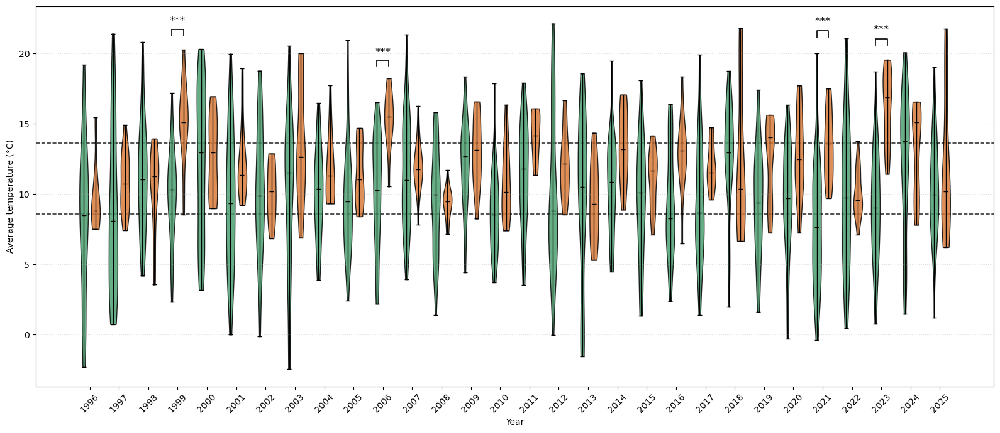

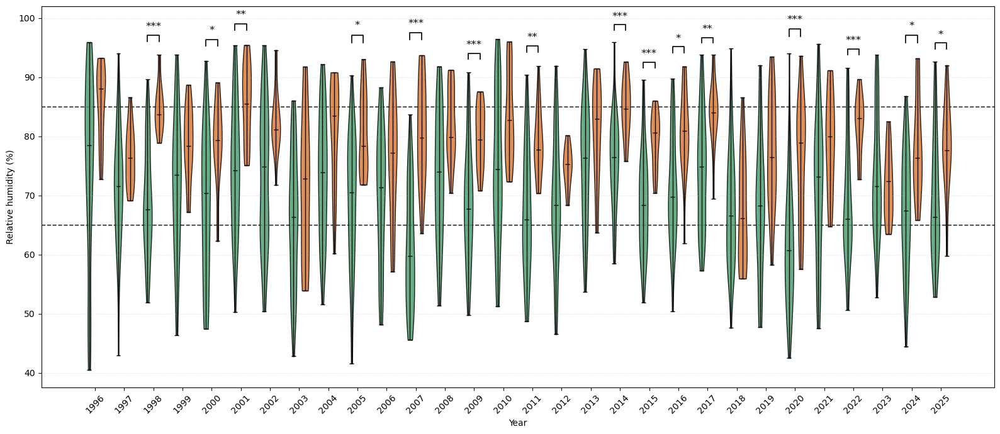

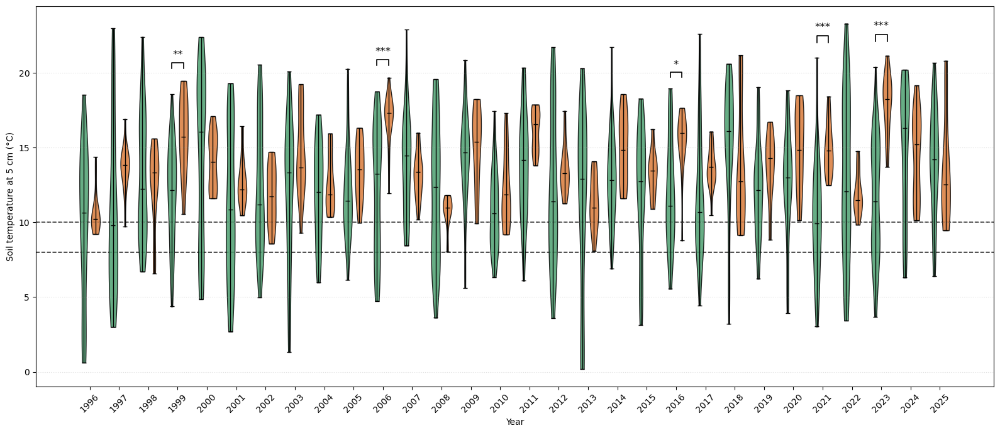

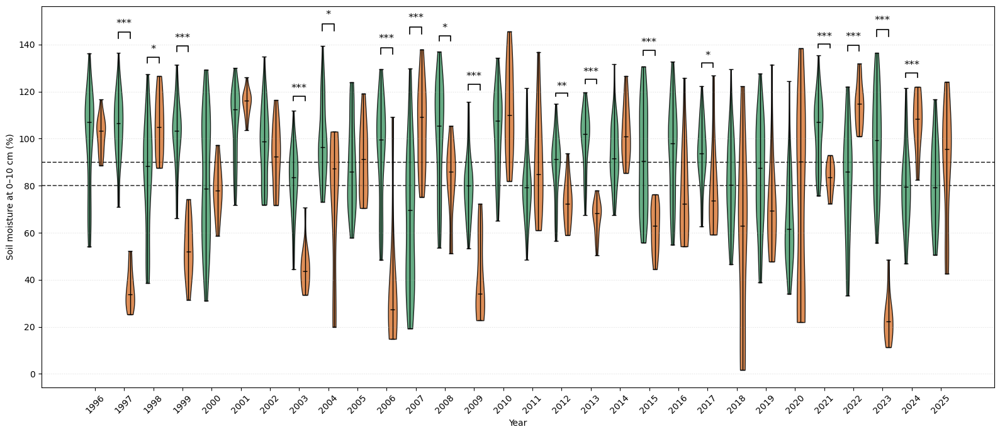

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# COLORES
# ============================================================

# Primer periodo
color_p1 = "#4C9F70"

# Segundo periodo: tono otoñal
color_p2 = "#D97A3A"


# ============================================================
# Días seleccionados mediante intervalos de confianza
# ============================================================

threshold = 0.7**13


# ------------------------------------------------------------
# Primer periodo
# ------------------------------------------------------------

days_first_semester_CI = {
    entry["day"]
    for entry in consecutive_manhattan
    if (
        entry["ci_prob_bootstrap"][0] <= threshold <= entry["ci_prob_bootstrap"][1]
        or
        threshold <= entry["ci_prob_bootstrap"][0]
        or
        entry["ci_lengths_jack"][0] <= threshold <= entry["ci_lengths_jack"][1]
        or
        threshold <= entry["ci_lengths_jack"][0]
    )
    and entry["day"] <= 182
}


print(
    "Días P1 con CI:",
    days_first_semester_CI
)


# ------------------------------------------------------------
# Segundo periodo
# ------------------------------------------------------------

days_second_semester_CI = {
    entry["day"]
    for entry in consecutive_manhattan
    if (
        entry["ci_prob_bootstrap"][0] <= threshold <= entry["ci_prob_bootstrap"][1]
        or
        threshold <= entry["ci_prob_bootstrap"][0]
        or
        entry["ci_lengths_jack"][0] <= threshold <= entry["ci_lengths_jack"][1]
        or
        threshold <= entry["ci_lengths_jack"][0]
    )
    and entry["day"] > 182
}


print(
    "Días P2 con CI:",
    days_second_semester_CI
)


# ============================================================
# Preparar datos
# ============================================================

df_plot_CI = df[
    df["DOY"].isin(
        days_first_semester_CI | days_second_semester_CI
    )
].copy()


# ------------------------------------------------------------
# Asignar periodo
# ------------------------------------------------------------

df_plot_CI["Period"] = np.where(
    df_plot_CI["DOY"].isin(days_first_semester_CI),
    "P1",
    "P2"
)


# ============================================================
# Función para obtener asteriscos de significancia
# ============================================================

def significance_stars(p):

    if pd.isna(p):
        return ""

    if p < 0.001:
        return "***"

    elif p < 0.01:
        return "**"

    elif p < 0.05:
        return "*"

    else:
        return ""


# ============================================================
# Variables
# ============================================================

variables = [
    "average_temp_c",
    "relative_humidity_%",
    "soil_temp_5cm_c",
    "soil_moisture_0-10cm_%"
]


# ============================================================
# Etiquetas de variables
# ============================================================

variable_labels = {

    "average_temp_c":
        "Average temperature (°C)",

    "relative_humidity_%":
        "Relative humidity (%)",

    "soil_temp_5cm_c":
        "Soil temperature at 5 cm (°C)",

    "soil_moisture_0-10cm_%":
        "Soil moisture at 0–10 cm (%)"
}


figure_names = {
    "average_temp_c": "[Saxony][Manhattan][CI]average_temperature",
    "relative_humidity_%": "[Saxony][Manhattan][CI]relative_humidity",
    "soil_temp_5cm_c": "[Saxony][Manhattan][CI]soil_temperature_5cm",
    "soil_moisture_0-10cm_%": "[Saxony][Manhattan][CI]soil_moisture_0-10cm"
}

# ============================================================
# Límites de referencia
# ============================================================

reference_lines = {

    "average_temp_c": [
        11.10 - 2.5116,
        11.10 + 2.5116
    ],

    "relative_humidity_%": [
        65,
        85
    ],

    "soil_temp_5cm_c": [
        8,
        10
    ],

    "soil_moisture_0-10cm_%": [
        80,
        90
    ]
}


# ============================================================
# Gráficos
# ============================================================

for variable in variables:

    # --------------------------------------------------------
    # Años disponibles
    # --------------------------------------------------------

    years_CI = sorted(
        df_plot_CI["YEAR"].unique()
    )


    # --------------------------------------------------------
    # Contenedores de datos
    # --------------------------------------------------------

    data_p1_CI = []
    data_p2_CI = []

    valid_years_CI = []


    # ========================================================
    # Obtener los datos año por año
    # ========================================================

    for year in years_CI:

        data_year_CI = df_plot_CI[
            df_plot_CI["YEAR"] == year
        ]


        # ----------------------------------------------------
        # Datos del primer periodo
        # ----------------------------------------------------

        p1_CI = data_year_CI.loc[
            data_year_CI["Period"] == "P1",
            variable
        ].dropna().values


        # ----------------------------------------------------
        # Datos del segundo periodo
        # ----------------------------------------------------

        p2_CI = data_year_CI.loc[
            data_year_CI["Period"] == "P2",
            variable
        ].dropna().values


        # ----------------------------------------------------
        # Conservar únicamente años con ambos periodos
        # ----------------------------------------------------

        if len(p1_CI) > 0 and len(p2_CI) > 0:

            data_p1_CI.append(p1_CI)
            data_p2_CI.append(p2_CI)

            valid_years_CI.append(year)


    # ========================================================
    # Crear figura
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(16, 7)
    )


    # ========================================================
    # Posiciones
    # ========================================================

    x_CI = np.arange(
        len(valid_years_CI)
    )

    offset_CI = 0.20

    positions_p1_CI = (
        x_CI - offset_CI
    )

    positions_p2_CI = (
        x_CI + offset_CI
    )


    # ========================================================
    # Violin plot: primer periodo
    # ========================================================

    vp1_CI = ax.violinplot(
        data_p1_CI,
        positions=positions_p1_CI,
        widths=0.30,
        showmeans=False,
        showmedians=True,
        showextrema=True
    )


    for body in vp1_CI["bodies"]:

        body.set_facecolor(
            color_p1
        )

        body.set_edgecolor(
            "black"
        )

        body.set_linewidth(
            1.0
        )

        body.set_alpha(
            0.85
        )


    for key in [
        "cmedians",
        "cmins",
        "cmaxes",
        "cbars"
    ]:

        if key in vp1_CI:

            vp1_CI[key].set_color(
                "black"
            )

            vp1_CI[key].set_linewidth(
                1.0
            )


    # ========================================================
    # Violin plot: segundo periodo
    # ========================================================

    vp2_CI = ax.violinplot(
        data_p2_CI,
        positions=positions_p2_CI,
        widths=0.30,
        showmeans=False,
        showmedians=True,
        showextrema=True
    )


    for body in vp2_CI["bodies"]:

        body.set_facecolor(
            color_p2
        )

        body.set_edgecolor(
            "black"
        )

        body.set_linewidth(
            1.0
        )

        body.set_alpha(
            0.85
        )


    for key in [
        "cmedians",
        "cmins",
        "cmaxes",
        "cbars"
    ]:

        if key in vp2_CI:

            vp2_CI[key].set_color(
                "black"
            )

            vp2_CI[key].set_linewidth(
                1.0
            )


    # ========================================================
    # Líneas horizontales de referencia
    # ========================================================

    for reference_value in reference_lines[variable]:

        ax.axhline(
            y=reference_value,
            color="black",
            linestyle="--",
            linewidth=1.2,
            alpha=0.8,
            zorder=0
        )


    # ========================================================
    # Significancia estadística
    # ========================================================

    for i, year in enumerate(valid_years_CI):

        result_CI = mannwhitney_results_df[
            (mannwhitney_results_df["Variable"] == variable)
            &
            (mannwhitney_results_df["YEAR"] == year)
        ]


        if result_CI.empty:
            continue


        p_corrected_CI = (
            result_CI["p_Bonferroni"].iloc[0]
        )


        stars_CI = significance_stars(
            p_corrected_CI
        )


        if stars_CI == "":
            continue


        # ----------------------------------------------------
        # Altura de los datos
        # ----------------------------------------------------

        ymax_CI = max(
            np.max(data_p1_CI[i]),
            np.max(data_p2_CI[i])
        )


        ymin_CI = min(
            np.min(data_p1_CI[i]),
            np.min(data_p2_CI[i])
        )


        data_range_CI = (
            ymax_CI - ymin_CI
        )


        if data_range_CI == 0:

            data_range_CI = 1


        # ----------------------------------------------------
        # Altura de la línea
        # ----------------------------------------------------

        line_y_CI = (
            ymax_CI
            + 0.08 * data_range_CI
        )


        tick_y_CI = (
            line_y_CI
            - 0.025 * data_range_CI
        )


        # ----------------------------------------------------
        # Línea de significancia
        # ----------------------------------------------------

        ax.plot(
            [
                positions_p1_CI[i],
                positions_p1_CI[i],
                positions_p2_CI[i],
                positions_p2_CI[i]
            ],
            [
                tick_y_CI,
                line_y_CI,
                line_y_CI,
                tick_y_CI
            ],
            linewidth=1.2,
            color="black"
        )


        # ----------------------------------------------------
        # Asteriscos
        # ----------------------------------------------------

        ax.text(
            x_CI[i],
            line_y_CI
            + 0.015 * data_range_CI,
            stars_CI,
            ha="center",
            va="bottom",
            fontsize=12
        )


    # ========================================================
    # Eje X
    # ========================================================

    ax.set_xticks(
        x_CI
    )


    ax.set_xticklabels(
        valid_years_CI,
        rotation=45
    )


    # ========================================================
    # Etiquetas
    # ========================================================

    ax.set_xlabel(
        "Year"
    )


    ax.set_ylabel(
        variable_labels[variable]
    )




    # ========================================================
    # Grid
    # ========================================================

    ax.grid(
        axis="y",
        linestyle=":",
        alpha=0.4
    )


    # ========================================================
    # Ajuste final
    # ========================================================

    plt.tight_layout()

    fig.savefig(
        f"{figure_names[variable]}.png",
        dpi=300,
        bbox_inches="tight",
        transparent=True
    )
    
    plt.show()



PRUEBAS DE NORMALIDAD — SHAPIRO-WILK


,Variable,n_P1,n_P2,Shapiro_P1_W,Shapiro_P1_p,P1_Normality,Shapiro_P2_W,Shapiro_P2_p,P2_Normality
0,average_temp_c,1620,510,0.997399,9.154885e-03,Not normal,0.987649,2.606059e-04,Not normal
1,relative_humidity_%,1620,510,0.992847,4.500926e-07,Not normal,0.978440,7.544825e-07,Not normal
2,soil_temp_5cm_c,1620,510,0.993849,2.931170e-06,Not normal,0.989554,1.082633e-03,Not normal
3,soil_moisture_0-10cm_%,1620,510,0.987733,1.764964e-10,Not normal,0.976577,2.729561e-07,Not normal




PRUEBA U DE MANN-WHITNEY


,Variable,n_P1,n_P2,n_P1,n_P2,Mean_P1,Mean_P2,Median_P1,Median_P2,Median_difference_P2_minus_P1,U,p_value,p_Bonferroni,Significant
0,average_temp_c,1620,510,1620,510,10.151783,12.182165,10.230514,11.820137,1.589623,301434.0,3.003886e-20,1.201554e-19,True
1,relative_humidity_%,1620,510,1620,510,70.345645,79.415665,70.328677,79.936097,9.607420,216951.0,5.602852e-59,2.241141e-58,True
2,soil_temp_5cm_c,1620,510,1620,510,12.426468,13.780954,12.506224,13.650136,1.143912,337525.0,4.397062e-10,1.758825e-09,True
3,soil_moisture_0-10cm_%,1620,510,1620,510,90.250848,77.926395,91.664931,80.806117,-10.858814,506032.0,1.690866e-14,6.763462e-14,True


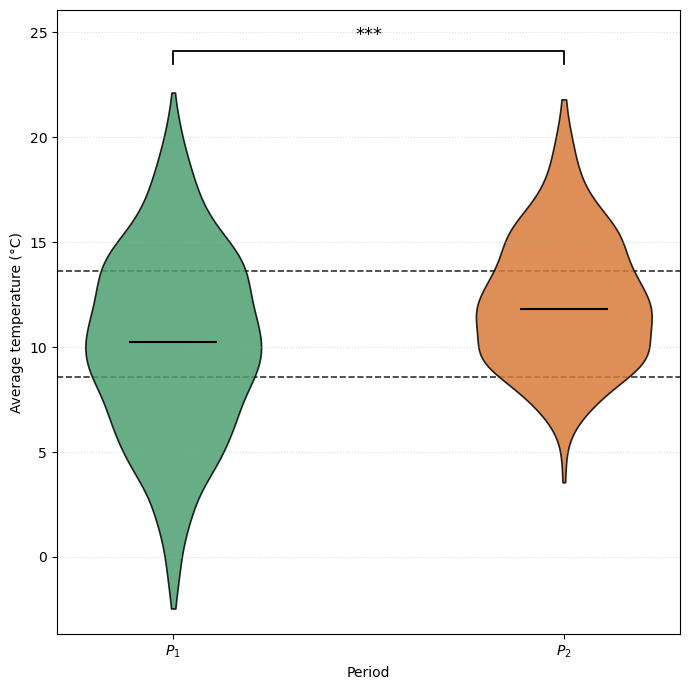

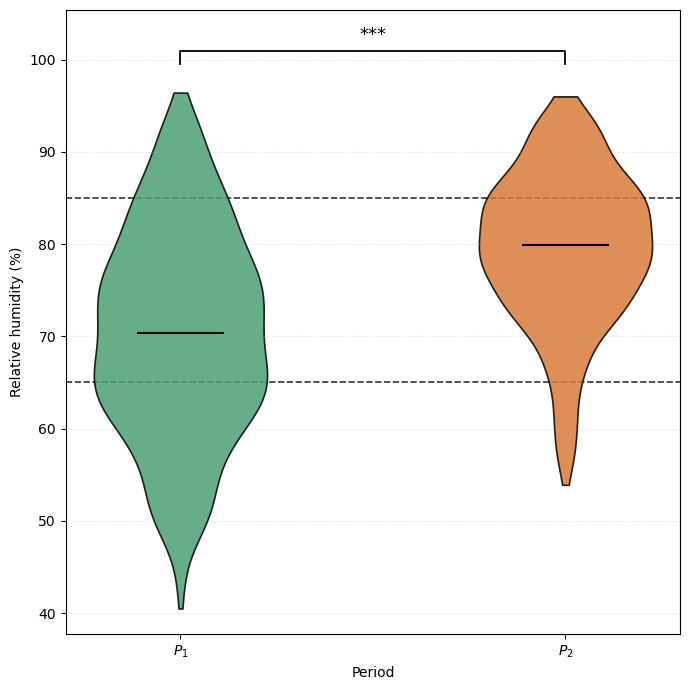

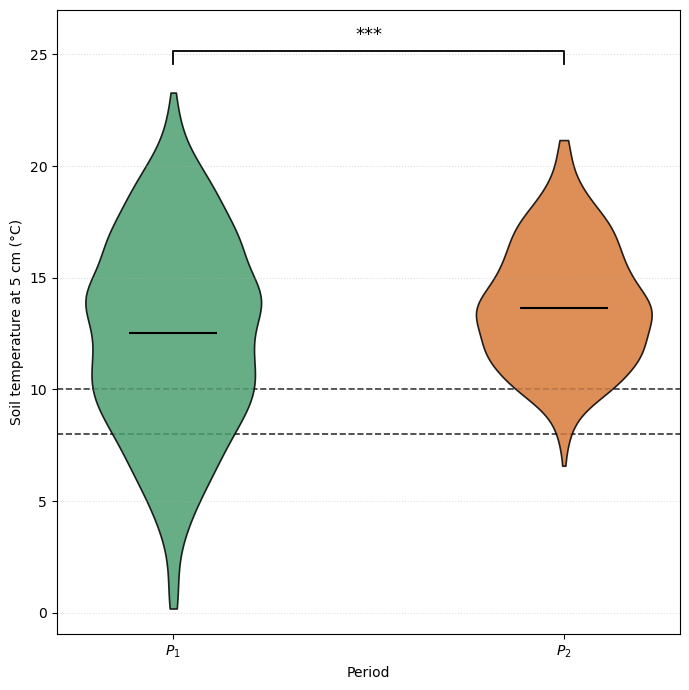

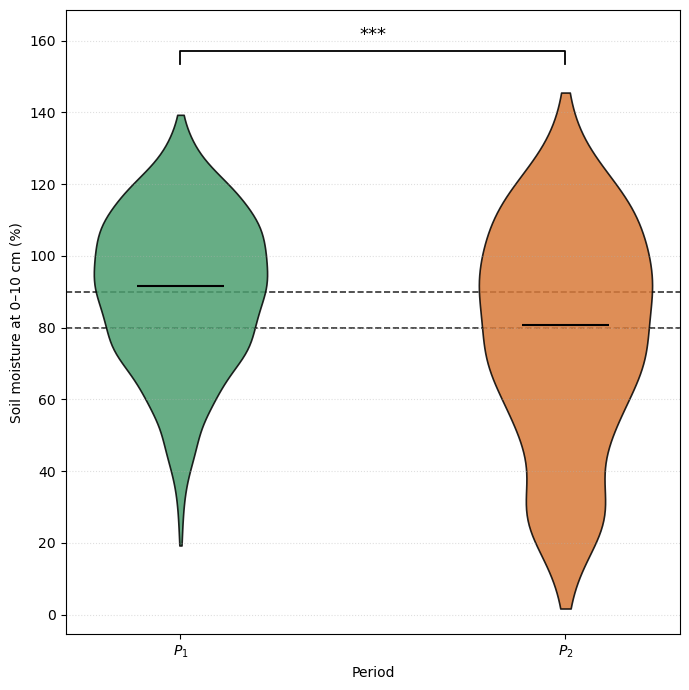

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import shapiro, mannwhitneyu
from statsmodels.stats.multitest import multipletests


# ============================================================
# Colores
# ============================================================

color_p1 = "#4C9F70"
color_p2 = "#D97A3A"


# ============================================================
# Variables
# ============================================================

variables = [
    "average_temp_c",
    "relative_humidity_%",
    "soil_temp_5cm_c",
    "soil_moisture_0-10cm_%"
]


# ============================================================
# Etiquetas
# ============================================================

variable_labels = {
    "average_temp_c":
        "Average temperature (°C)",

    "relative_humidity_%":
        "Relative humidity (%)",

    "soil_temp_5cm_c":
        "Soil temperature at 5 cm (°C)",

    "soil_moisture_0-10cm_%":
        "Soil moisture at 0–10 cm (%)"
}

figure_names = {
    "average_temp_c": "[Saxony][Manhattan][CI]Aggregated_average_temperature",
    "relative_humidity_%": "[Saxony][Manhattan][CI]Aggregated_relative_humidity",
    "soil_temp_5cm_c": "[Saxony][Manhattan][CI]Aggregated_soil_temperature_5cm",
    "soil_moisture_0-10cm_%": "[Saxony][Manhattan][CI]Aggregated_soil_moisture_0-10cm"
}



# ============================================================
# Función para obtener asteriscos
# ============================================================

def significance_stars(p):

    if pd.isna(p):
        return ""

    if p < 0.001:
        return "***"

    elif p < 0.01:
        return "**"

    elif p < 0.05:
        return "*"

    else:
        return ""


# ============================================================
# ============================================================
# 1. PRUEBAS DE NORMALIDAD
# ============================================================
# ============================================================

normality_results_CI = []


for variable in variables:

    # ========================================================
    # Datos P1
    # ========================================================

    p1_CI = (
        df_plot_CI.loc[
            df_plot_CI["Period"] == "P1",
            variable
        ]
        .dropna()
        .values
    )


    # ========================================================
    # Datos P2
    # ========================================================

    p2_CI = (
        df_plot_CI.loc[
            df_plot_CI["Period"] == "P2",
            variable
        ]
        .dropna()
        .values
    )


    # ========================================================
    # Shapiro-Wilk P1
    # ========================================================

    if 3 <= len(p1_CI) <= 5000:

        shapiro_p1_stat_CI, shapiro_p1_p_CI = shapiro(
            p1_CI
        )


        if shapiro_p1_p_CI >= 0.05:

            normality_p1_CI = "Normal"

        else:

            normality_p1_CI = "Not normal"


    else:

        shapiro_p1_stat_CI = np.nan
        shapiro_p1_p_CI = np.nan
        normality_p1_CI = "Not enough data"


    # ========================================================
    # Shapiro-Wilk P2
    # ========================================================

    if 3 <= len(p2_CI) <= 5000:

        shapiro_p2_stat_CI, shapiro_p2_p_CI = shapiro(
            p2_CI
        )


        if shapiro_p2_p_CI >= 0.05:

            normality_p2_CI = "Normal"

        else:

            normality_p2_CI = "Not normal"


    else:

        shapiro_p2_stat_CI = np.nan
        shapiro_p2_p_CI = np.nan
        normality_p2_CI = "Not enough data"


    # ========================================================
    # Guardar resultados
    # ========================================================

    normality_results_CI.append({

        "Variable": variable,

        "n_P1": len(p1_CI),
        "n_P2": len(p2_CI),

        "Shapiro_P1_W": shapiro_p1_stat_CI,
        "Shapiro_P1_p": shapiro_p1_p_CI,
        "P1_Normality": normality_p1_CI,

        "Shapiro_P2_W": shapiro_p2_stat_CI,
        "Shapiro_P2_p": shapiro_p2_p_CI,
        "P2_Normality": normality_p2_CI
    })


# ============================================================
# DataFrame de normalidad
# ============================================================

normality_results_df_CI = pd.DataFrame(
    normality_results_CI
)


# ============================================================
# MOSTRAR TABLA DE NORMALIDAD
# ============================================================

print("\n")
print("=" * 80)
print("PRUEBAS DE NORMALIDAD — SHAPIRO-WILK")
print("=" * 80)


display(
    normality_results_df_CI[
        [
            "Variable",
            "n_P1",
            "n_P2",

            "Shapiro_P1_W",
            "Shapiro_P1_p",
            "P1_Normality",

            "Shapiro_P2_W",
            "Shapiro_P2_p",
            "P2_Normality"
        ]
    ]
)


# ============================================================
# ============================================================
# 2. MANN-WHITNEY U
# ============================================================
# ============================================================

u_results_CI = []


for variable in variables:

    # ========================================================
    # Datos P1
    # ========================================================

    p1_CI = (
        df_plot_CI.loc[
            df_plot_CI["Period"] == "P1",
            variable
        ]
        .dropna()
        .values
    )


    # ========================================================
    # Datos P2
    # ========================================================

    p2_CI = (
        df_plot_CI.loc[
            df_plot_CI["Period"] == "P2",
            variable
        ]
        .dropna()
        .values
    )


    # ========================================================
    # Mann-Whitney U
    # ========================================================

    U_CI, p_value_CI = mannwhitneyu(
        p1_CI,
        p2_CI,
        alternative="two-sided",
        method="auto"
    )


    # ========================================================
    # Medianas
    # ========================================================

    median_p1_CI = np.median(
        p1_CI
    )

    median_p2_CI = np.median(
        p2_CI
    )
    
    mean_p1_CI = np.mean(
        p1_CI
    )
    
    mean_p2_CI = np.mean(
        p2_CI
    )
    
    sd_p1_CI = np.std(
        p1_CI
    )
    
    sd_p2_CI = np.std(
        p2_CI
    )


    # ========================================================
    # Diferencia de medianas
    # ========================================================

    median_difference_CI = (
        median_p2_CI - median_p1_CI
    )


    # ========================================================
    # Guardar resultados
    # ========================================================

    u_results_CI.append({

        "Variable": variable,

        "n_P1": len(p1_CI),
        "n_P2": len(p2_CI),
        
        "Mean_P1":mean_p1_CI,
        "Mean_P2":mean_p2_CI,
        
        "SD_P1":sd_p1_CI,
        "SD_P2":sd_p2_CI,

        "Median_P1": median_p1_CI,
        "Median_P2": median_p2_CI,

        "Median_difference_P2_minus_P1":
            median_difference_CI,

        "U": U_CI,

        "p_value": p_value_CI
    })


# ============================================================
# DataFrame Mann-Whitney
# ============================================================

u_results_df_CI = pd.DataFrame(
    u_results_CI
)


# ============================================================
# Corrección Bonferroni
# ============================================================

reject_CI, p_adjusted_CI, _, _ = multipletests(
    u_results_df_CI["p_value"],
    alpha=0.05,
    method="bonferroni"
)


u_results_df_CI["p_Bonferroni"] = (
    p_adjusted_CI
)

u_results_df_CI["Significant"] = (
    reject_CI
)


# ============================================================
# MOSTRAR TABLA DE MANN-WHITNEY
# ============================================================

print("\n")
print("=" * 80)
print("PRUEBA U DE MANN-WHITNEY")
print("=" * 80)


display(
    u_results_df_CI[
        [
            "Variable",
            "n_P1",
            "n_P2",
            
            "n_P1",
            "n_P2",

            "Mean_P1",
            "Mean_P2",

            "Median_P1",
            "Median_P2",

            "Median_difference_P2_minus_P1",

            "U",

            "p_value",
            "p_Bonferroni",
            "Significant"
        ]
    ]
)


# ============================================================
# ============================================================
# 3. VIOLINES
# ============================================================
# ============================================================

for variable in variables:

    # ========================================================
    # Datos P1
    # ========================================================

    p1_CI = (
        df_plot_CI.loc[
            df_plot_CI["Period"] == "P1",
            variable
        ]
        .dropna()
        .values
    )


    # ========================================================
    # Datos P2
    # ========================================================

    p2_CI = (
        df_plot_CI.loc[
            df_plot_CI["Period"] == "P2",
            variable
        ]
        .dropna()
        .values
    )


    # ========================================================
    # Figura
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(7, 7)
    )


    # ========================================================
    # Violin P1
    # ========================================================

    vp1_CI = ax.violinplot(
        p1_CI,
        positions=[1],
        widths=0.45,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )


    # ========================================================
    # Violin P2
    # ========================================================

    vp2_CI = ax.violinplot(
        p2_CI,
        positions=[2],
        widths=0.45,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )


    # ========================================================
    # Color P1
    # ========================================================

    for body in vp1_CI["bodies"]:

        body.set_facecolor(
            color_p1
        )

        body.set_edgecolor(
            "black"
        )

        body.set_linewidth(
            1.2
        )

        body.set_alpha(
            0.85
        )


    # ========================================================
    # Color P2
    # ========================================================

    for body in vp2_CI["bodies"]:

        body.set_facecolor(
            color_p2
        )

        body.set_edgecolor(
            "black"
        )

        body.set_linewidth(
            1.2
        )

        body.set_alpha(
            0.85
        )


    # ========================================================
    # Medianas
    # ========================================================

    vp1_CI["cmedians"].set_color(
        "black"
    )

    vp1_CI["cmedians"].set_linewidth(
        1.5
    )


    vp2_CI["cmedians"].set_color(
        "black"
    )

    vp2_CI["cmedians"].set_linewidth(
        1.5
    )


    # ========================================================
    # Líneas horizontales de referencia
    # ========================================================

    for reference_value in reference_lines[variable]:

        ax.axhline(
            y=reference_value,
            color="black",
            linestyle="--",
            linewidth=1.2,
            alpha=0.8,
            zorder=0
        )


    # ========================================================
    # Resultado Mann-Whitney
    # ========================================================

    result_CI = u_results_df_CI[
        u_results_df_CI["Variable"] == variable
    ]


    if not result_CI.empty:

        # ----------------------------------------------------
        # Utilizar p corregido por Bonferroni
        # ----------------------------------------------------

        p_value_CI = result_CI[
            "p_Bonferroni"
        ].iloc[0]


        stars_CI = significance_stars(
            p_value_CI
        )


        # ----------------------------------------------------
        # Dibujar solamente si es significativo
        # ----------------------------------------------------

        if stars_CI != "":

            ymax_CI = max(
                np.max(p1_CI),
                np.max(p2_CI)
            )


            ymin_CI = min(
                np.min(p1_CI),
                np.min(p2_CI)
            )


            data_range_CI = (
                ymax_CI - ymin_CI
            )


            if data_range_CI == 0:

                data_range_CI = 1


            # ------------------------------------------------
            # Altura de la barra
            # ------------------------------------------------

            line_y_CI = (
                ymax_CI
                + 0.08 * data_range_CI
            )


            tick_y_CI = (
                line_y_CI
                - 0.025 * data_range_CI
            )


            # ------------------------------------------------
            # Barra de significancia
            # ------------------------------------------------

            ax.plot(
                [1, 1, 2, 2],
                [
                    tick_y_CI,
                    line_y_CI,
                    line_y_CI,
                    tick_y_CI
                ],
                linewidth=1.3,
                color="black"
            )


            # ------------------------------------------------
            # Asteriscos
            # ------------------------------------------------

            ax.text(
                1.5,
                line_y_CI
                + 0.015 * data_range_CI,
                stars_CI,
                ha="center",
                va="bottom",
                fontsize=13
            )


            # ------------------------------------------------
            # Ampliar límite superior
            # ------------------------------------------------

            ax.set_ylim(
                ymin_CI - 0.05 * data_range_CI,
                line_y_CI + 0.08 * data_range_CI
            )


    # ========================================================
    # Formato
    # ========================================================

    ax.set_xticks([
        1,
        2
    ])


    ax.set_xticklabels([
        r"$P_1$",
        r"$P_2$"
    ])


    ax.set_xlabel(
        "Period"
    )


    ax.set_ylabel(
        variable_labels[variable]
    )




    ax.grid(
        axis="y",
        linestyle=":",
        alpha=0.4
    )


    # ========================================================
    # Ajustes
    # ========================================================

    plt.tight_layout()

    fig.savefig(
        f"{figure_names[variable]}.png",
        dpi=300,
        bbox_inches="tight",
        transparent=True
    )
    
    plt.show()
    
    output_path = (
        r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\[Saxony][Manhattan][CI]Aggregated_normality.xlsx"
    )

    normality_results_df_CI.to_excel(
        output_path,
        index=False
    )

    output_path = (
        r"C:\Users\amigo\Documents\GitHub\PlantingDates\Grids Germany\No leap years\[Saxony][Manhattan][CI]Aggregated_U_test.xlsx"
    )

    u_results_df_CI.to_excel(
        output_path,
        index=False
    )

# Alternative graph

C:\Users\amigo\AppData\Local\Temp\ipykernel_12416\194841388.py:198: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(


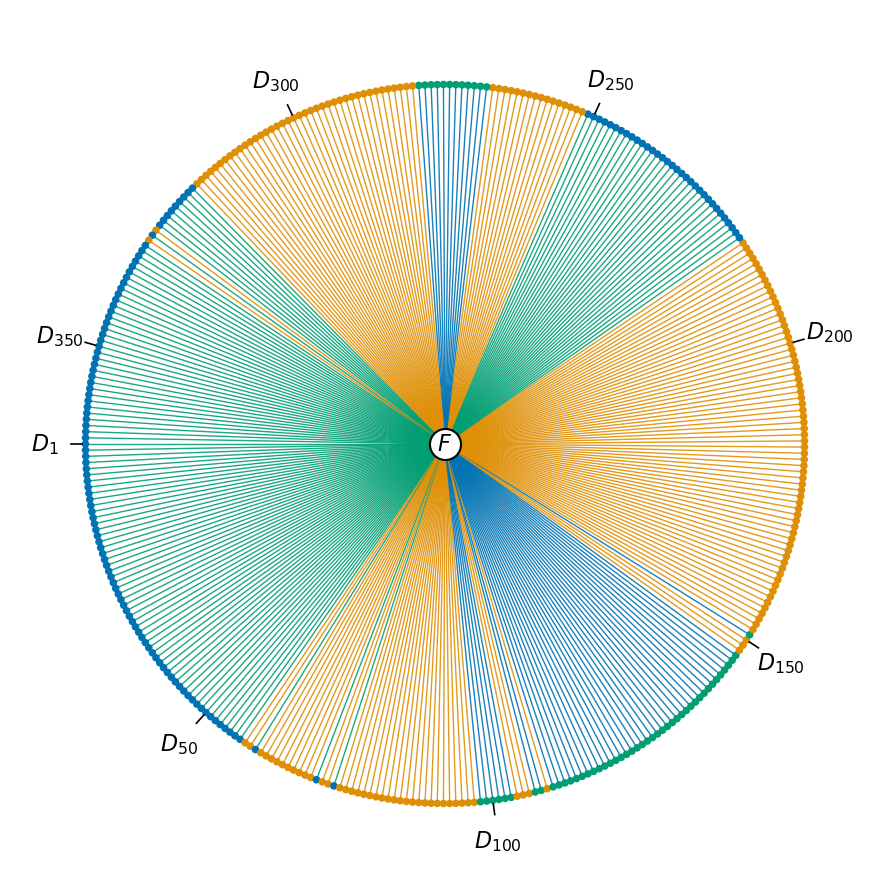

In [89]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import BoundaryNorm


def plot_transition_graph(probabilities):

    n = len(probabilities)

    G = nx.DiGraph()

    # =========================================================
    # Nodos
    # =========================================================

    states = [f"D{i+1}" for i in range(n)]

    G.add_nodes_from(states)
    G.add_node("F")

    # =========================================================
    # Aristas
    # =========================================================

    for i, p in enumerate(probabilities):

        current = f"D{i+1}"
        next_state = f"D{(i+1) % n + 1}"

        # -----------------------------------------------------
        # Transición de éxito
        # -----------------------------------------------------

        G.add_edge(
            current,
            next_state,
            weight=p,
            transition="success"
        )

        # -----------------------------------------------------
        # Transición de fallo
        # -----------------------------------------------------

        G.add_edge(
            current,
            "F",
            weight=1-p,
            transition="failure"
        )

    # =========================================================
    # Layout circular
    # =========================================================

    pos = {
        "F": np.array([0, 0])
    }

    radius = 5

    for i, state in enumerate(states):

        day = i + 1

        # D1 = día 1 = 1 de enero
        angle = np.deg2rad(
            180 + (day - 1) * 360 / 365
        )

        pos[state] = np.array([
            radius * np.cos(angle),
            radius * np.sin(angle)
        ])

    # =========================================================
    # Colores
    # =========================================================

    palette = sns.color_palette(
        "colorblind",
        n_colors=3
    )

    bounds = [
        0,
        0.3,
        0.7,
        1.0
    ]

    norm = BoundaryNorm(
        bounds,
        len(palette)
    )

    # ---------------------------------------------------------
    # Color de los nodos según p
    # ---------------------------------------------------------

    node_colors = [
        palette[
            min(
                norm(p),
                len(palette) - 1
            )
        ]
        for p in probabilities
    ]

    # =========================================================
    # Figura
    # =========================================================

    fig, ax = plt.subplots(
        figsize=(9, 9)
    )

    # =========================================================
    # Nodos D_i
    # =========================================================

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=states,
        node_size=30,
        node_color=node_colors,
        linewidths=0
    )

    # =========================================================
    # Nodo de fallo F
    # =========================================================

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=["F"],
        node_size=500,
        node_color="white",
        edgecolors="black",
        linewidths=1.5
    )

    # =========================================================
    # Separar aristas
    # =========================================================

    success_edges = [
        (u, v)
        for u, v, d in G.edges(data=True)
        if d["transition"] == "success"
    ]

    failure_edges = [
        (u, v)
        for u, v, d in G.edges(data=True)
        if d["transition"] == "failure"
    ]

    # =========================================================
    # Colores de las aristas de fallo
    #
    # weight = 1 - p
    # =========================================================

    failure_colors = [
        palette[
            min(
                norm(G[u][v]["weight"]),
                len(palette) - 1
            )
        ]
        for u, v in failure_edges
    ]

    # =========================================================
    # Transiciones cíclicas
    # =========================================================

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=success_edges,
        width=0.8,
        edge_color="gray",
        arrows=False,
        alpha=0.5
    )

    # =========================================================
    # Transiciones hacia F
    # =========================================================

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=failure_edges,
        width=1,
        edge_color=failure_colors,
        arrows=False,
        alpha=0.9
    )

    # =========================================================
    # Etiqueta F
    # =========================================================

    nx.draw_networkx_labels(
        G,
        pos,
        labels={
            "F": r"$F$"
        },
        font_size=16
    )

    # =========================================================
    # Función día → ángulo
    # =========================================================

    def day_to_angle(day):

        return 180 + (day - 1) * 360 / 365

    # =========================================================
    # Etiquetas de los días
    # =========================================================

    tick_days = [
        1, 50, 100, 150,
        200, 250, 300, 350
    ]

    label_radius = radius + 0.45
    tick_inner = radius + 0.05
    tick_outer = radius + 0.20

    for day in tick_days:

        angle = np.deg2rad(
            day_to_angle(day)
        )

        # -----------------------------------------------------
        # Marca exterior
        # -----------------------------------------------------

        ax.plot(
            [
                np.cos(angle) * tick_inner,
                np.cos(angle) * tick_outer
            ],
            [
                np.sin(angle) * tick_inner,
                np.sin(angle) * tick_outer
            ],
            color="black",
            linewidth=1.2
        )

        # -----------------------------------------------------
        # Etiqueta D_i
        # -----------------------------------------------------

        ax.text(
            np.cos(angle) * (label_radius+0.12),
            np.sin(angle) * (label_radius+0.12),
            f"$D_{{{day}}}$",
            ha="center",
            va="center",
            fontsize=16
        )

    # =========================================================
    # Apariencia
    # =========================================================

    ax.set_aspect("equal")
    ax.axis("off")

    plt.tight_layout()

    plt.show()
    
plot_transition_graph(euclidean_vector_complement)